In [1]:
# CELL 0 — Setup (paths, imports, global rules)
# You said:
# - BASE_DIR = D:\base
# - CSV and JSON are inside BASE_DIR
# - Images are in BASE_DIR\Data and CSV LINK looks like "Data\NAME.jpeg"
# - Images are 256x256
# - Start new notebook from cell 0

from pathlib import Path
import os
import re
import json
import math
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# --- Base paths (DO NOT CHANGE unless your local layout changes) ---
BASE_DIR = Path(r"D:\base")
CSV_PATH = BASE_DIR / "dmsa_dataset.csv"
JSON_PATH = BASE_DIR / "dmsa.json"

# --- Image constants ---
IMG_SIZE = 256

# ROI mask (your margin-30 rule): keep center area, zero outside.
ROI_X0, ROI_Y0 = 30, 30
ROI_X1, ROI_Y1 = 226, 226  # end-exclusive

# Locked tick-only ruler ROI (kept here for later; NOT used yet in this preprocessing cell)
RULER_X0, RULER_X1 = 240, 253
RULER_Y0, RULER_Y1 = 106, 152

print("BASE_DIR:", BASE_DIR)
print("CSV_PATH:", CSV_PATH)
print("JSON_PATH:", JSON_PATH)
print("IMG_SIZE:", IMG_SIZE)


BASE_DIR: D:\base
CSV_PATH: D:\base\dmsa_dataset.csv
JSON_PATH: D:\base\dmsa.json
IMG_SIZE: 256


In [2]:
# CELL 1 — Robust column resolver + load CSV (NO column-name guessing)
def _norm_colname(s: str) -> str:
    return re.sub(r"\s+", " ", str(s).strip().lower())

def require_col(df: pd.DataFrame, wanted: str) -> str:
    """
    Find an exact column by normalized name.
    Example: wanted="LINK" matches "LINK" / "Link" / " link " etc.
    """
    target = _norm_colname(wanted)
    for c in df.columns:
        if _norm_colname(c) == target:
            return c
    # If not found, print columns for you and raise a clear error
    print("ERROR: Required column not found:", wanted)
    print("Available columns:")
    for c in df.columns:
        print(" -", repr(c))
    raise KeyError(f"Required column '{wanted}' not found. Fix the CSV header or update wanted='{wanted}'.")

# Load CSV
df = pd.read_csv(CSV_PATH)

COL_LINK = require_col(df, "LINK")
# VIEW is useful for later; still resolve now to avoid assumptions.
COL_VIEW = require_col(df, "VIEW")

print("Loaded CSV:", df.shape)
print("Resolved columns:")
print("  COL_LINK =", repr(COL_LINK))
print("  COL_VIEW =", repr(COL_VIEW))

# Show first few rows of LINK/VIEW
df[[COL_LINK, COL_VIEW]].head(10)


Loaded CSV: (2294, 23)
Resolved columns:
  COL_LINK = 'LINK'
  COL_VIEW = 'VIEW'


,LINK,VIEW
0,Data\A_RAHMAN_6_MONTHS.jpeg,P
1,Data\A_RAHMAN_6_MONTHS_1.jpeg,LPO
2,Data\A_RAHMAN_6_MONTHS_2.jpeg,RPO
3,Data\ABDUL_ALIM_1_MONTHS.jpeg,P
4,Data\ABDUL_ALIM_1_MONTHS_1.jpeg,LPO
5,Data\ABDUL_ALIM_1_MONTHS_2.jpeg,RPO
6,Data\ABDUL_BATIN_63_YRS.jpeg,P
7,Data\ABDUL_BATIN_63_YRS_1.jpeg,LPO
8,Data\ABDUL_BATIN_63_YRS_2.jpeg,RPO
9,Data\ABDUL_MOTALIB_7_YRS.jpeg,P


In [3]:
# CELL 2 — Build absolute image paths + quick file existence proof (with progress bar)
def rel_to_abs_path(rel_path: str, base_dir: Path) -> Path:
    # Handle either slash style safely
    rel_path = str(rel_path)
    rel_path = rel_path.replace("/", os.sep).replace("\\", os.sep)
    return base_dir / rel_path

# Create absolute path column (no mutation of original LINK)
abs_paths = []
missing = 0

for p in tqdm(df[COL_LINK].astype(str).tolist(), desc="Resolving paths"):
    ap = rel_to_abs_path(p, BASE_DIR)
    abs_paths.append(ap)
    if not ap.exists():
        missing += 1

df["__ABS_PATH__"] = abs_paths

print("Total rows:", len(df))
print("Missing files:", missing)
print("Example absolute paths:")
for i in range(5):
    print(" ", df["__ABS_PATH__"].iloc[i])

# If there are missing files, show a few examples
if missing > 0:
    print("\nSome missing examples:")
    shown = 0
    for i in range(len(df)):
        if not df["__ABS_PATH__"].iloc[i].exists():
            print(" ", df[COL_LINK].iloc[i], "->", df["__ABS_PATH__"].iloc[i])
            shown += 1
            if shown >= 8:
                break


Resolving paths:   0%|          | 0/2294 [00:00<?, ?it/s]

Total rows: 2294
Missing files: 0
Example absolute paths:
  D:\base\Data\A_RAHMAN_6_MONTHS.jpeg
  D:\base\Data\A_RAHMAN_6_MONTHS_1.jpeg
  D:\base\Data\A_RAHMAN_6_MONTHS_2.jpeg
  D:\base\Data\ABDUL_ALIM_1_MONTHS.jpeg
  D:\base\Data\ABDUL_ALIM_1_MONTHS_1.jpeg


In [4]:
# CELL 3 — Patient group key from filename (your rule: strip trailing _1/_2/_3... only)
# Examples:
#   ABDULLAH_2YRS.jpeg        -> base = ABDULLAH_2YRS
#   ABDULLAH_2YRS_1.jpeg      -> base = ABDULLAH_2YRS
#   ABDULLAH_4_YRS_05_MONTHS.jpeg   -> base = ABDULLAH_4_YRS_05_MONTHS
#   ABDULLAH_4_YRS_5_MONTHS.jpeg    -> base = ABDULLAH_4_YRS_5_MONTHS  (DIFFERENT case)

def patient_base_from_link(link_value: str) -> str:
    # take filename only, without folders
    fname = os.path.basename(str(link_value).replace("/", os.sep).replace("\\", os.sep))
    # remove extension
    stem, _ext = os.path.splitext(fname)

    # strip ONLY a trailing "_<digits>" if present
    m = re.match(r"^(.*?)(?:_(\d+))?$", stem)
    if not m:
        return stem
    core = m.group(1)
    idx = m.group(2)
    if idx is None:
        return stem
    return core

df["__PATIENT_BASE__"] = [patient_base_from_link(x) for x in df[COL_LINK].astype(str).tolist()]

print("Patient-base examples:")
for i in range(12):
    print(df[COL_LINK].iloc[i], "->", df["__PATIENT_BASE__"].iloc[i])

print("\nUnique patient-base count:", df["__PATIENT_BASE__"].nunique())

# Show distribution of number of views per patient-base (quick sanity)
counts = df["__PATIENT_BASE__"].value_counts()
print("\nViews per patient-base (top 10 most):")
counts.head(10)


Patient-base examples:
Data\A_RAHMAN_6_MONTHS.jpeg -> A_RAHMAN_6_MONTHS
Data\A_RAHMAN_6_MONTHS_1.jpeg -> A_RAHMAN_6_MONTHS
Data\A_RAHMAN_6_MONTHS_2.jpeg -> A_RAHMAN_6_MONTHS
Data\ABDUL_ALIM_1_MONTHS.jpeg -> ABDUL_ALIM_1_MONTHS
Data\ABDUL_ALIM_1_MONTHS_1.jpeg -> ABDUL_ALIM_1_MONTHS
Data\ABDUL_ALIM_1_MONTHS_2.jpeg -> ABDUL_ALIM_1_MONTHS
Data\ABDUL_BATIN_63_YRS.jpeg -> ABDUL_BATIN_63_YRS
Data\ABDUL_BATIN_63_YRS_1.jpeg -> ABDUL_BATIN_63_YRS
Data\ABDUL_BATIN_63_YRS_2.jpeg -> ABDUL_BATIN_63_YRS
Data\ABDUL_MOTALIB_7_YRS.jpeg -> ABDUL_MOTALIB_7_YRS
Data\ABDUL_MOTALIB_7_YRS_1.jpeg -> ABDUL_MOTALIB_7_YRS
Data\ABDUL_MOTALIB_7_YRS_2.jpeg -> ABDUL_MOTALIB_7_YRS

Unique patient-base count: 759

Views per patient-base (top 10 most):


__PATIENT_BASE__
TAWHID_2_YRS              6
SIAM_11_YRS               6
SADD_4_YRS                5
SABID_8_YRS               4
SAMIA_TASNIM_SAFA_5YRS    4
ABDUR_RAHMAN_1YRS         4
RAHAT_6_YRS               4
SIAM_17_YRS               4
JISHAN_33_MONTHS          4
ABDUR_RAHMAN_42_MONTHS    4
Name: count, dtype: int64

In [5]:
# CELL 4 — Load VIA-style JSON masks (dmsa.json) + mask rasterizer (NO assumptions)
# Your dmsa.json is VIA format:
# top-level dict keyed by filename (e.g., "SARIBA_8YRS.jpeg")
# each entry contains "regions" dict, each region has:
#   shape_attributes: polygon with all_points_x/all_points_y
#   region_attributes: {label: "left"/"right"}

from PIL import Image, ImageDraw

with open(JSON_PATH, "r", encoding="utf-8") as f:
    via = json.load(f)

print("Loaded dmsa.json entries:", len(via))

def _poly_to_mask(all_points_x, all_points_y, h=IMG_SIZE, w=IMG_SIZE):
    # Convert float coords to int pixel coords safely
    pts = []
    for x, y in zip(all_points_x, all_points_y):
        xi = int(round(float(x)))
        yi = int(round(float(y)))
        xi = max(0, min(w - 1, xi))
        yi = max(0, min(h - 1, yi))
        pts.append((xi, yi))

    m = Image.new("L", (w, h), 0)
    if len(pts) >= 3:
        ImageDraw.Draw(m).polygon(pts, outline=1, fill=1)
    return np.array(m, dtype=np.uint8)

def load_masks_for_link(link_value: str):
    """
    Returns ML, MR uint8 masks in {0,1} with shape [256,256].
    Matching uses basename of LINK, because VIA keys are basenames.
    """
    fname = os.path.basename(str(link_value).replace("/", os.sep).replace("\\", os.sep))
    if fname not in via:
        # No mask found
        return np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8), np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    entry = via[fname]
    regions = entry.get("regions", {})
    # VIA sometimes stores regions as dict; handle both.
    if isinstance(regions, list):
        region_iter = regions
    elif isinstance(regions, dict):
        region_iter = regions.values()
    else:
        region_iter = []

    ML = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    MR = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    for reg in region_iter:
        sa = reg.get("shape_attributes", {})
        ra = reg.get("region_attributes", {})
        label = str(ra.get("label", "")).strip().lower()

        if sa.get("name", "").lower() != "polygon":
            continue
        xs = sa.get("all_points_x", None)
        ys = sa.get("all_points_y", None)
        if xs is None or ys is None or len(xs) != len(ys):
            continue

        m = _poly_to_mask(xs, ys, h=IMG_SIZE, w=IMG_SIZE)
        if label == "left":
            ML = np.maximum(ML, m)
        elif label == "right":
            MR = np.maximum(MR, m)

    return ML, MR

# Quick proof on 5 random rows: show if mask exists and ranges of coords (via entry-level check)
sample_idxs = random.sample(range(len(df)), k=5)
for i in sample_idxs:
    link = df[COL_LINK].iloc[i]
    fname = os.path.basename(str(link).replace("/", os.sep).replace("\\", os.sep))
    ML, MR = load_masks_for_link(link)
    print(f"[{i}] {fname} | ML_sum={ML.sum()} MR_sum={MR.sum()} | has_json={fname in via}")


Loaded dmsa.json entries: 2294
[1491] RAHIM_8YRS_1.jpeg | ML_sum=416 MR_sum=615 | has_json=True
[1184] MONIRA_6_MONTHS_1.jpeg | ML_sum=0 MR_sum=287 | has_json=True
[1479] RAFSAN_20_MONTHS_2.jpeg | ML_sum=613 MR_sum=487 | has_json=True
[2148] TAWHID_17_YRS_1.jpeg | ML_sum=536 MR_sum=164 | has_json=True
[2268] ZAYED_1_YRS_1.jpeg | ML_sum=131 MR_sum=409 | has_json=True


In [6]:
# CELL 5 — Preprocessing functions (ROI mask + intensity clipping + gentle denoise + CLAHE)
# NOTE:
# - We keep RAW image untouched (for ruler later).
# - MODEL image is processed.
# - Intensity clipping is NOT spatial cropping.

# Optional CLAHE backends (no crash):
_HAS_CV2 = False
_HAS_SKIMAGE = False

try:
    import cv2
    _HAS_CV2 = True
except Exception:
    _HAS_CV2 = False

try:
    from skimage import exposure
    _HAS_SKIMAGE = True
except Exception:
    _HAS_SKIMAGE = False

print("CLAHE backend available -> cv2:", _HAS_CV2, "| skimage:", _HAS_SKIMAGE)

ROI_U8 = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
ROI_U8[ROI_Y0:ROI_Y1, ROI_X0:ROI_X1] = 1
ROI_F = ROI_U8.astype(np.float32)

def load_gray_256(path: Path) -> np.ndarray:
    # Load as grayscale float32 in [0,1], ensure 256x256.
    img = Image.open(path).convert("L")
    if img.size != (IMG_SIZE, IMG_SIZE):
        img = img.resize((IMG_SIZE, IMG_SIZE), resample=Image.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    return arr

def intensity_clip_norm(I: np.ndarray, mask: np.ndarray = None, p_lo=1.0, p_hi=99.0) -> np.ndarray:
    """
    Clip to percentiles then rescale to [0,1].
    mask: optional boolean/0-1 mask defining where percentiles are computed.
    """
    X = I
    if mask is not None:
        m = mask.astype(bool)
        vals = X[m]
        if vals.size < 32:
            vals = X.reshape(-1)
    else:
        vals = X.reshape(-1)

    lo = np.percentile(vals, p_lo)
    hi = np.percentile(vals, p_hi)
    if hi <= lo + 1e-6:
        return np.clip(X, 0.0, 1.0)

    Y = np.clip(X, lo, hi)
    Y = (Y - lo) / (hi - lo)
    return np.clip(Y, 0.0, 1.0)

def gentle_denoise(I: np.ndarray) -> np.ndarray:
    """
    Very mild denoise to avoid destroying scar patterns.
    Uses cv2 if available, else a tiny manual blur.
    """
    if _HAS_CV2:
        # GaussianBlur expects float32 OK
        return cv2.GaussianBlur(I.astype(np.float32), (3, 3), sigmaX=0.5)
    # fallback: tiny 3x3 average blur
    K = np.array([[1,1,1],[1,1,1],[1,1,1]], dtype=np.float32) / 9.0
    P = np.pad(I, ((1,1),(1,1)), mode="edge")
    out = np.zeros_like(I, dtype=np.float32)
    for y in range(IMG_SIZE):
        for x in range(IMG_SIZE):
            out[y,x] = np.sum(P[y:y+3, x:x+3] * K)
    return out

def apply_clahe(I: np.ndarray, clip_limit=2.0, tile_grid_size=(8,8)) -> np.ndarray:
    """
    Apply CLAHE to a normalized [0,1] image.
    """
    if _HAS_CV2:
        u8 = (np.clip(I, 0, 1) * 255.0).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=float(clip_limit), tileGridSize=tile_grid_size)
        out = clahe.apply(u8).astype(np.float32) / 255.0
        return np.clip(out, 0.0, 1.0)

    if _HAS_SKIMAGE:
        out = exposure.equalize_adapthist(np.clip(I,0,1), clip_limit=0.01)  # skimage uses different scaling
        return np.clip(out.astype(np.float32), 0.0, 1.0)

    # final fallback: no CLAHE (still runs)
    return I.astype(np.float32)

def preprocess_for_model(I_raw: np.ndarray, ML: np.ndarray = None, MR: np.ndarray = None,
                         p_lo=1.0, p_hi=99.0, do_clahe=True):
    """
    Returns:
      I_roi: ROI-masked raw
      I_clip: clipped+normalized
      I_dnz: denoised
      I_clahe: CLAHE-applied
      I_L, I_R: masked left/right (using CLAHE image)
    """
    # ROI mask (spatial)
    I_roi = I_raw * ROI_F

    # For percentile stats, use ROI mask OR ROI∩(ML|MR) if masks exist.
    if ML is not None and MR is not None:
        mk = ((ML > 0) | (MR > 0)).astype(np.uint8)
        stat_mask = (mk * ROI_U8).astype(bool)
        if stat_mask.sum() < 32:
            stat_mask = ROI_U8.astype(bool)
    else:
        stat_mask = ROI_U8.astype(bool)

    I_clip = intensity_clip_norm(I_roi, mask=stat_mask, p_lo=p_lo, p_hi=p_hi)
    I_dnz  = gentle_denoise(I_clip)

    I_clahe = apply_clahe(I_dnz) if do_clahe else I_dnz
    I_clahe = np.clip(I_clahe, 0.0, 1.0).astype(np.float32)

    # masked side images
    if ML is None:
        ML = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    if MR is None:
        MR = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    I_L = I_clahe * (ML.astype(np.float32))
    I_R = I_clahe * (MR.astype(np.float32))

    return I_roi, I_clip, I_dnz, I_clahe, I_L, I_R


CLAHE backend available -> cv2: True | skimage: True


Visualization picks: [257, 21, 278]


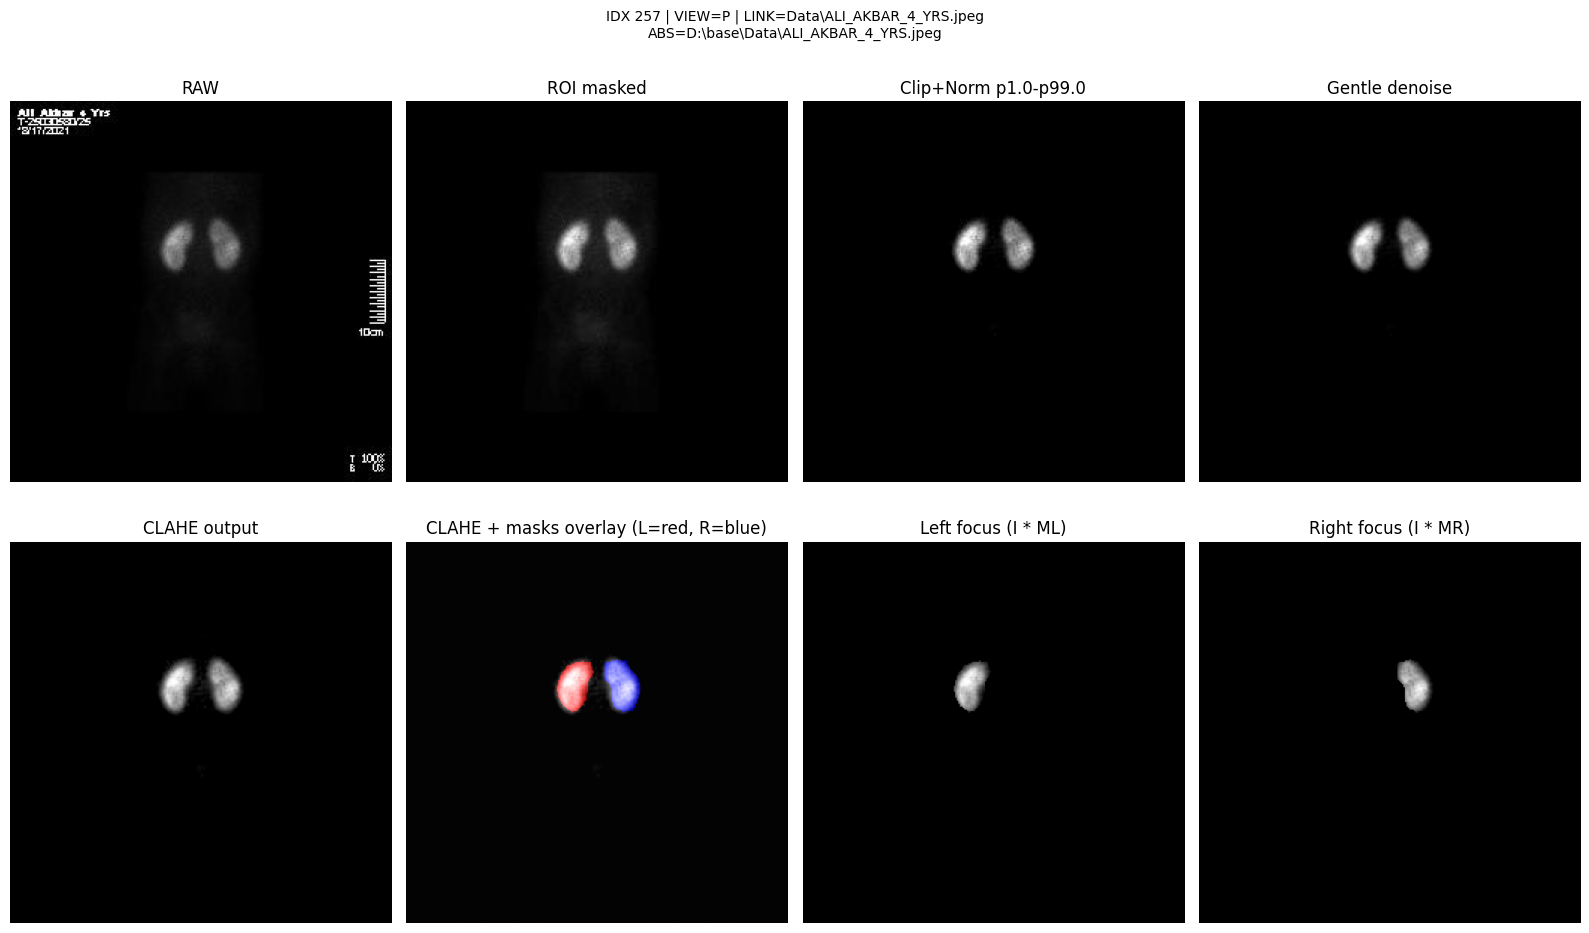

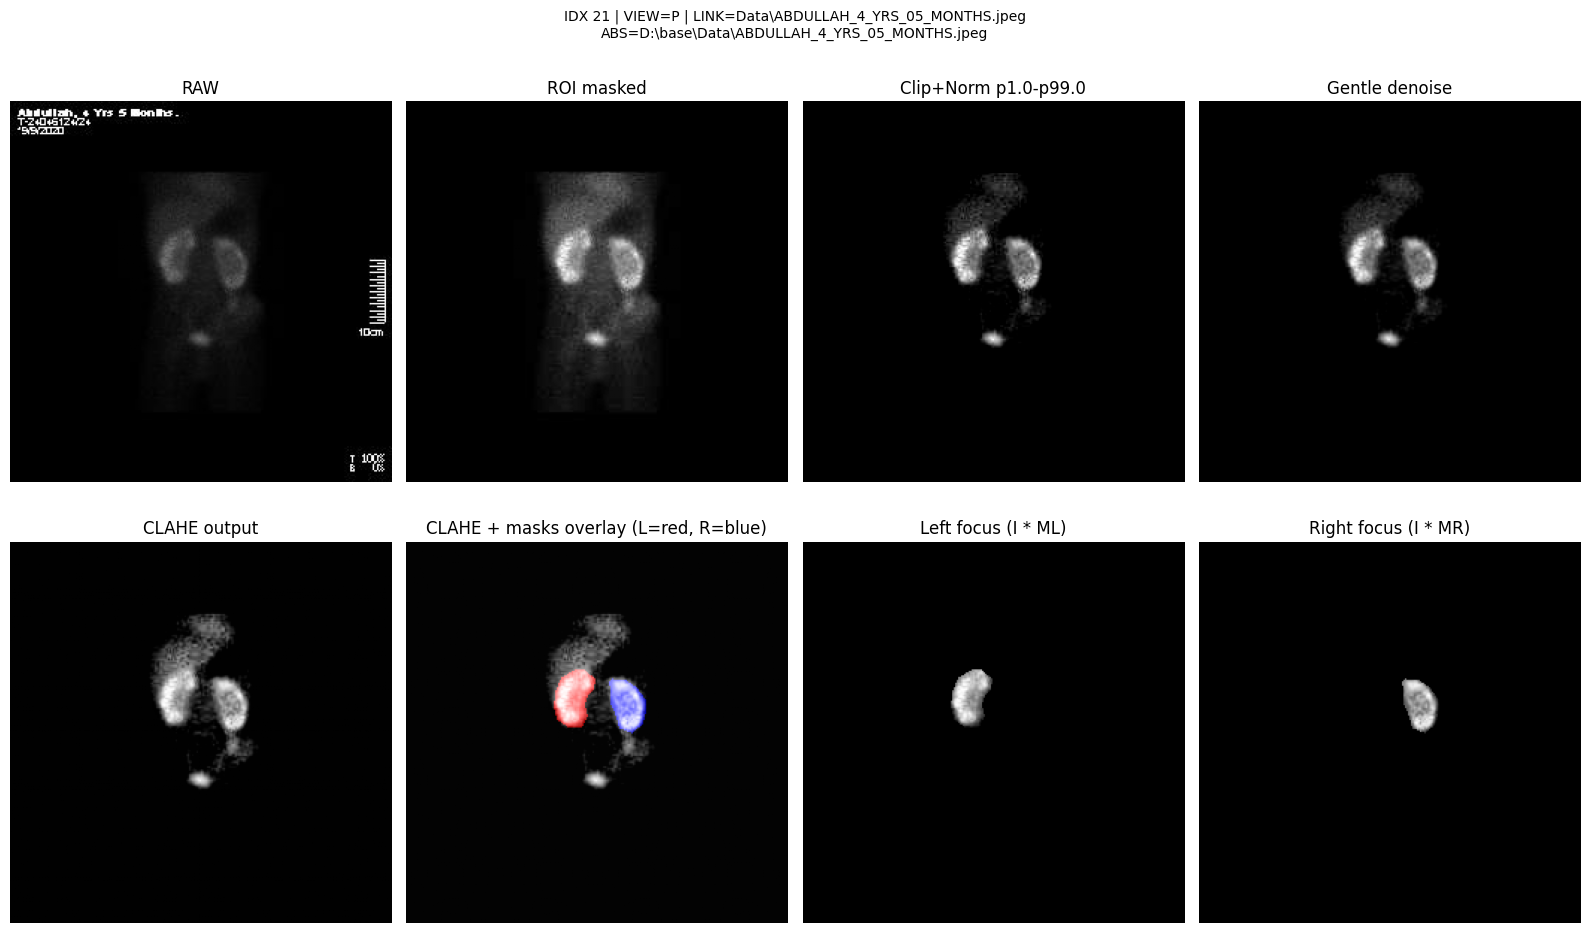

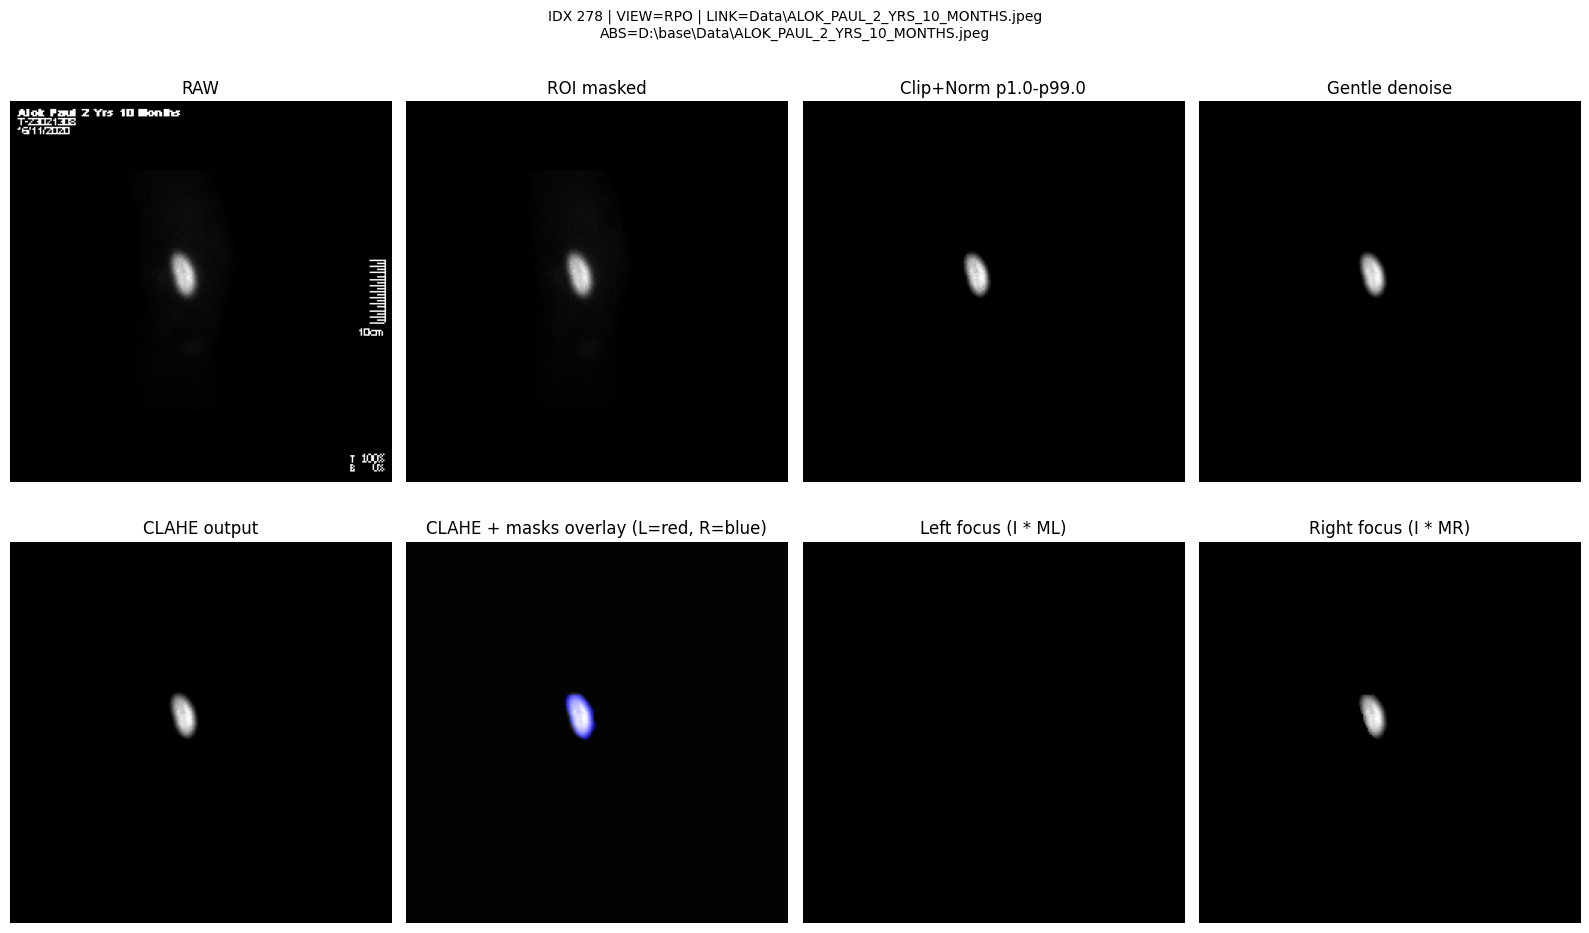

In [7]:
# CELL 6 — Visual proof: before/after preprocessing + masks (side-by-side)
def show_preprocess(idx: int, p_lo=1.0, p_hi=99.0, do_clahe=True):
    row = df.iloc[idx]
    abs_path: Path = row["__ABS_PATH__"]
    link = row[COL_LINK]
    view = row[COL_VIEW]

    if not abs_path.exists():
        print("ERROR: File missing:", abs_path)
        return

    I_raw = load_gray_256(abs_path)
    ML, MR = load_masks_for_link(link)
    I_roi, I_clip, I_dnz, I_clahe, I_L, I_R = preprocess_for_model(I_raw, ML, MR, p_lo=p_lo, p_hi=p_hi, do_clahe=do_clahe)

    # overlays for proof
    overlay = np.dstack([I_clahe, I_clahe, I_clahe])
    overlay[..., 0] = np.clip(overlay[..., 0] + 0.6*(ML>0), 0, 1)  # red tint for left
    overlay[..., 2] = np.clip(overlay[..., 2] + 0.6*(MR>0), 0, 1)  # blue tint for right

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f"IDX {idx} | VIEW={view} | LINK={link}\nABS={abs_path}", fontsize=10)

    ax = plt.subplot(2,4,1); ax.imshow(I_raw, cmap="gray"); ax.set_title("RAW"); ax.axis("off")
    ax = plt.subplot(2,4,2); ax.imshow(I_roi, cmap="gray"); ax.set_title("ROI masked"); ax.axis("off")
    ax = plt.subplot(2,4,3); ax.imshow(I_clip, cmap="gray"); ax.set_title(f"Clip+Norm p{p_lo}-p{p_hi}"); ax.axis("off")
    ax = plt.subplot(2,4,4); ax.imshow(I_dnz, cmap="gray"); ax.set_title("Gentle denoise"); ax.axis("off")

    ax = plt.subplot(2,4,5); ax.imshow(I_clahe, cmap="gray"); ax.set_title("CLAHE output"); ax.axis("off")
    ax = plt.subplot(2,4,6); ax.imshow(overlay); ax.set_title("CLAHE + masks overlay (L=red, R=blue)"); ax.axis("off")
    ax = plt.subplot(2,4,7); ax.imshow(I_L, cmap="gray"); ax.set_title("Left focus (I * ML)"); ax.axis("off")
    ax = plt.subplot(2,4,8); ax.imshow(I_R, cmap="gray"); ax.set_title("Right focus (I * MR)"); ax.axis("off")

    plt.tight_layout()
    plt.show()

# Pick 3 random samples with masks (if possible), else any samples
mask_nonzero = np.where([(load_masks_for_link(df[COL_LINK].iloc[i])[0].sum() +
                          load_masks_for_link(df[COL_LINK].iloc[i])[1].sum()) > 0
                         for i in range(min(300, len(df)))])[0]

if len(mask_nonzero) > 0:
    picks = random.sample(mask_nonzero.tolist(), k=min(3, len(mask_nonzero)))
else:
    picks = random.sample(range(len(df)), k=3)

print("Visualization picks:", picks)
for idx in picks:
    show_preprocess(idx)


In [8]:
# CELL 7 — Multi-view grouping sanity (proof we group *_1, *_2, *_3... together)
# We do NOT normalize underscores/spaces; we only strip trailing _<digits>.
# This respects your "05" vs "5" being different cases.

# Build grouped indices for a few patient-bases
gb = df.groupby("__PATIENT_BASE__").indices

# Show 5 random patient-bases and their LINK list
some_keys = random.sample(list(gb.keys()), k=5)
for k in some_keys:
    idxs = gb[k]
    links = df.loc[idxs, COL_LINK].tolist()
    print("\nPATIENT_BASE:", k, "| n_views=", len(links))
    for L in links[:10]:
        print(" ", L)



PATIENT_BASE: SHAHRIN_JANNAT_JIARA_11_MONTHS | n_views= 3
  Data\SHAHRIN_JANNAT_JIARA_11_MONTHS.jpeg
  Data\SHAHRIN_JANNAT_JIARA_11_MONTHS_1.jpeg
  Data\SHAHRIN_JANNAT_JIARA_11_MONTHS_2.jpeg

PATIENT_BASE: SOHAN_7_YRS | n_views= 3
  Data\SOHAN_7_YRS.jpeg
  Data\SOHAN_7_YRS_1.jpeg
  Data\SOHAN_7_YRS_2.jpeg

PATIENT_BASE: SIAM_ALI_6_YRS | n_views= 3
  Data\SIAM_ALI_6_YRS.jpeg
  Data\SIAM_ALI_6_YRS_1.jpeg
  Data\SIAM_ALI_6_YRS_2.jpeg

PATIENT_BASE: DELWARA_75_YRS | n_views= 3
  Data\DELWARA_75_YRS.jpeg
  Data\DELWARA_75_YRS_1.jpeg
  Data\DELWARA_75_YRS_2.jpeg

PATIENT_BASE: WOALID_6_YRS | n_views= 3
  Data\WOALID_6_YRS.jpeg
  Data\WOALID_6_YRS_1.jpeg
  Data\WOALID_6_YRS_2.jpeg


In [9]:
# CELL 8 — Re-resolve columns safely (NO assumptions) + reload CSV (robust)
# Why: earlier we required VIEW. If your CSV ever changes, this cell keeps us safe.

def require_col(df: pd.DataFrame, wanted: str) -> str:
    target = _norm_colname(wanted)
    for c in df.columns:
        if _norm_colname(c) == target:
            return c
    print("ERROR: Required column not found:", wanted)
    print("Available columns:")
    for c in df.columns:
        print(" -", repr(c))
    raise KeyError(f"Required column '{wanted}' not found.")

def optional_col(df: pd.DataFrame, wanted: str):
    target = _norm_colname(wanted)
    for c in df.columns:
        if _norm_colname(c) == target:
            return c
    return None

df = pd.read_csv(CSV_PATH)

COL_LINK = require_col(df, "LINK")
COL_VIEW = optional_col(df, "VIEW")  # optional on purpose

print("Loaded CSV:", df.shape)
print("Columns:", list(df.columns))
print("Resolved:")
print("  COL_LINK =", repr(COL_LINK))
print("  COL_VIEW =", repr(COL_VIEW))

# rebuild ABS paths (fresh)
df["__ABS_PATH__"] = [rel_to_abs_path(x, BASE_DIR) for x in df[COL_LINK].astype(str).tolist()]
df["__PATIENT_BASE__"] = [patient_base_from_link(x) for x in df[COL_LINK].astype(str).tolist()]

df[[COL_LINK] + ([COL_VIEW] if COL_VIEW else [])].head(10)


Loaded CSV: (2294, 23)
Columns: ['PATIENT NAME', 'AGE', 'AGE in MONTHS', 'SEX', 'LINK', 'VIEW', 'SIZE LEFT', 'SIZE RIGHT', 'ANATOMY', 'SHAPE LEFT', 'SHAPE RIGHT', 'POSITION', 'ECTOPIC POSITION LEFT', 'ECTOPIC POSITION RIGHT', 'Kidney COUNT', 'SCAR', 'SCAR LEFT', 'SCAR RIGHT', 'HDN', 'CORTICAL UPTAKE LEFT', 'CORTICAL UPTAKE RIGHT', 'Comment', 'CH']
Resolved:
  COL_LINK = 'LINK'
  COL_VIEW = 'VIEW'


,LINK,VIEW
0,Data\A_RAHMAN_6_MONTHS.jpeg,P
1,Data\A_RAHMAN_6_MONTHS_1.jpeg,LPO
2,Data\A_RAHMAN_6_MONTHS_2.jpeg,RPO
3,Data\ABDUL_ALIM_1_MONTHS.jpeg,P
4,Data\ABDUL_ALIM_1_MONTHS_1.jpeg,LPO
5,Data\ABDUL_ALIM_1_MONTHS_2.jpeg,RPO
6,Data\ABDUL_BATIN_63_YRS.jpeg,P
7,Data\ABDUL_BATIN_63_YRS_1.jpeg,LPO
8,Data\ABDUL_BATIN_63_YRS_2.jpeg,RPO
9,Data\ABDUL_MOTALIB_7_YRS.jpeg,P


In [10]:
# CELL 9 — File existence proof (progress bar) + show a few missing if any
missing_rows = []
for i in tqdm(range(len(df)), desc="Checking image files"):
    p = df["__ABS_PATH__"].iloc[i]
    if not Path(p).exists():
        missing_rows.append(i)

print("Total rows:", len(df))
print("Missing files:", len(missing_rows))

if len(missing_rows) > 0:
    print("\nFirst 10 missing examples:")
    for i in missing_rows[:10]:
        print(f"  idx={i} LINK={df[COL_LINK].iloc[i]}  ABS={df['__ABS_PATH__'].iloc[i]}")


Checking image files:   0%|          | 0/2294 [00:00<?, ?it/s]

Total rows: 2294
Missing files: 0


In [11]:
# CELL 10 — VIEW-aware flip (if VIEW exists) + mask-aligned flip
# Rule we will follow:
# - If VIEW is one of {"RPO","RLO"} (case-insensitive), flip horizontally.
# - Flip is applied to image AND masks consistently.
# - If VIEW column is missing, no flip is applied.

def norm_view(v):
    if v is None:
        return ""
    return str(v).strip().lower()

def should_flip_by_view(v: str) -> bool:
    vv = norm_view(v)
    return vv in {"rpo", "rlo"}  # extend later if needed

def hflip_np(I: np.ndarray) -> np.ndarray:
    return np.ascontiguousarray(I[:, ::-1])

def maybe_flip(I: np.ndarray, ML: np.ndarray, MR: np.ndarray, view_val):
    if COL_VIEW is None:
        return I, ML, MR, False
    if should_flip_by_view(view_val):
        return hflip_np(I), hflip_np(ML), hflip_np(MR), True
    return I, ML, MR, False

print("Flip rule active?", COL_VIEW is not None)
if COL_VIEW is not None:
    print("Example VIEW values (first 20):", [str(x) for x in df[COL_VIEW].head(20).tolist()])


Flip rule active? True
Example VIEW values (first 20): ['P', 'LPO', 'RPO', 'P', 'LPO', 'RPO', 'P', 'LPO', 'RPO', 'P', 'LPO', 'RPO', 'P', 'LPO', 'RPO', 'P', 'LPO', 'RPO', 'P', 'LPO']


In [12]:
# CELL 11 — Mask availability stats (with progress bar) + sanity counts
# This proves dmsa.json linkage works (via basenames) and shows how many have L/R masks.

has_any = 0
has_L = 0
has_R = 0
missing_in_json = 0

for i in tqdm(range(len(df)), desc="Scanning mask availability"):
    link = df[COL_LINK].iloc[i]
    fname = os.path.basename(str(link).replace("/", os.sep).replace("\\", os.sep))
    if fname not in via:
        missing_in_json += 1
        continue
    ML, MR = load_masks_for_link(link)
    if (ML.sum() + MR.sum()) > 0:
        has_any += 1
    if ML.sum() > 0:
        has_L += 1
    if MR.sum() > 0:
        has_R += 1

print("Mask stats:")
print("  Total rows:", len(df))
print("  Missing from JSON (by basename):", missing_in_json)
print("  Has any mask:", has_any)
print("  Has left mask:", has_L)
print("  Has right mask:", has_R)


Scanning mask availability:   0%|          | 0/2294 [00:00<?, ?it/s]

Mask stats:
  Total rows: 2294
  Missing from JSON (by basename): 0
  Has any mask: 2294
  Has left mask: 2090
  Has right mask: 2055


In [13]:
# CELL 12 — Final preprocessing wrapper (ROI mask + intensity clip + mild denoise + CLAHE) WITH view-flip support
# This is the preprocessing we agreed to:
# - Keep image 256x256
# - ROI masking (not crop+resize)
# - Intensity clipping p1–p99 (default), then normalize to [0,1]
# - Gentle denoise
# - CLAHE
# - Apply VIEW flip consistently to image+masks (if VIEW exists)

P_LO = 1.0
P_HI = 99.0

def preprocess_row(idx: int, p_lo=P_LO, p_hi=P_HI, do_clahe=True):
    row = df.iloc[idx]
    abs_path = Path(row["__ABS_PATH__"])
    if not abs_path.exists():
        raise FileNotFoundError(f"Missing image file: {abs_path}")

    link = row[COL_LINK]
    view_val = row[COL_VIEW] if COL_VIEW else None

    I_raw = load_gray_256(abs_path)
    ML, MR = load_masks_for_link(link)

    # Flip by view if needed
    I_raw, ML, MR, did_flip = maybe_flip(I_raw, ML, MR, view_val)

    # Preprocess
    I_roi, I_clip, I_dnz, I_clahe, I_L, I_R = preprocess_for_model(
        I_raw, ML, MR, p_lo=p_lo, p_hi=p_hi, do_clahe=do_clahe
    )

    out = {
        "idx": idx,
        "link": link,
        "abs_path": str(abs_path),
        "view": str(view_val) if view_val is not None else None,
        "did_flip": did_flip,
        "I_raw": I_raw,
        "ML": ML,
        "MR": MR,
        "I_roi": I_roi,
        "I_clip": I_clip,
        "I_dnz": I_dnz,
        "I_clahe": I_clahe,
        "I_L": I_L,
        "I_R": I_R,
    }
    return out

print("Preprocessing defaults:", f"p_lo={P_LO}, p_hi={P_HI}, CLAHE={True}")


Preprocessing defaults: p_lo=1.0, p_hi=99.0, CLAHE=True


Finding samples with masks:   0%|          | 0/600 [00:00<?, ?it/s]

Preprocess proof picks: [235, 220, 209]


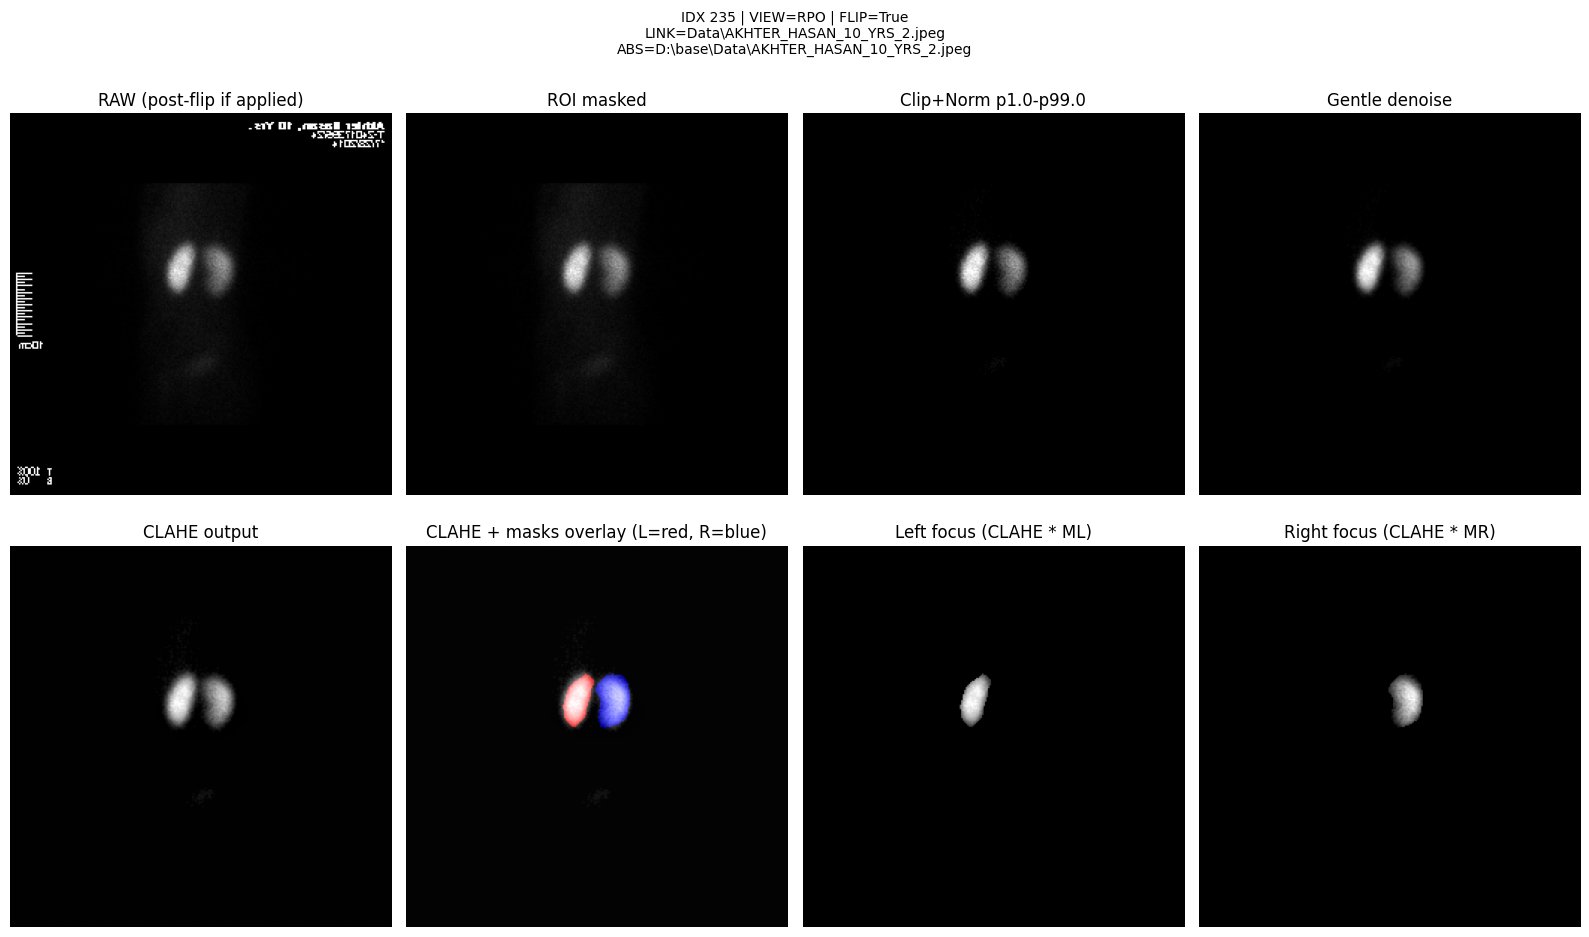

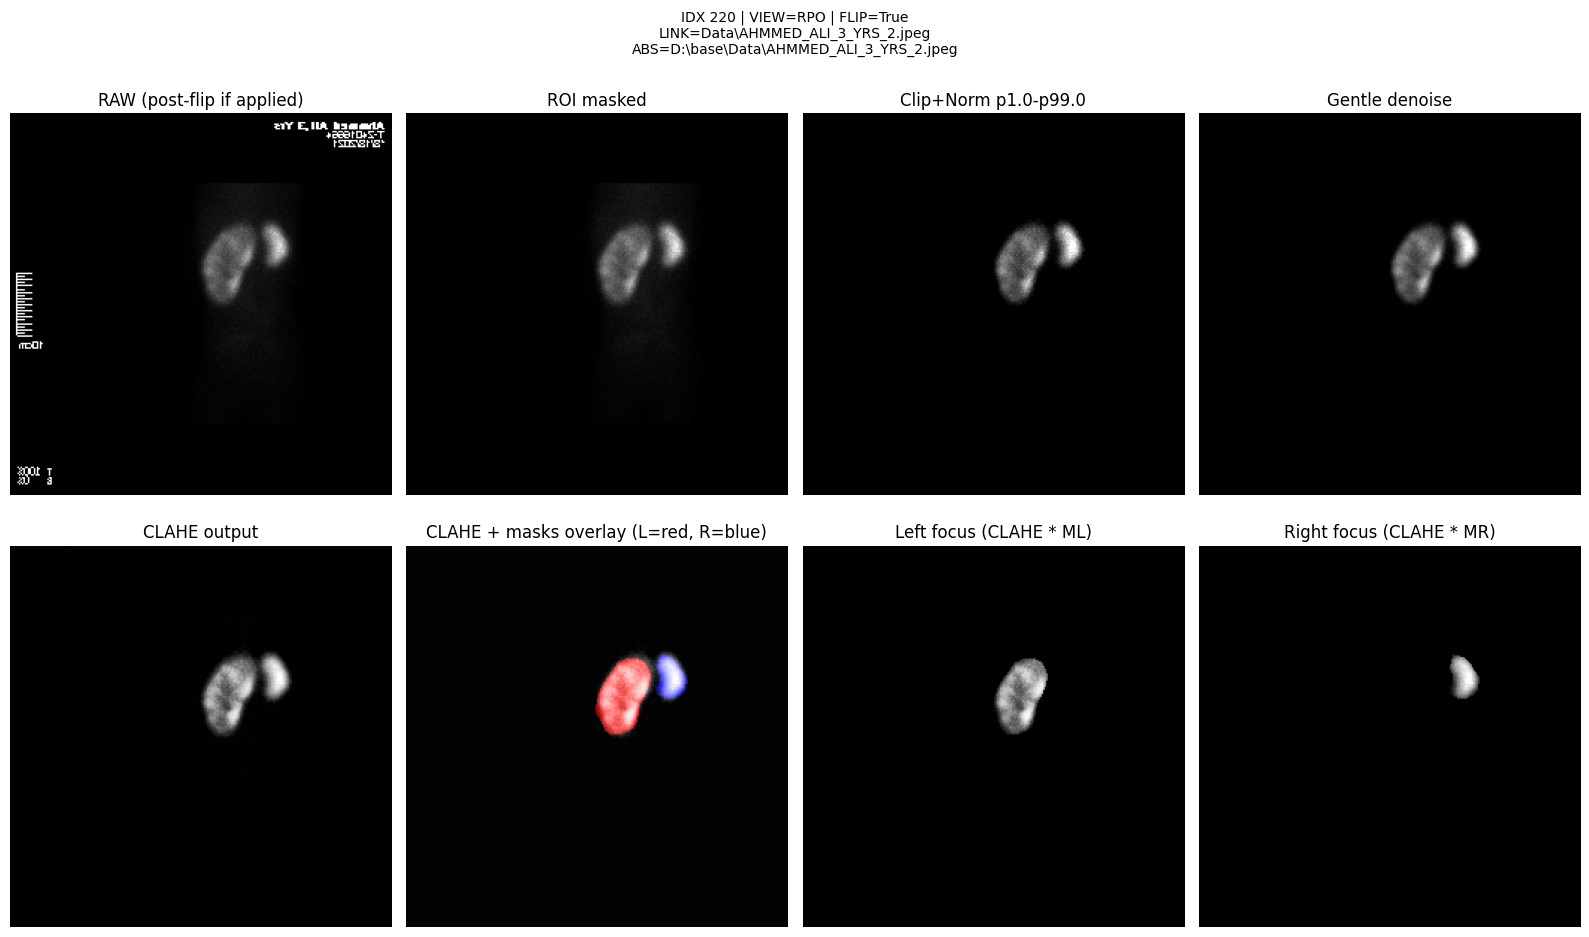

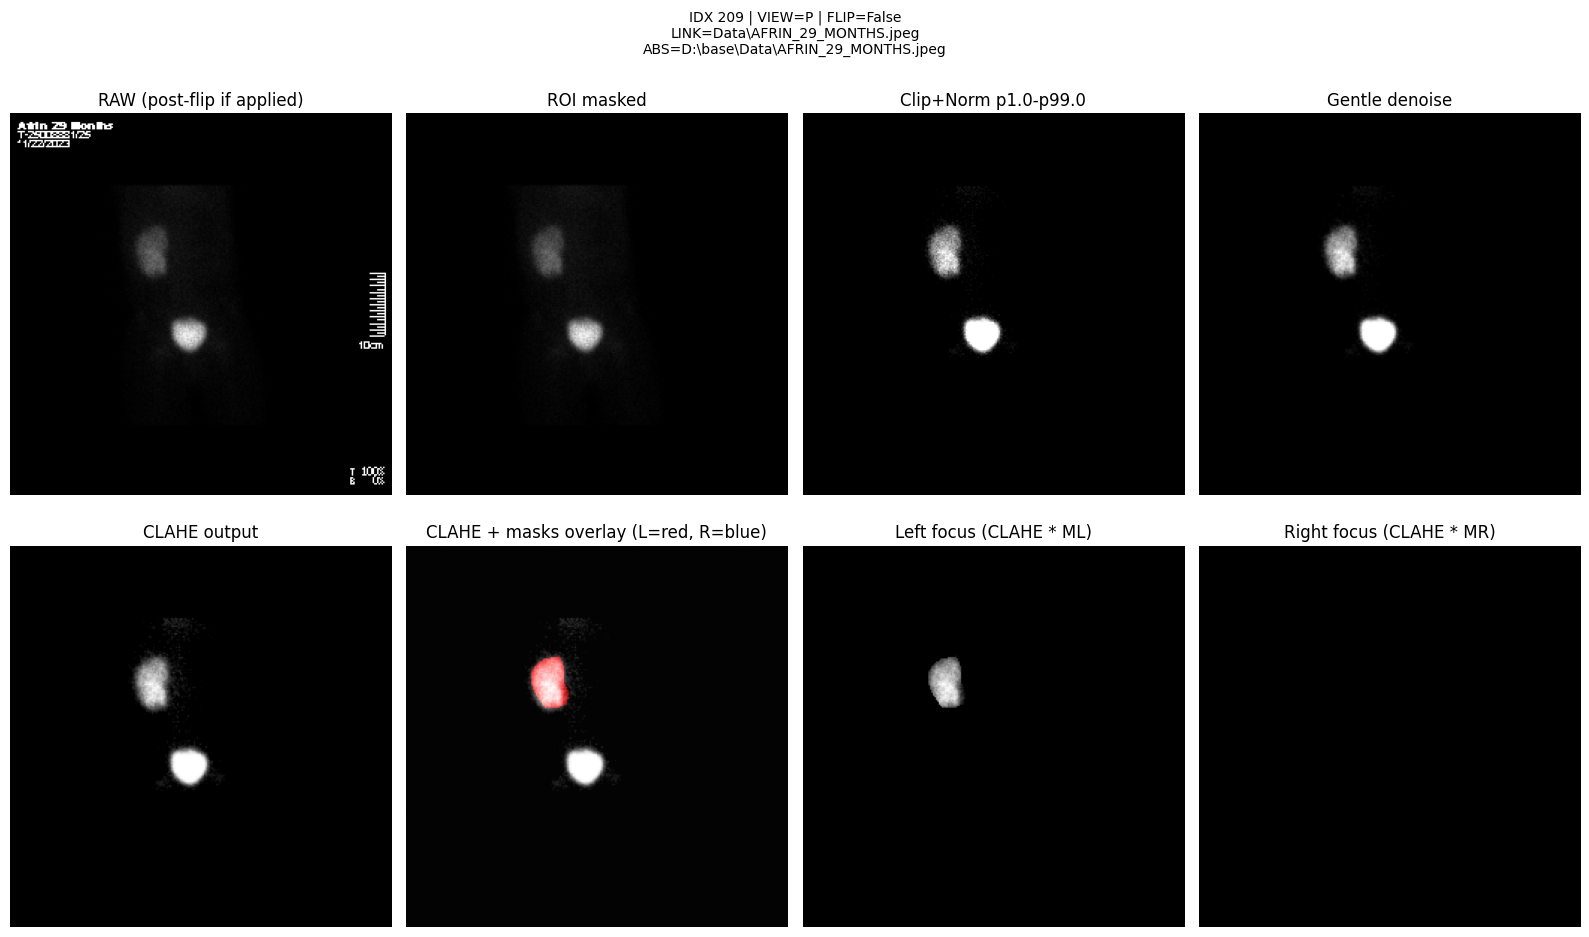

In [14]:
# CELL 13 — Visual proof (single sample) with flip indicator + tight side-by-side
def show_preprocess_v2(idx: int, p_lo=P_LO, p_hi=P_HI, do_clahe=True):
    pack = preprocess_row(idx, p_lo=p_lo, p_hi=p_hi, do_clahe=do_clahe)

    I_raw   = pack["I_raw"]
    ML, MR  = pack["ML"], pack["MR"]
    I_roi   = pack["I_roi"]
    I_clip  = pack["I_clip"]
    I_dnz   = pack["I_dnz"]
    I_c     = pack["I_clahe"]
    I_L, I_R= pack["I_L"], pack["I_R"]

    overlay = np.dstack([I_c, I_c, I_c])
    overlay[..., 0] = np.clip(overlay[..., 0] + 0.6*(ML>0), 0, 1)  # left=red
    overlay[..., 2] = np.clip(overlay[..., 2] + 0.6*(MR>0), 0, 1)  # right=blue

    title = f"IDX {pack['idx']} | VIEW={pack['view']} | FLIP={pack['did_flip']}\nLINK={pack['link']}\nABS={pack['abs_path']}"

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(title, fontsize=10)

    ax = plt.subplot(2,4,1); ax.imshow(I_raw, cmap="gray"); ax.set_title("RAW (post-flip if applied)"); ax.axis("off")
    ax = plt.subplot(2,4,2); ax.imshow(I_roi, cmap="gray"); ax.set_title("ROI masked"); ax.axis("off")
    ax = plt.subplot(2,4,3); ax.imshow(I_clip, cmap="gray"); ax.set_title(f"Clip+Norm p{p_lo}-p{p_hi}"); ax.axis("off")
    ax = plt.subplot(2,4,4); ax.imshow(I_dnz, cmap="gray"); ax.set_title("Gentle denoise"); ax.axis("off")

    ax = plt.subplot(2,4,5); ax.imshow(I_c, cmap="gray"); ax.set_title("CLAHE output"); ax.axis("off")
    ax = plt.subplot(2,4,6); ax.imshow(overlay); ax.set_title("CLAHE + masks overlay (L=red, R=blue)"); ax.axis("off")
    ax = plt.subplot(2,4,7); ax.imshow(I_L, cmap="gray"); ax.set_title("Left focus (CLAHE * ML)"); ax.axis("off")
    ax = plt.subplot(2,4,8); ax.imshow(I_R, cmap="gray"); ax.set_title("Right focus (CLAHE * MR)"); ax.axis("off")

    plt.tight_layout()
    plt.show()

# pick 3 samples that actually have masks (if possible), else random
cands = []
for i in tqdm(range(min(600, len(df))), desc="Finding samples with masks"):
    ML, MR = load_masks_for_link(df[COL_LINK].iloc[i])
    if (ML.sum() + MR.sum()) > 0:
        cands.append(i)

picks = random.sample(cands, k=min(3, len(cands))) if len(cands) > 0 else random.sample(range(len(df)), k=3)
print("Preprocess proof picks:", picks)

for idx in picks:
    show_preprocess_v2(idx)


In [15]:
# CELL 14 — Patient grouping proof (multi-view sets) + verify base stripping logic works
gb = df.groupby("__PATIENT_BASE__").indices
sizes = pd.Series({k: len(v) for k, v in gb.items()})

print("Patient groups:", len(gb))
print("Views per patient-base (value counts):")
print(sizes.value_counts().sort_index())

# Show 5 random patient groups with their LINKs (so you can visually verify)
some_keys = random.sample(list(gb.keys()), k=5)
for k in some_keys:
    idxs = gb[k]
    print("\nPATIENT_BASE:", k, "| n_views:", len(idxs))
    for i in idxs[:10]:
        row = df.iloc[i]
        print(" ", row[COL_LINK], "| VIEW=", (row[COL_VIEW] if COL_VIEW else "N/A"))


Patient groups: 759
Views per patient-base (value counts):
3    747
4      9
5      1
6      2
Name: count, dtype: int64

PATIENT_BASE: RAIYAN_19_MONTH | n_views: 3
  Data\RAIYAN_19_MONTH.jpeg | VIEW= P
  Data\RAIYAN_19_MONTH_1.jpeg | VIEW= LPO
  Data\RAIYAN_19_MONTH_2.jpeg | VIEW= RPO

PATIENT_BASE: RUFIDA_4YRS | n_views: 3
  Data\RUFIDA_4YRS.jpeg | VIEW= P
  Data\RUFIDA_4YRS_1.jpeg | VIEW= LPO
  Data\RUFIDA_4YRS_2.jpeg | VIEW= RPO

PATIENT_BASE: SAMIYA_13_YRS | n_views: 3
  Data\SAMIYA_13_YRS.jpeg | VIEW= P
  Data\SAMIYA_13_YRS_1.jpeg | VIEW= LPO
  Data\SAMIYA_13_YRS_2.jpeg | VIEW= RPO

PATIENT_BASE: SOHANA_SABA_9_YRS | n_views: 3
  Data\SOHANA_SABA_9_YRS.jpeg | VIEW= P
  Data\SOHANA_SABA_9_YRS_1.jpeg | VIEW= LPO
  Data\SOHANA_SABA_9_YRS_2.jpeg | VIEW= RPO

PATIENT_BASE: ASIF_ARMAN_9_YRS | n_views: 3
  Data\ASIF_ARMAN_9_YRS.jpeg | VIEW= P
  Data\ASIF_ARMAN_9_YRS_1.jpeg | VIEW= RPO
  Data\ASIF_ARMAN_9_YRS_2.jpeg | VIEW= LPO


In [16]:
# CELL 15 — PROOF: Masks are inside ROI (leakage check) + worst-case examples
# Goal:
# 1) Verify ML/MR pixels outside ROI are ~0 across dataset.
# 2) Print worst leakage cases (if any) so we can inspect them.

leak_records = []
max_leak = 0

for i in tqdm(range(len(df)), desc="Checking mask leakage outside ROI"):
    link = df[COL_LINK].iloc[i]
    ML, MR = load_masks_for_link(link)
    if (ML.sum() + MR.sum()) == 0:
        continue

    # Pixels in mask but outside ROI
    outside = (1 - ROI_U8).astype(np.uint8)
    leak_L = int((ML * outside).sum())
    leak_R = int((MR * outside).sum())
    leak = leak_L + leak_R

    if leak > 0:
        leak_records.append((i, leak, leak_L, leak_R, link))
        if leak > max_leak:
            max_leak = leak

print("Mask leakage outside ROI:")
print("  cases_with_any_leak:", len(leak_records))
print("  max_leak_pixels:", max_leak)

if len(leak_records) > 0:
    leak_records.sort(key=lambda x: x[1], reverse=True)
    print("\nTop 10 leakage cases:")
    for rec in leak_records[:10]:
        i, leak, leak_L, leak_R, link = rec
        print(f"  idx={i} leak={leak} (L={leak_L}, R={leak_R}) LINK={link}")
else:
    print("✅ No leakage detected in masked samples (within ROI).")


Checking mask leakage outside ROI:   0%|          | 0/2294 [00:00<?, ?it/s]

Mask leakage outside ROI:
  cases_with_any_leak: 0
  max_leak_pixels: 0
✅ No leakage detected in masked samples (within ROI).


Stat-mask proof picks: [322, 178]
IDX 322 | VIEW=LPO | FLIP=False
LINK=Data\ANAS_43MONTH_1.jpeg
Percentiles p1.0-p99.0:
  ROI only:        lo=0.0000 hi=0.3725
  ROI∩kidney-mask: lo=0.1529 hi=0.4437
Stat-mask pixels: 886 | ROI pixels: 38416 | kidney pixels: 886


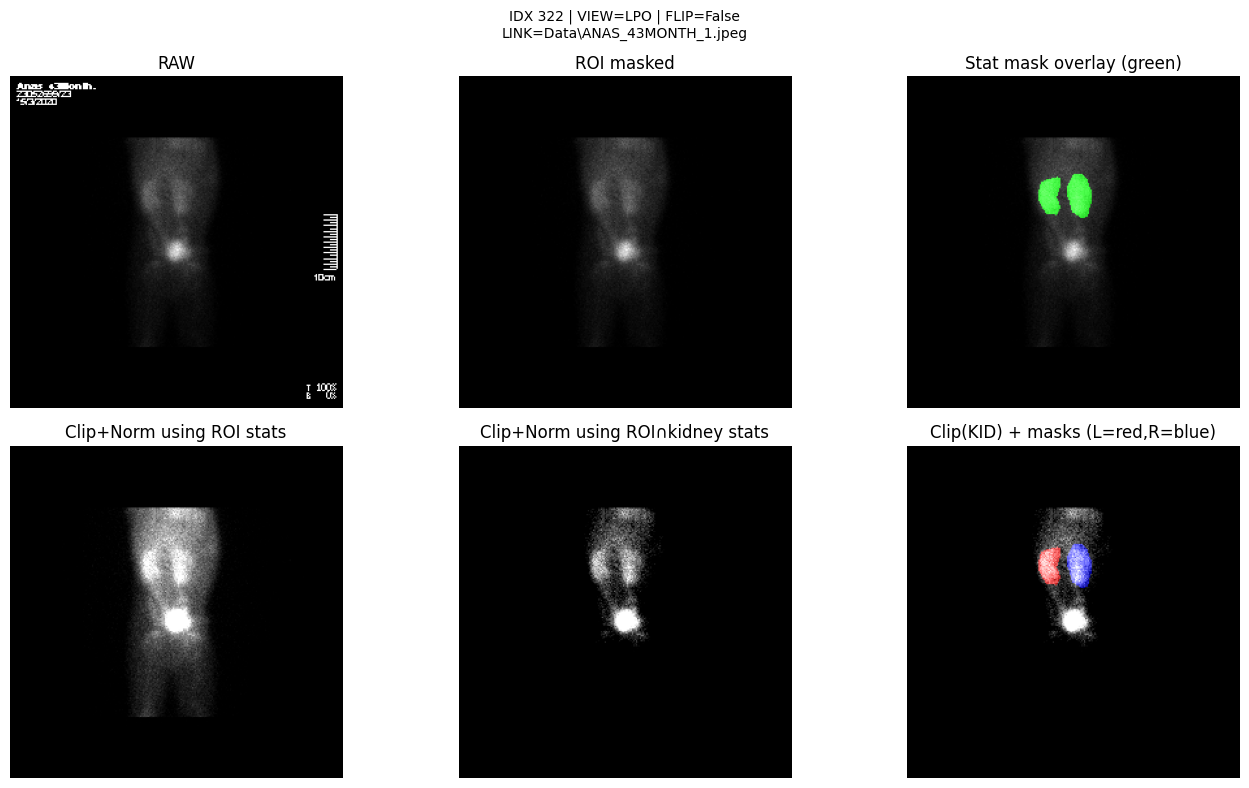

IDX 178 | VIEW=RPO | FLIP=True
LINK=Data\ABUL_KALAM_41_YRS_2.jpeg
Percentiles p1.0-p99.0:
  ROI only:        lo=0.0000 hi=0.6431
  ROI∩kidney-mask: lo=0.0745 hi=0.9098
Stat-mask pixels: 2176 | ROI pixels: 38416 | kidney pixels: 2176


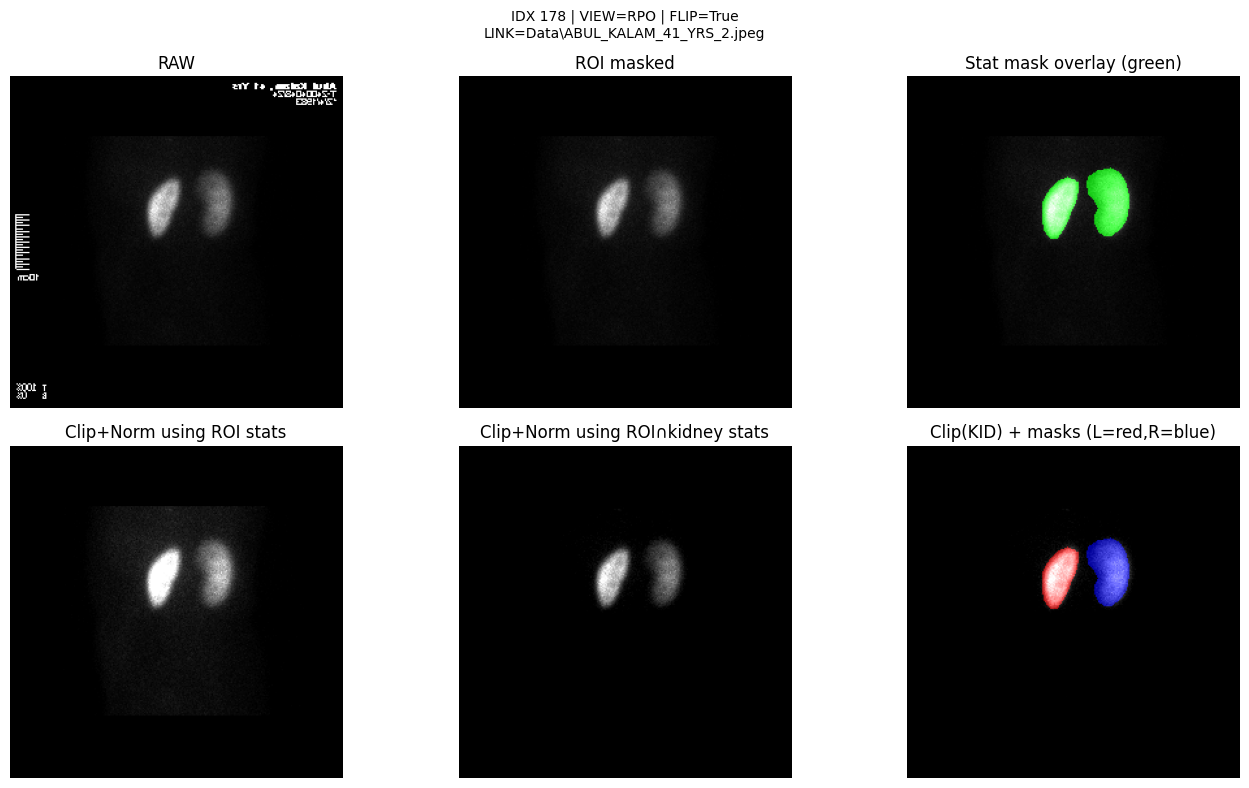

In [17]:
# CELL 16 — PROOF: Percentiles are computed from ROI∩kidney-mask (and show the stat-mask)
# Shows:
# - RAW/ROI
# - Stat mask overlay (green)
# - Percentiles computed from (ROI only) vs (ROI∩kidney-mask)
# - Before/after clip+norm visuals

def compute_percentiles(I_roi: np.ndarray, mask_bool: np.ndarray, p_lo=1.0, p_hi=99.0):
    vals = I_roi[mask_bool]
    if vals.size < 32:
        vals = I_roi.reshape(-1)
    lo = float(np.percentile(vals, p_lo))
    hi = float(np.percentile(vals, p_hi))
    return lo, hi

def show_statmask_proof(idx: int, p_lo=P_LO, p_hi=P_HI):
    row = df.iloc[idx]
    abs_path = Path(row["__ABS_PATH__"])
    link = row[COL_LINK]
    view_val = row[COL_VIEW] if COL_VIEW else None

    I_raw = load_gray_256(abs_path)
    ML, MR = load_masks_for_link(link)
    I_raw, ML, MR, did_flip = maybe_flip(I_raw, ML, MR, view_val)

    I_roi = I_raw * ROI_F
    roi_mask = ROI_U8.astype(bool)

    kidney_mask = ((ML > 0) | (MR > 0))
    stat_mask = roi_mask & kidney_mask
    if stat_mask.sum() < 32:
        stat_mask = roi_mask

    lo_roi, hi_roi = compute_percentiles(I_roi, roi_mask, p_lo=p_lo, p_hi=p_hi)
    lo_kid, hi_kid = compute_percentiles(I_roi, stat_mask, p_lo=p_lo, p_hi=p_hi)

    I_clip_roi = intensity_clip_norm(I_roi, mask=roi_mask, p_lo=p_lo, p_hi=p_hi)
    I_clip_kid = intensity_clip_norm(I_roi, mask=stat_mask, p_lo=p_lo, p_hi=p_hi)

    # overlay stat mask (green) on ROI image
    overlay = np.dstack([I_roi, I_roi, I_roi])
    overlay[..., 1] = np.clip(overlay[..., 1] + 0.7*stat_mask.astype(np.float32), 0, 1)

    title = f"IDX {idx} | VIEW={view_val} | FLIP={did_flip}\nLINK={link}"
    print(title)
    print(f"Percentiles p{p_lo}-p{p_hi}:")
    print(f"  ROI only:        lo={lo_roi:.4f} hi={hi_roi:.4f}")
    print(f"  ROI∩kidney-mask: lo={lo_kid:.4f} hi={hi_kid:.4f}")
    print(f"Stat-mask pixels: {int(stat_mask.sum())} | ROI pixels: {int(roi_mask.sum())} | kidney pixels: {int(kidney_mask.sum())}")

    fig = plt.figure(figsize=(14, 8))
    fig.suptitle(title, fontsize=10)

    ax = plt.subplot(2,3,1); ax.imshow(I_raw, cmap="gray"); ax.set_title("RAW"); ax.axis("off")
    ax = plt.subplot(2,3,2); ax.imshow(I_roi, cmap="gray"); ax.set_title("ROI masked"); ax.axis("off")
    ax = plt.subplot(2,3,3); ax.imshow(overlay); ax.set_title("Stat mask overlay (green)"); ax.axis("off")

    ax = plt.subplot(2,3,4); ax.imshow(I_clip_roi, cmap="gray"); ax.set_title("Clip+Norm using ROI stats"); ax.axis("off")
    ax = plt.subplot(2,3,5); ax.imshow(I_clip_kid, cmap="gray"); ax.set_title("Clip+Norm using ROI∩kidney stats"); ax.axis("off")

    # show mask overlay too
    I_tmp = np.clip(I_clip_kid,0,1)
    m_overlay = np.dstack([I_tmp, I_tmp, I_tmp])
    m_overlay[..., 0] = np.clip(m_overlay[..., 0] + 0.6*(ML>0), 0, 1)
    m_overlay[..., 2] = np.clip(m_overlay[..., 2] + 0.6*(MR>0), 0, 1)
    ax = plt.subplot(2,3,6); ax.imshow(m_overlay); ax.set_title("Clip(KID) + masks (L=red,R=blue)"); ax.axis("off")

    plt.tight_layout()
    plt.show()

# pick 2 masked samples and prove
masked_idxs = []
for i in range(min(800, len(df))):
    ML, MR = load_masks_for_link(df[COL_LINK].iloc[i])
    if (ML.sum() + MR.sum()) > 0:
        masked_idxs.append(i)

proof_picks = random.sample(masked_idxs, k=min(2, len(masked_idxs))) if masked_idxs else random.sample(range(len(df)), k=2)
print("Stat-mask proof picks:", proof_picks)

for idx in proof_picks:
    show_statmask_proof(idx)


In [18]:
# CELL 17 — LOCK IT: Make the "stats-from-kidney-mask" rule explicit (future-proof)
# Your current preprocess_for_model already behaves this way.
# This just makes it explicit and visible.

STATS_MODE = "roi_and_kidney_mask"  # locked rule

print("Locked clipping stats mode:", STATS_MODE)
print("Rule:")
print("  - Use ROI∩(ML∪MR) to compute percentiles when masks exist.")
print("  - Fallback to ROI when masks are empty/invalid.")


Locked clipping stats mode: roi_and_kidney_mask
Rule:
  - Use ROI∩(ML∪MR) to compute percentiles when masks exist.
  - Fallback to ROI when masks are empty/invalid.


In [19]:
# CELL 18 — Resolve ALL training-relevant CSV columns (no guessing) + show unique values (sanity)

COL_PATIENT_NAME = require_col(df, "PATIENT NAME")
COL_AGE_MONTHS   = require_col(df, "AGE in MONTHS")
COL_SEX          = require_col(df, "SEX")

COL_SIZE_L       = require_col(df, "SIZE LEFT")
COL_SIZE_R       = require_col(df, "SIZE RIGHT")

COL_ANATOMY      = require_col(df, "ANATOMY")
COL_KC_CSV       = require_col(df, "Kidney COUNT")

COL_SCAR_GLOBAL  = require_col(df, "SCAR")
COL_SCAR_L       = require_col(df, "SCAR LEFT")
COL_SCAR_R       = require_col(df, "SCAR RIGHT")

COL_UPTAKE_L     = require_col(df, "CORTICAL UPTAKE LEFT")
COL_UPTAKE_R     = require_col(df, "CORTICAL UPTAKE RIGHT")

# Optional (keep safe)
COL_POSITION     = optional_col(df, "POSITION")

print("Resolved key columns:")
for k, v in [
    ("COL_LINK", COL_LINK),
    ("COL_VIEW", COL_VIEW),
    ("COL_SIZE_L", COL_SIZE_L),
    ("COL_SIZE_R", COL_SIZE_R),
    ("COL_ANATOMY", COL_ANATOMY),
    ("COL_KC_CSV", COL_KC_CSV),
    ("COL_SCAR_GLOBAL", COL_SCAR_GLOBAL),
    ("COL_SCAR_L", COL_SCAR_L),
    ("COL_SCAR_R", COL_SCAR_R),
    ("COL_UPTAKE_L", COL_UPTAKE_L),
    ("COL_UPTAKE_R", COL_UPTAKE_R),
    ("COL_POSITION", COL_POSITION),
]:
    print(f"  {k}: {repr(v)}")

def show_uniques(col, n=30):
    vals = df[col].astype(str).fillna("NA").value_counts()
    print(f"\n[{col}] unique={len(vals)} | top {min(n,len(vals))}:")
    print(vals.head(n))

# Quick, explicit value sanity (this is just printing; no logic assumptions)
show_uniques(COL_ANATOMY)
show_uniques(COL_SIZE_L)
show_uniques(COL_SIZE_R)
show_uniques(COL_SCAR_L)
show_uniques(COL_SCAR_R)
show_uniques(COL_UPTAKE_L)
show_uniques(COL_UPTAKE_R)
show_uniques(COL_KC_CSV)
show_uniques(COL_SCAR_GLOBAL)
if COL_VIEW: show_uniques(COL_VIEW)


Resolved key columns:
  COL_LINK: 'LINK'
  COL_VIEW: 'VIEW'
  COL_SIZE_L: 'SIZE LEFT'
  COL_SIZE_R: 'SIZE RIGHT'
  COL_ANATOMY: 'ANATOMY'
  COL_KC_CSV: 'Kidney COUNT'
  COL_SCAR_GLOBAL: 'SCAR'
  COL_SCAR_L: 'SCAR LEFT'
  COL_SCAR_R: 'SCAR RIGHT'
  COL_UPTAKE_L: 'CORTICAL UPTAKE LEFT'
  COL_UPTAKE_R: 'CORTICAL UPTAKE RIGHT'
  COL_POSITION: 'POSITION'

[ANATOMY] unique=4 | top 4:
ANATOMY
NORMAL     1669
SINGLE      437
ECTOPIC     152
HORSHOE      36
Name: count, dtype: int64

[SIZE LEFT] unique=5 | top 5:
SIZE LEFT
NORMAL     1597
SMALLER     259
NV          204
BIGGER      165
PO           69
Name: count, dtype: int64

[SIZE RIGHT] unique=5 | top 5:
SIZE RIGHT
NORMAL     1535
NV          239
SMALLER     235
BIGGER      213
PO           72
Name: count, dtype: int64

[SCAR LEFT] unique=3 | top 3:
SCAR LEFT
NOT APPLICABLE    2111
MULTIPLE           171
SINGLE              12
Name: count, dtype: int64

[SCAR RIGHT] unique=3 | top 3:
SCAR RIGHT
NOT APPLICABLE    2114
MULTIPLE           174


In [20]:
# CELL 19 — Build GT presence from masks + parse labels for NEW targets (Scar binary + Anatomy 2-step + Size relation)

# ---- Parsers (string -> int) ----
def _s(x) -> str:
    return str(x).strip().upper()

# Anatomy2K base classes (both kidneys present):
# NORMAL / ECTOPIC / HORSHOE (note: your CSV uses "HORSHOE")
ANAT_MAP_3 = {
    "NORMAL": 0,
    "ECTOPIC": 1,
    "HORSHOE": 2,
}

# Size per side: only meaningful when kidney present AND label in {SMALLER,NORMAL,BIGGER}
SIZE_MAP_3 = {
    "SMALLER": 0,
    "NORMAL": 1,
    "BIGGER": 2,
}

# Scar per side: your CSV has {SINGLE, MULTIPLE, NOT APPLICABLE}
# We will convert to PRESENT=1 if SINGLE/MULTIPLE, and NONE=0 if NOT APPLICABLE *when kidney is present*.
# If kidney absent -> ignore loss (-1) and keep NA as rule.
SCAR_PRESENT_SET = {"SINGLE", "MULTIPLE"}
SCAR_NONE_TOKEN  = "NOT APPLICABLE"

def compute_presence_from_masks(link_value: str, view_val=None):
    """
    Ground-truth presence derived from masks (safe + consistent with your pipeline).
    """
    ML, MR = load_masks_for_link(link_value)
    # Apply the same flip rule as images so that "left/right" stays consistent across RPO
    I_dummy = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)  # dummy to reuse maybe_flip
    I_dummy, ML, MR, _did = maybe_flip(I_dummy, ML, MR, view_val)
    lp = 1 if ML.sum() > 0 else 0
    rp = 1 if MR.sum() > 0 else 0
    return lp, rp, ML, MR

def parse_anatomy_3(anat_str: str) -> int:
    return ANAT_MAP_3.get(_s(anat_str), -1)

def parse_size_3(sz_str: str) -> int:
    return SIZE_MAP_3.get(_s(sz_str), -1)

def parse_scar_present(scar_str: str) -> int:
    ss = _s(scar_str)
    if ss in SCAR_PRESENT_SET:
        return 1
    if ss == _s(SCAR_NONE_TOKEN):
        return 0
    return -1  # unknown token

def derive_size_relation(sizeL_3: int, sizeR_3: int) -> int:
    """
    Relation classes (both kidneys present and both labels valid):
      0 = L smaller than R
      1 = equal
      2 = L bigger than R
    """
    if sizeL_3 < 0 or sizeR_3 < 0:
        return -1
    if sizeL_3 < sizeR_3:
        return 0
    if sizeL_3 == sizeR_3:
        return 1
    return 2

# ---- Build new target columns (with progress bar) ----
LP_list, RP_list = [], []
ML_sum_list, MR_sum_list = [], []

anat3_list = []
anat_abn_list = []       # 0 normal, 1 abnormal, -1 ignore
anat_sub_list = []       # 0 ectopic, 1 horshoe, -1 ignore

scarL_bin_list = []      # present-only binary: 0 none, 1 present, -1 ignore
scarR_bin_list = []

sizeL_3_list = []
sizeR_3_list = []
size_rel_list = []       # 0/1/2, -1 ignore

for i in tqdm(range(len(df)), desc="Deriving GT from masks + parsing labels"):
    row = df.iloc[i]
    link = row[COL_LINK]
    view = row[COL_VIEW] if COL_VIEW else None

    # Presence from masks (GT)
    lp, rp, ML, MR = compute_presence_from_masks(link, view_val=view)
    LP_list.append(lp)
    RP_list.append(rp)
    ML_sum_list.append(int(ML.sum()))
    MR_sum_list.append(int(MR.sum()))

    # Anatomy 3-class valid only when both present AND anatomy in {NORMAL,ECTOPIC,HORSHOE}
    a3 = parse_anatomy_3(row[COL_ANATOMY])
    if lp == 1 and rp == 1 and a3 in (0, 1, 2):
        anat3_list.append(a3)
        # abnormal vs normal
        abn = 0 if a3 == 0 else 1
        anat_abn_list.append(abn)
        # subtype only if abnormal
        if a3 == 1:
            anat_sub_list.append(0)  # ectopic
        elif a3 == 2:
            anat_sub_list.append(1)  # horshoe
        else:
            anat_sub_list.append(-1)
    else:
        anat3_list.append(-1)
        anat_abn_list.append(-1)
        anat_sub_list.append(-1)

    # Scar per side: present-only binary; absent -> ignore
    sL = parse_scar_present(row[COL_SCAR_L])
    sR = parse_scar_present(row[COL_SCAR_R])
    if lp == 1:
        scarL_bin_list.append(sL if sL in (0, 1) else -1)
    else:
        scarL_bin_list.append(-1)
    if rp == 1:
        scarR_bin_list.append(sR if sR in (0, 1) else -1)
    else:
        scarR_bin_list.append(-1)

    # Size relation: only meaningful when both present and both side sizes valid (SMALLER/NORMAL/BIGGER)
    szL = parse_size_3(row[COL_SIZE_L])
    szR = parse_size_3(row[COL_SIZE_R])
    # Only trust size labels when that side is present
    if lp == 1 and szL not in (0,1,2):
        szL = -1
    if rp == 1 and szR not in (0,1,2):
        szR = -1

    sizeL_3_list.append(szL)
    sizeR_3_list.append(szR)
    if lp == 1 and rp == 1:
        size_rel_list.append(derive_size_relation(szL, szR))
    else:
        size_rel_list.append(-1)

# Attach to df
df["__LP_GT__"] = LP_list
df["__RP_GT__"] = RP_list
df["__ML_SUM__"] = ML_sum_list
df["__MR_SUM__"] = MR_sum_list

df["__ANAT3__"] = anat3_list
df["__ANAT_ABN__"] = anat_abn_list
df["__ANAT_SUB__"] = anat_sub_list

df["__SCARL_BIN__"] = scarL_bin_list
df["__SCARR_BIN__"] = scarR_bin_list

df["__SIZEL_3__"] = sizeL_3_list
df["__SIZER_3__"] = sizeR_3_list
df["__SIZE_REL__"] = size_rel_list

print("Done. New target columns added.")
df[["__LP_GT__","__RP_GT__","__ANAT3__","__ANAT_ABN__","__ANAT_SUB__","__SCARL_BIN__","__SCARR_BIN__","__SIZE_REL__"]].head(10)


Deriving GT from masks + parsing labels:   0%|          | 0/2294 [00:00<?, ?it/s]

Done. New target columns added.


,__LP_GT__,__RP_GT__,__ANAT3__,__ANAT_ABN__,__ANAT_SUB__,__SCARL_BIN__,__SCARR_BIN__,__SIZE_REL__
0,1,1,0,0,-1,0,1,1
1,1,1,0,0,-1,0,1,1
2,1,1,0,0,-1,0,1,1
3,1,1,0,0,-1,0,0,0
4,1,1,0,0,-1,0,0,0
5,1,1,0,0,-1,0,0,0
6,0,1,-1,-1,-1,-1,0,-1
7,0,1,-1,-1,-1,-1,0,-1
8,0,1,-1,-1,-1,-1,0,-1
9,1,1,0,0,-1,0,0,2


In [21]:
# CELL 20 — Imbalance report for the NEW targets (scar binary + anatomy two-step + size relation)
def vc(series, name):
    s = pd.Series(series)
    print(f"\n{name} value_counts:")
    print(s.value_counts(dropna=False).sort_index())

vc(df["__LP_GT__"], "__LP_GT__")
vc(df["__RP_GT__"], "__RP_GT__")

# Anatomy validity and distributions
valid_anat = df["__ANAT3__"] >= 0
print("\nANATOMY valid samples:", int(valid_anat.sum()), "out of", len(df))
vc(df.loc[valid_anat, "__ANAT3__"], "ANAT3 (0=NORMAL,1=ECTOPIC,2=HORSHOE)")
vc(df.loc[valid_anat, "__ANAT_ABN__"], "ANAT_ABN (0=normal,1=abnormal)")
vc(df.loc[df["__ANAT_SUB__"] >= 0, "__ANAT_SUB__"], "ANAT_SUB (0=ECTOPIC,1=HORSHOE)")

# Scar present-only binary distributions
valid_sL = df["__SCARL_BIN__"] >= 0
valid_sR = df["__SCARR_BIN__"] >= 0
print("\nSCARL valid samples:", int(valid_sL.sum()), "SCARR valid samples:", int(valid_sR.sum()))
vc(df.loc[valid_sL, "__SCARL_BIN__"], "SCARL_BIN (0=none,1=present)")
vc(df.loc[valid_sR, "__SCARR_BIN__"], "SCARR_BIN (0=none,1=present)")

# Size relation distributions (both present + size labels valid)
valid_rel = df["__SIZE_REL__"] >= 0
print("\nSIZE_REL valid samples:", int(valid_rel.sum()))
vc(df.loc[valid_rel, "__SIZE_REL__"], "SIZE_REL (0=L smaller,1=equal,2=L bigger)")



__LP_GT__ value_counts:
__LP_GT__
0     204
1    2090
Name: count, dtype: int64

__RP_GT__ value_counts:
__RP_GT__
0     239
1    2055
Name: count, dtype: int64

ANATOMY valid samples: 1851 out of 2294

ANAT3 (0=NORMAL,1=ECTOPIC,2=HORSHOE) value_counts:
__ANAT3__
0    1663
1     152
2      36
Name: count, dtype: int64

ANAT_ABN (0=normal,1=abnormal) value_counts:
__ANAT_ABN__
0    1663
1     188
Name: count, dtype: int64

ANAT_SUB (0=ECTOPIC,1=HORSHOE) value_counts:
__ANAT_SUB__
0    152
1     36
Name: count, dtype: int64

SCARL valid samples: 2090 SCARR valid samples: 2055

SCARL_BIN (0=none,1=present) value_counts:
__SCARL_BIN__
0    1907
1     183
Name: count, dtype: int64

SCARR_BIN (0=none,1=present) value_counts:
__SCARR_BIN__
0    1875
1     180
Name: count, dtype: int64

SIZE_REL valid samples: 1782

SIZE_REL (0=L smaller,1=equal,2=L bigger) value_counts:
__SIZE_REL__
0     378
1    1107
2     297
Name: count, dtype: int64


Scar examples picks:
  Left present (1): [426, 1101]
  Left none (0):    [1867, 1955]
  Right present (1): [46, 1818]
  Right none (0):    [1322, 1916]


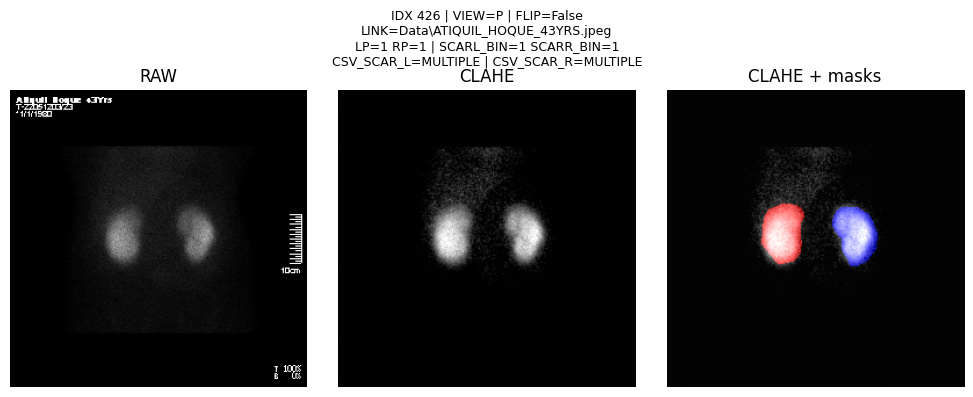

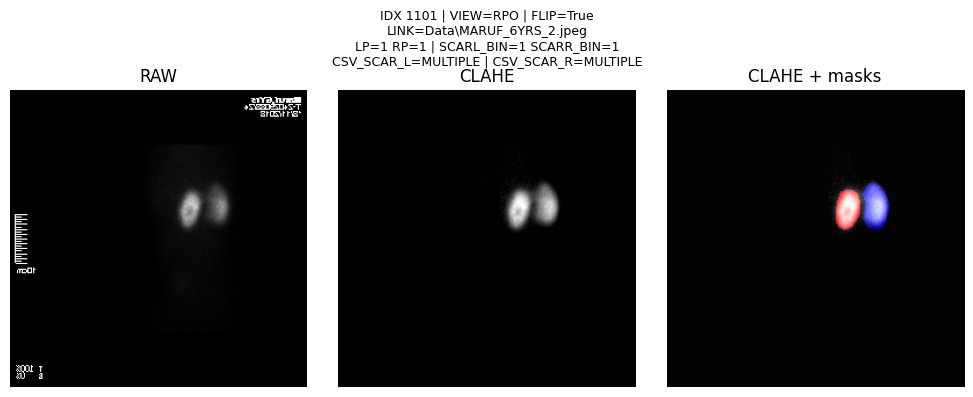

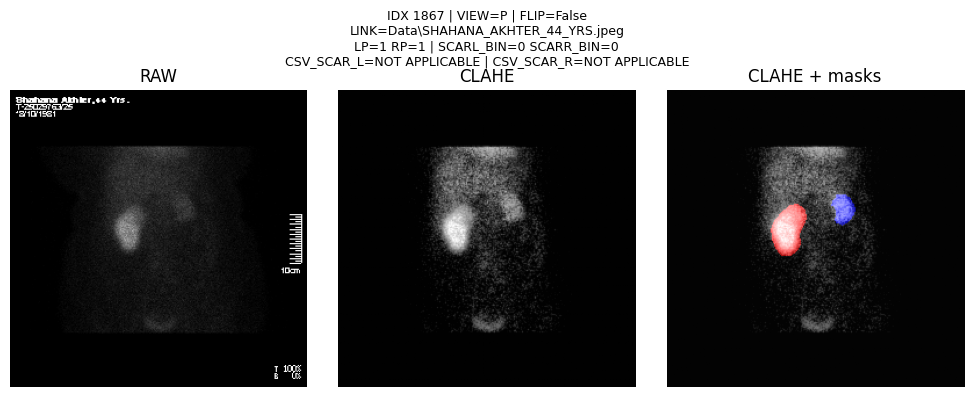

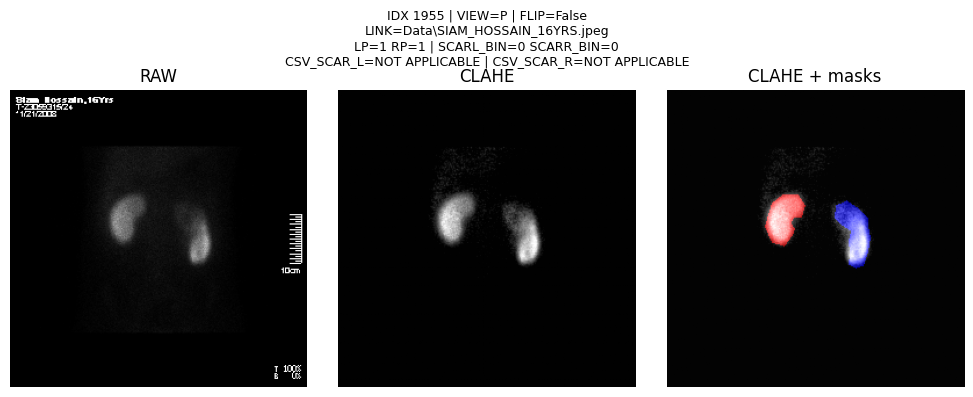

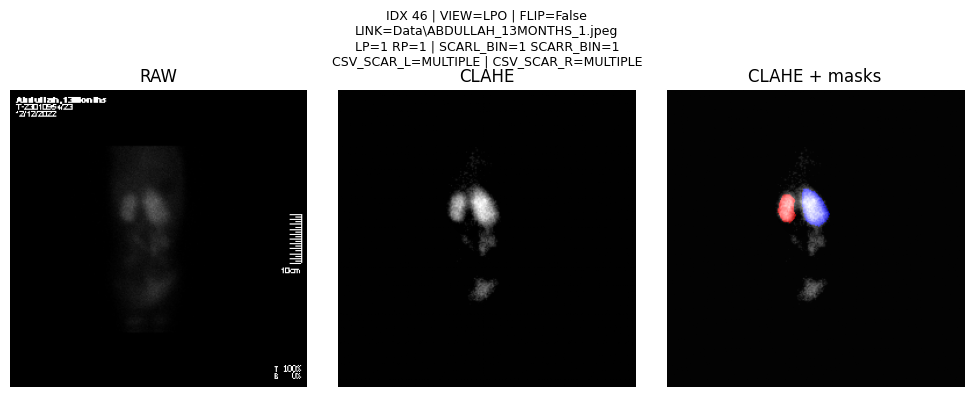

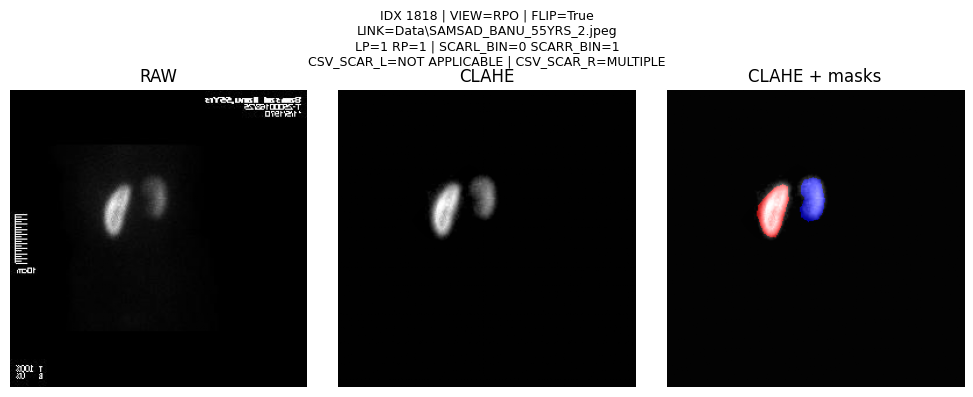

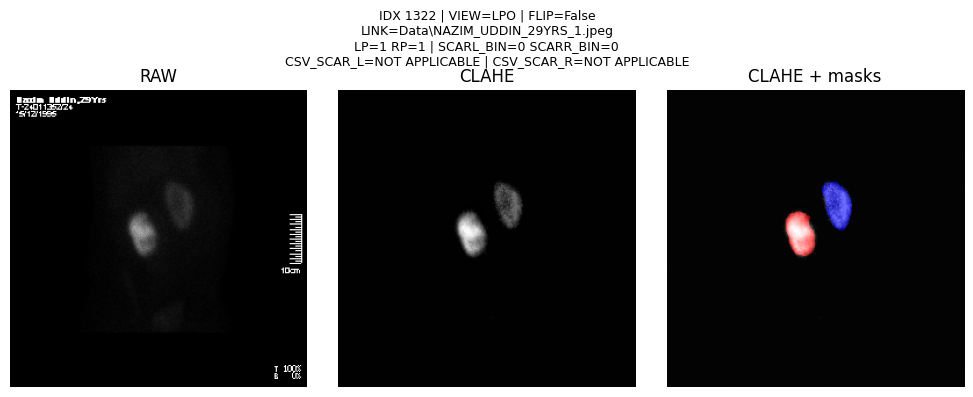

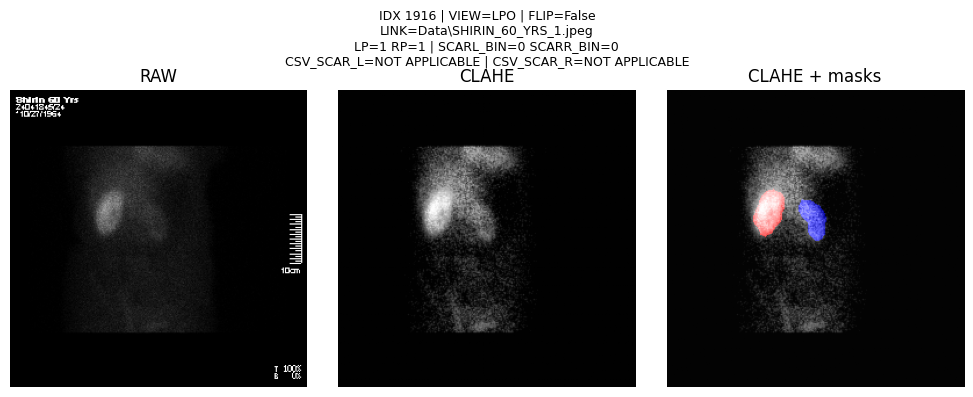

In [22]:
# CELL 21 — Visual verification for SCAR labels (show examples of scar-present vs scar-none)
# This proves that our "NOT APPLICABLE => NONE" is only applied when kidney is present (mask exists).

def pick_examples_for_scar(side="L", want=1, k=3, max_scan=2000):
    """
    side: 'L' or 'R'
    want: 1 (present) or 0 (none)
    """
    col = "__SCARL_BIN__" if side.upper() == "L" else "__SCARR_BIN__"
    idxs = []
    for i in range(min(max_scan, len(df))):
        if int(df[col].iloc[i]) == int(want):
            idxs.append(i)
    if len(idxs) == 0:
        return []
    return random.sample(idxs, k=min(k, len(idxs)))

def show_scar_case(idx: int):
    pack = preprocess_row(idx, p_lo=P_LO, p_hi=P_HI, do_clahe=True)
    ML, MR = pack["ML"], pack["MR"]
    I_c = pack["I_clahe"]

    overlay = np.dstack([I_c, I_c, I_c])
    overlay[..., 0] = np.clip(overlay[..., 0] + 0.6*(ML>0), 0, 1)
    overlay[..., 2] = np.clip(overlay[..., 2] + 0.6*(MR>0), 0, 1)

    title = (
        f"IDX {idx} | VIEW={pack['view']} | FLIP={pack['did_flip']}\n"
        f"LINK={pack['link']}\n"
        f"LP={df['__LP_GT__'].iloc[idx]} RP={df['__RP_GT__'].iloc[idx]} | "
        f"SCARL_BIN={df['__SCARL_BIN__'].iloc[idx]} SCARR_BIN={df['__SCARR_BIN__'].iloc[idx]}\n"
        f"CSV_SCAR_L={df[COL_SCAR_L].iloc[idx]} | CSV_SCAR_R={df[COL_SCAR_R].iloc[idx]}"
    )

    plt.figure(figsize=(10,4))
    plt.suptitle(title, fontsize=9)
    plt.subplot(1,3,1); plt.imshow(pack["I_raw"], cmap="gray"); plt.title("RAW"); plt.axis("off")
    plt.subplot(1,3,2); plt.imshow(pack["I_clahe"], cmap="gray"); plt.title("CLAHE"); plt.axis("off")
    plt.subplot(1,3,3); plt.imshow(overlay); plt.title("CLAHE + masks"); plt.axis("off")
    plt.tight_layout()
    plt.show()

# Pick and show examples
pL1 = pick_examples_for_scar("L", want=1, k=2)
pL0 = pick_examples_for_scar("L", want=0, k=2)
pR1 = pick_examples_for_scar("R", want=1, k=2)
pR0 = pick_examples_for_scar("R", want=0, k=2)

print("Scar examples picks:")
print("  Left present (1):", pL1)
print("  Left none (0):   ", pL0)
print("  Right present (1):", pR1)
print("  Right none (0):   ", pR0)

for idx in (pL1 + pL0 + pR1 + pR0):
    show_scar_case(idx)


In [23]:
# CELL 22 — Patient-level split (train/val/test) with HORSHOE enforcement (no leakage)
# Split unit = __PATIENT_BASE__ (your filename-based patient grouping)
# Goal:
# 1) Patient-disjoint splits
# 2) Ensure at least 1 HORSHOE patient in VAL and 1 in TEST (if possible)

SEED = 1337
rng = np.random.default_rng(SEED)

SPLIT_TRAIN = 0
SPLIT_VAL   = 1
SPLIT_TEST  = 2

SPLIT_NAME = {0: "train", 1: "val", 2: "test"}

# Unique patient IDs
patient_ids = df["__PATIENT_BASE__"].dropna().astype(str).unique().tolist()
patient_ids = sorted(patient_ids)
n_pat = len(patient_ids)
print("Total unique patient_ids:", n_pat)

# Identify HORSHOE patients (based on valid anatomy target)
horseshoe_patients = sorted(df.loc[df["__ANAT3__"] == 2, "__PATIENT_BASE__"].astype(str).unique().tolist())
print("HORSHOE patient_ids (unique):", len(horseshoe_patients))

# Targets for patient counts
n_val  = max(1, int(round(0.10 * n_pat)))
n_test = max(1, int(round(0.10 * n_pat)))
n_train = n_pat - n_val - n_test
if n_train < 1:
    # safety
    n_train = max(1, n_train)
print("Target patient counts:", {"train": n_train, "val": n_val, "test": n_test})

def make_patient_split(patient_ids, horseshoe_patients, n_train, n_val, n_test, rng):
    all_set = set(patient_ids)
    hs_set = set(horseshoe_patients)

    # Randomize order (stable w/ seed)
    ids = patient_ids.copy()
    rng.shuffle(ids)

    train_set = set()
    val_set   = set()
    test_set  = set()

    # --- Enforce horseshoe presence ---
    hs = list(horseshoe_patients)
    rng.shuffle(hs)

    # Put 1 HS in val and 1 HS in test if possible
    if len(hs) >= 1 and n_val > 0:
        val_set.add(hs[0])
    if len(hs) >= 2 and n_test > 0:
        test_set.add(hs[1])
    elif len(hs) == 1 and n_test > 0:
        # If only one HS patient exists, keep it in VAL; TEST can't have HS.
        pass

    # Fill remaining with the randomized ids list
    for pid in ids:
        if pid in val_set or pid in test_set:
            continue
        # Fill train first, then val, then test
        if len(train_set) < n_train:
            train_set.add(pid)
        elif len(val_set) < n_val:
            val_set.add(pid)
        elif len(test_set) < n_test:
            test_set.add(pid)

    # If any split is short (due to rounding or enforcement), fix by moving from train
    # (never violate disjointness)
    def move_from_train(target_set, target_n):
        nonlocal train_set
        if len(target_set) >= target_n:
            return
        need = target_n - len(target_set)
        move_ids = list(train_set)[:need]
        for m in move_ids:
            train_set.remove(m)
            target_set.add(m)

    move_from_train(val_set, n_val)
    move_from_train(test_set, n_test)

    # Final sanity: disjoint + coverage
    assert len(train_set & val_set) == 0
    assert len(train_set & test_set) == 0
    assert len(val_set & test_set) == 0
    assert len(train_set | val_set | test_set) == n_pat

    return train_set, val_set, test_set

train_pat, val_pat, test_pat = make_patient_split(patient_ids, horseshoe_patients, n_train, n_val, n_test, rng)

print("Patient split counts:", {"train": len(train_pat), "val": len(val_pat), "test": len(test_pat)})

# Proof of horseshoe enforcement
hs_train = len(set(horseshoe_patients) & train_pat)
hs_val   = len(set(horseshoe_patients) & val_pat)
hs_test  = len(set(horseshoe_patients) & test_pat)
print("HORSHOE patients by split:", {"train": hs_train, "val": hs_val, "test": hs_test})


Total unique patient_ids: 759
HORSHOE patient_ids (unique): 12
Target patient counts: {'train': 607, 'val': 76, 'test': 76}
Patient split counts: {'train': 607, 'val': 76, 'test': 76}
HORSHOE patients by split: {'train': 8, 'val': 1, 'test': 3}


In [24]:
# CELL 23 — Assign split label to each row + leak-proof checks
def split_of_patient(pid: str) -> int:
    if pid in train_pat:
        return SPLIT_TRAIN
    if pid in val_pat:
        return SPLIT_VAL
    return SPLIT_TEST

df["__SPLIT__"] = [split_of_patient(pid) for pid in df["__PATIENT_BASE__"].astype(str).tolist()]
df["__SPLIT_NAME__"] = df["__SPLIT__"].map(SPLIT_NAME)

print(df["__SPLIT_NAME__"].value_counts())

# Leak proof: no patient_id appears in more than one split
pat_to_splits = df.groupby("__PATIENT_BASE__")["__SPLIT__"].nunique()
bad = pat_to_splits[pat_to_splits > 1]
print("Patients with split leakage:", int((pat_to_splits > 1).sum()))
if len(bad) > 0:
    print("Leakage examples:")
    print(bad.head(20))
    raise RuntimeError("Split leakage detected. Stop and fix.")

print("✅ Patient-level splits are disjoint.")


__SPLIT_NAME__
train    1834
test      231
val       229
Name: count, dtype: int64
Patients with split leakage: 0
✅ Patient-level splits are disjoint.


In [25]:
# CELL 24 — Split report (images + key targets) to verify distributions + horseshoe presence
def report_split(df, split_id, name):
    sub = df[df["__SPLIT__"] == split_id]
    n_img = len(sub)
    n_pat = sub["__PATIENT_BASE__"].nunique()

    # anatomy counts (valid only)
    anat_valid = sub[sub["__ANAT3__"] >= 0]
    anat_counts = anat_valid["__ANAT3__"].value_counts().sort_index().to_dict()

    # horseshoe patient count
    hs_pat = sub.loc[sub["__ANAT3__"] == 2, "__PATIENT_BASE__"].nunique()

    # scar present counts (valid only)
    sL_valid = sub[sub["__SCARL_BIN__"] >= 0]["__SCARL_BIN__"].value_counts().sort_index().to_dict()
    sR_valid = sub[sub["__SCARR_BIN__"] >= 0]["__SCARR_BIN__"].value_counts().sort_index().to_dict()
    sL_present = int(sub["__SCARL_BIN__"].eq(1).sum())
    sR_present = int(sub["__SCARR_BIN__"].eq(1).sum())

    # size relation (valid only)
    rel_valid = sub[sub["__SIZE_REL__"] >= 0]["__SIZE_REL__"].value_counts().sort_index().to_dict()

    print(f"\n=== SPLIT: {name} ===")
    print("patients:", n_pat, "| images:", n_img)
    print("ANAT3 valid images:", len(anat_valid), "| counts (0=NORMAL,1=ECTOPIC,2=HORSHOE):", anat_counts)
    print("HORSHOE patients:", hs_pat)
    print("SCARL_BIN valid counts (0=none,1=present):", sL_valid, "| present_rows:", sL_present)
    print("SCARR_BIN valid counts (0=none,1=present):", sR_valid, "| present_rows:", sR_present)
    print("SIZE_REL valid counts (0=L smaller,1=equal,2=L bigger):", rel_valid)

report_split(df, SPLIT_TRAIN, "train")
report_split(df, SPLIT_VAL, "val")
report_split(df, SPLIT_TEST, "test")



=== SPLIT: train ===
patients: 607 | images: 1834
ANAT3 valid images: 1512 | counts (0=NORMAL,1=ECTOPIC,2=HORSHOE): {0: 1372, 1: 116, 2: 24}
HORSHOE patients: 8
SCARL_BIN valid counts (0=none,1=present): {0: 1537, 1: 150} | present_rows: 150
SCARR_BIN valid counts (0=none,1=present): {0: 1509, 1: 150} | present_rows: 150
SIZE_REL valid counts (0=L smaller,1=equal,2=L bigger): {0: 303, 1: 913, 2: 242}

=== SPLIT: val ===
patients: 76 | images: 229
ANAT3 valid images: 163 | counts (0=NORMAL,1=ECTOPIC,2=HORSHOE): {0: 147, 1: 13, 2: 3}
HORSHOE patients: 1
SCARL_BIN valid counts (0=none,1=present): {0: 187, 1: 15} | present_rows: 15
SCARR_BIN valid counts (0=none,1=present): {0: 178, 1: 12} | present_rows: 12
SIZE_REL valid counts (0=L smaller,1=equal,2=L bigger): {0: 42, 1: 91, 2: 27}

=== SPLIT: test ===
patients: 76 | images: 231
ANAT3 valid images: 176 | counts (0=NORMAL,1=ECTOPIC,2=HORSHOE): {0: 144, 1: 23, 2: 9}
HORSHOE patients: 3
SCARL_BIN valid counts (0=none,1=present): {0: 183, 

In [26]:
# CELL 25 — Balanced sampling weights (for TRAIN only)
# Strategy:
# - NO global downsampling
# - Use per-row weights to oversample rare signals:
#   * Horseshoe anatomy (ANAT3==2)
#   * Scar present on either side (SCARL_BIN==1 or SCARR_BIN==1)
#
# Notes:
# - Weights apply only in TRAIN loader later.
# - Moderate multipliers (start small; can tune later).
# - We cap weights to avoid extreme behavior.

W_BASE = 1.0
W_HORSHOE = 4.0       # horseshoe is very rare
W_SCAR_PRESENT = 3.0  # scar-present is rare
W_CAP = 10.0

train_mask = df["__SPLIT__"] == SPLIT_TRAIN
weights = np.ones(len(df), dtype=np.float32) * W_BASE

# boost horseshoe rows (only where anatomy valid)
weights[(train_mask) & (df["__ANAT3__"] == 2)] *= W_HORSHOE

# boost any scar-present rows (present-only binary)
scar_present_any = (df["__SCARL_BIN__"] == 1) | (df["__SCARR_BIN__"] == 1)
weights[(train_mask) & (scar_present_any)] *= W_SCAR_PRESENT

# cap
weights = np.minimum(weights, W_CAP)

df["__W_TRAIN__"] = weights

print("Train weights summary:")
w_train = df.loc[train_mask, "__W_TRAIN__"].values
print("  min:", float(w_train.min()), "max:", float(w_train.max()), "mean:", float(w_train.mean()))
print("  unique weights (train):", sorted(set([float(x) for x in np.unique(w_train)]))[:20], "...")

# Show how many train rows get boosted
print("Boosted horseshoe rows in train:", int(((train_mask) & (df["__ANAT3__"] == 2)).sum()))
print("Boosted scar-present rows in train:", int(((train_mask) & (scar_present_any)).sum()))
print("Boosted any rows in train:", int(((train_mask) & (df["__W_TRAIN__"] > W_BASE)).sum()))


Train weights summary:
  min: 1.0 max: 4.0 mean: 1.2486368417739868
  unique weights (train): [1.0, 3.0, 4.0] ...
Boosted horseshoe rows in train: 24
Boosted scar-present rows in train: 192
Boosted any rows in train: 216


In [27]:
# CELL 26 — (Optional) Torch sampler object creation (safe)
# If torch is installed, we create a WeightedRandomSampler for TRAIN rows.
# If not, we still keep the weights for later.

try:
    import torch
    from torch.utils.data import WeightedRandomSampler
    _HAS_TORCH = True
except Exception as e:
    _HAS_TORCH = False
    print("Torch not available in this environment:", e)

print("Torch available:", _HAS_TORCH)

if _HAS_TORCH:
    train_indices = np.where(df["__SPLIT__"].values == SPLIT_TRAIN)[0]
    train_weights = df.loc[train_indices, "__W_TRAIN__"].values.astype(np.float64)

    sampler = WeightedRandomSampler(
        weights=torch.as_tensor(train_weights, dtype=torch.double),
        num_samples=len(train_indices),   # 1 epoch ~= train size
        replacement=True
    )

    print("✅ Created WeightedRandomSampler for TRAIN.")
    print("  train_indices:", len(train_indices))
else:
    sampler = None


Torch available: True
✅ Created WeightedRandomSampler for TRAIN.
  train_indices: 1834


In [28]:
# CELL 27 — GPU / Torch sanity (must run on GPU if available)
# This cell proves PyTorch sees your GPU and sets the device we will use everywhere.

try:
    import torch
    print("torch version:", torch.__version__)
except Exception as e:
    raise RuntimeError(f"PyTorch is not available. Install torch with CUDA. Error: {e}")

CUDA_OK = torch.cuda.is_available()
print("CUDA available:", CUDA_OK)

if CUDA_OK:
    print("CUDA device count:", torch.cuda.device_count())
    cur = torch.cuda.current_device()
    print("Current device index:", cur)
    print("Device name:", torch.cuda.get_device_name(cur))
    print("Capability:", torch.cuda.get_device_capability(cur))
    # Optional: quick allocation test
    x = torch.randn(2, 3, device="cuda")
    print("GPU allocation test OK. x.device =", x.device)
    DEVICE = torch.device("cuda")
else:
    print("⚠️ CUDA not available. This will run on CPU unless you install CUDA-enabled PyTorch.")
    DEVICE = torch.device("cpu")

print("Using DEVICE =", DEVICE)


torch version: 2.5.1+cu121
CUDA available: True
CUDA device count: 1
Current device index: 0
Device name: NVIDIA GeForce GTX 1660 Ti
Capability: (7, 5)
GPU allocation test OK. x.device = cuda:0
Using DEVICE = cuda


In [29]:
# CELL 28 — Torch Dataset (uses your locked preprocessing + masks + view flip)
# Design:
# - No guessing of columns (we use resolved COL_* variables).
# - Returns tensors ready for model:
#   * I_ctx: [1,256,256] processed CLAHE image
#   * I_L:   [2,256,256] left focus stream [I*ML, ML]
#   * I_R:   [2,256,256] right focus stream [I*MR, MR]
# - Targets:
#   * LP, RP
#   * ANAT_ABN (0/1 or -1), ANAT_SUB (0/1 or -1)
#   * SCARL_BIN, SCARR_BIN (0/1 or -1)
#   * SIZE_REL (0/1/2 or -1)
# - Optional debug mode returns numpy images for visualization without breaking training.

import torch
from torch.utils.data import Dataset, DataLoader

class DMSADataset(Dataset):
    def __init__(self, df: pd.DataFrame, indices, return_debug: bool = False):
        self.df = df
        self.indices = list(indices)
        self.return_debug = bool(return_debug)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, j):
        idx = int(self.indices[j])
        row = self.df.iloc[idx]

        link = row[COL_LINK]
        view_val = row[COL_VIEW] if COL_VIEW else None
        abs_path = Path(row["__ABS_PATH__"])

        # load + masks
        I_raw = load_gray_256(abs_path)
        ML, MR = load_masks_for_link(link)

        # flip if RPO
        I_raw, ML, MR, did_flip = maybe_flip(I_raw, ML, MR, view_val)

        # preprocess (locked: percentiles from ROI∩(ML∪MR), fallback ROI)
        I_roi, I_clip, I_dnz, I_clahe, I_L_img, I_R_img = preprocess_for_model(
            I_raw, ML, MR, p_lo=P_LO, p_hi=P_HI, do_clahe=True
        )

        # Build tensors
        # Context: 1 channel CLAHE
        I_ctx = torch.from_numpy(I_clahe[None, :, :].astype(np.float32))  # [1,H,W]

        # Focus streams: [I*Mask, Mask]
        ML_f = ML.astype(np.float32)
        MR_f = MR.astype(np.float32)

        I_L = torch.from_numpy(np.stack([I_L_img.astype(np.float32), ML_f], axis=0))  # [2,H,W]
        I_R = torch.from_numpy(np.stack([I_R_img.astype(np.float32), MR_f], axis=0))  # [2,H,W]

        # Targets (ints), keep -1 for ignore
        t = {
            "idx": idx,
            "link": link,
            "view": str(view_val) if view_val is not None else "",
            "did_flip": bool(did_flip),

            "LP": int(row["__LP_GT__"]),
            "RP": int(row["__RP_GT__"]),

            "ANAT_ABN": int(row["__ANAT_ABN__"]),
            "ANAT_SUB": int(row["__ANAT_SUB__"]),

            "SCARL_BIN": int(row["__SCARL_BIN__"]),
            "SCARR_BIN": int(row["__SCARR_BIN__"]),

            "SIZE_REL": int(row["__SIZE_REL__"]),
        }

        if self.return_debug:
            dbg = {
                "I_raw": I_raw,
                "I_roi": I_roi,
                "I_clip": I_clip,
                "I_dnz": I_dnz,
                "I_clahe": I_clahe,
                "ML": ML,
                "MR": MR,
                "I_L_img": I_L_img,
                "I_R_img": I_R_img,
                "abs_path": str(abs_path),
            }
            return I_ctx, I_L, I_R, t, dbg

        return I_ctx, I_L, I_R, t

print("✅ DMSADataset defined.")


✅ DMSADataset defined.


In [30]:
# CELL 29 — Build DataLoaders (train uses WeightedRandomSampler if available)
# Defaults (edit freely):
BATCH_SIZE = 16
NUM_WORKERS = 0  # keep 0 for Windows stability unless you know it's safe to increase
PIN_MEMORY = True if str(DEVICE) == "cuda" else False

# Indices by split (patient-disjoint already proven)
train_indices = np.where(df["__SPLIT__"].values == SPLIT_TRAIN)[0].tolist()
val_indices   = np.where(df["__SPLIT__"].values == SPLIT_VAL)[0].tolist()
test_indices  = np.where(df["__SPLIT__"].values == SPLIT_TEST)[0].tolist()

print("Row counts by split:", {"train": len(train_indices), "val": len(val_indices), "test": len(test_indices)})

# Datasets
ds_train = DMSADataset(df, train_indices, return_debug=False)
ds_val   = DMSADataset(df, val_indices,   return_debug=False)
ds_test  = DMSADataset(df, test_indices,  return_debug=False)

# Train loader
if sampler is not None:
    # sampler is defined in CELL 26; it samples only train rows
    train_loader = DataLoader(
        ds_train,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    print("Train loader: using WeightedRandomSampler ✅")
else:
    train_loader = DataLoader(
        ds_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        drop_last=False,
    )
    print("Train loader: using shuffle=True (no sampler) ⚠️")

# Val/Test loaders (no sampler)
val_loader = DataLoader(
    ds_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

test_loader = DataLoader(
    ds_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    drop_last=False,
)

print("✅ DataLoaders created.")


Row counts by split: {'train': 1834, 'val': 229, 'test': 231}
Train loader: using WeightedRandomSampler ✅
✅ DataLoaders created.


Batch shapes:
  I_ctx: (16, 1, 256, 256)
  I_L:   (16, 2, 256, 256)
  I_R:   (16, 2, 256, 256)
  Targets keys: ['idx', 'link', 'view', 'did_flip', 'LP', 'RP', 'ANAT_ABN', 'ANAT_SUB', 'SCARL_BIN', 'SCARR_BIN', 'SIZE_REL']
Moved to device: cuda | I_ctx.device = cuda:0
Debug sample picks (within train dataset index space): [919, 576, 759]


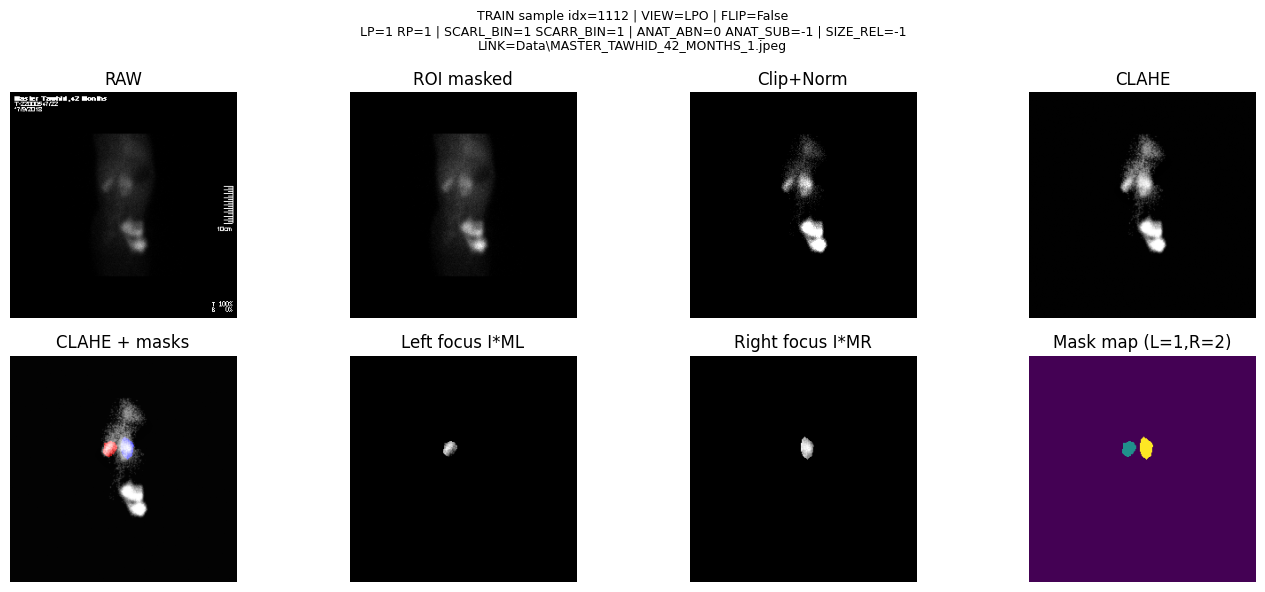

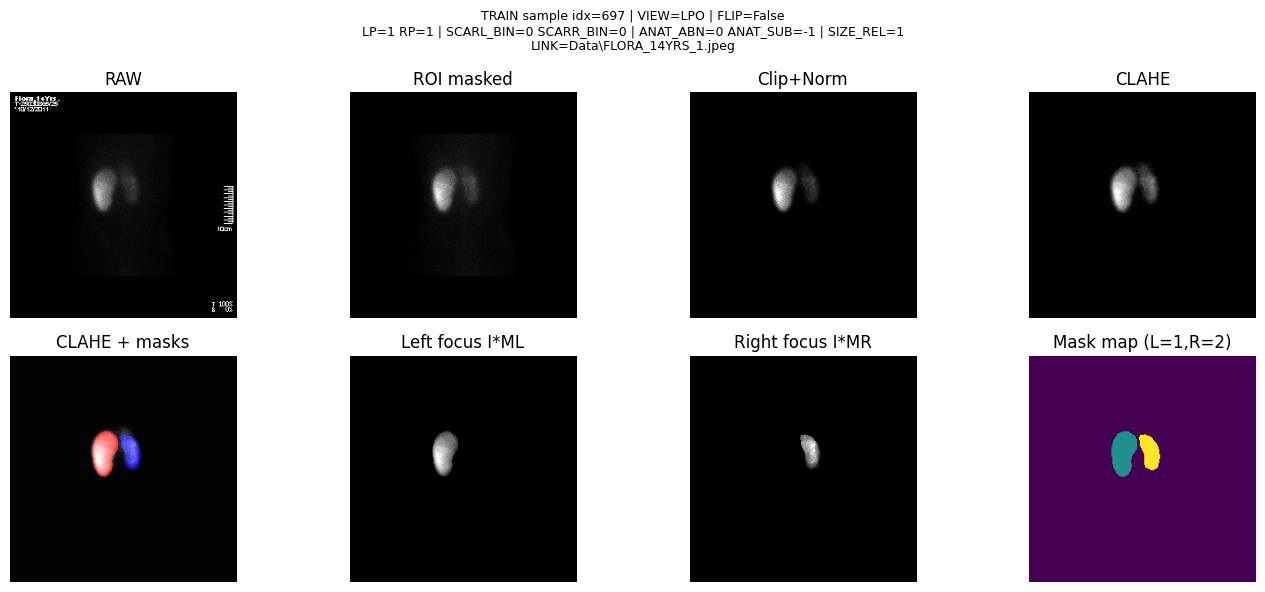

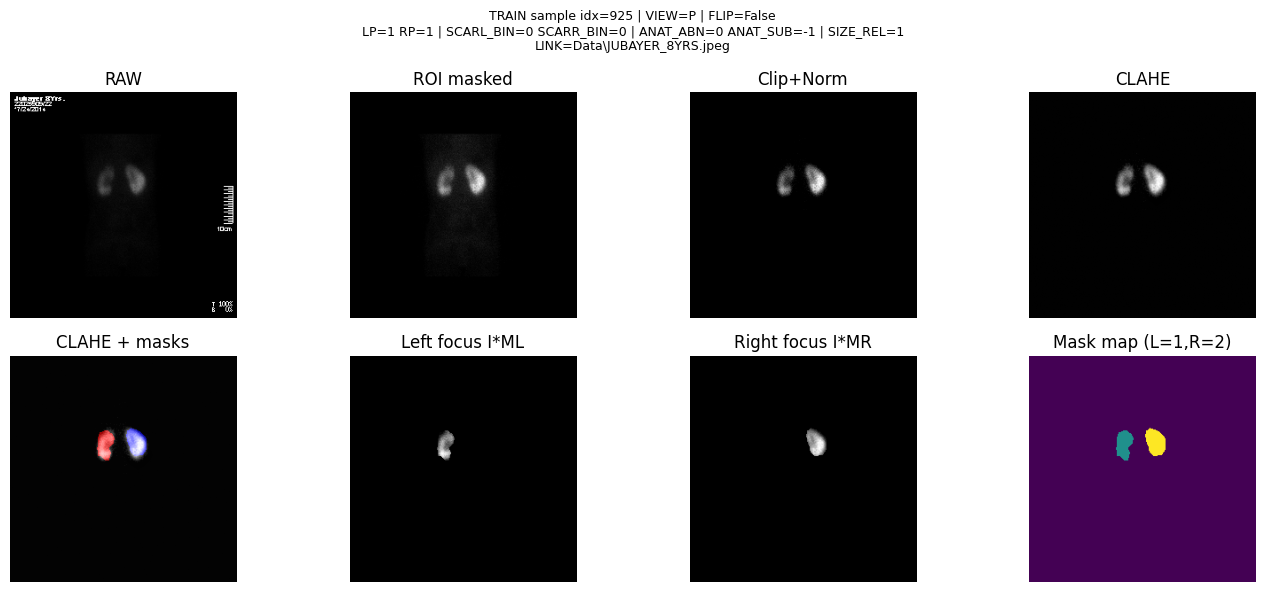

In [31]:
# CELL 30 — Loader sanity + GPU move test + visualization proof from a batch
# This cell proves:
# 1) Batches load without errors
# 2) Tensors can move to GPU
# 3) Preprocessing/masks are consistent visually (using a debug dataset for a few samples)

# --- 1) Batch load sanity ---
I_ctx_b, I_L_b, I_R_b, t_b = next(iter(train_loader))
print("Batch shapes:")
print("  I_ctx:", tuple(I_ctx_b.shape))  # [B,1,256,256]
print("  I_L:  ", tuple(I_L_b.shape))    # [B,2,256,256]
print("  I_R:  ", tuple(I_R_b.shape))    # [B,2,256,256]
print("  Targets keys:", list(t_b.keys()))

# --- 2) GPU move test ---
I_ctx_b = I_ctx_b.to(DEVICE, non_blocking=True)
I_L_b   = I_L_b.to(DEVICE, non_blocking=True)
I_R_b   = I_R_b.to(DEVICE, non_blocking=True)
print("Moved to device:", DEVICE, "| I_ctx.device =", I_ctx_b.device)

# --- 3) Visual proof (use debug dataset for 3 fixed samples from train) ---
ds_train_dbg = DMSADataset(df, train_indices, return_debug=True)

show_n = 3
rand_idxs = random.sample(range(len(ds_train_dbg)), k=min(show_n, len(ds_train_dbg)))
print("Debug sample picks (within train dataset index space):", rand_idxs)

for j in rand_idxs:
    I_ctx, I_L, I_R, t, dbg = ds_train_dbg[j]

    # reconstruct overlays
    I_c = dbg["I_clahe"]
    ML  = dbg["ML"]
    MR  = dbg["MR"]

    overlay = np.dstack([I_c, I_c, I_c])
    overlay[..., 0] = np.clip(overlay[..., 0] + 0.6*(ML>0), 0, 1)
    overlay[..., 2] = np.clip(overlay[..., 2] + 0.6*(MR>0), 0, 1)

    title = (
        f"TRAIN sample idx={t['idx']} | VIEW={t['view']} | FLIP={t['did_flip']}\n"
        f"LP={t['LP']} RP={t['RP']} | SCARL_BIN={t['SCARL_BIN']} SCARR_BIN={t['SCARR_BIN']} | "
        f"ANAT_ABN={t['ANAT_ABN']} ANAT_SUB={t['ANAT_SUB']} | SIZE_REL={t['SIZE_REL']}\n"
        f"LINK={t['link']}"
    )

    plt.figure(figsize=(14, 6))
    plt.suptitle(title, fontsize=9)

    plt.subplot(2,4,1); plt.imshow(dbg["I_raw"], cmap="gray"); plt.title("RAW"); plt.axis("off")
    plt.subplot(2,4,2); plt.imshow(dbg["I_roi"], cmap="gray"); plt.title("ROI masked"); plt.axis("off")
    plt.subplot(2,4,3); plt.imshow(dbg["I_clip"], cmap="gray"); plt.title("Clip+Norm"); plt.axis("off")
    plt.subplot(2,4,4); plt.imshow(dbg["I_clahe"], cmap="gray"); plt.title("CLAHE"); plt.axis("off")

    plt.subplot(2,4,5); plt.imshow(overlay); plt.title("CLAHE + masks"); plt.axis("off")

    # Focus stream channels
    plt.subplot(2,4,6); plt.imshow(dbg["I_L_img"], cmap="gray"); plt.title("Left focus I*ML"); plt.axis("off")
    plt.subplot(2,4,7); plt.imshow(dbg["I_R_img"], cmap="gray"); plt.title("Right focus I*MR"); plt.axis("off")
    plt.subplot(2,4,8); plt.imshow(ML + 2*MR, cmap="viridis"); plt.title("Mask map (L=1,R=2)"); plt.axis("off")

    plt.tight_layout()
    plt.show()


In [32]:
# CELL 31 — Config (training + backbone) — STABILITY FIX
BACKBONE_NAME = "inception_v3"   # "inception_v3" or "vgg16"
PRETRAINED = True

EPOCHS = 10

# Lower LR to reduce overflow risk with Inception feature extraction
LR = 1e-4
WEIGHT_DECAY = 1e-4

# Turn AMP off until training is stable (NaN-free)
USE_AMP = False

GRAD_CLIP_NORM = 1.0

# Class-weight caps (to avoid exploding rare-class weights)
MAX_CLASS_WEIGHT = 8.0

print("Config:")
print("  BACKBONE_NAME:", BACKBONE_NAME)
print("  PRETRAINED:", PRETRAINED)
print("  EPOCHS:", EPOCHS)
print("  LR:", LR)
print("  WEIGHT_DECAY:", WEIGHT_DECAY)
print("  USE_AMP:", USE_AMP)
print("  GRAD_CLIP_NORM:", GRAD_CLIP_NORM)
print("  MAX_CLASS_WEIGHT:", MAX_CLASS_WEIGHT)


Config:
  BACKBONE_NAME: inception_v3
  PRETRAINED: True
  EPOCHS: 10
  LR: 0.0001
  WEIGHT_DECAY: 0.0001
  USE_AMP: False
  GRAD_CLIP_NORM: 1.0
  MAX_CLASS_WEIGHT: 8.0


In [33]:
# CELL 32 — Backbone wrapper (torchvision preferred; timm fallback) — FIXED for Inception aux_logits
# Supports: Inception v3 (299 + ImageNet norm) and VGG16 (224 + ImageNet norm)
# For torchvision Inception v3 with weights: aux_logits MUST be True; we ignore aux outputs.

import torch
import torch.nn as nn
import torch.nn.functional as F

_IMAGENET_MEAN = (0.485, 0.456, 0.406)
_IMAGENET_STD  = (0.229, 0.224, 0.225)

def imagenet_norm(x3: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(_IMAGENET_MEAN, device=x3.device, dtype=x3.dtype).view(1,3,1,1)
    std  = torch.tensor(_IMAGENET_STD,  device=x3.device, dtype=x3.dtype).view(1,3,1,1)
    return (x3 - mean) / std

class TVBackbone(nn.Module):
    def __init__(self, name: str, pretrained: bool = True):
        super().__init__()
        self.name = name.lower().strip()
        self.pretrained = bool(pretrained)

        self.backend = "torchvision"
        self.out_dim = None

        try:
            from torchvision import models as tv_models
            self.tv_models = tv_models
        except Exception:
            self.tv_models = None
            self.backend = "timm"

        if self.backend == "torchvision":
            self._build_torchvision()
        else:
            self._build_timm()

    def _build_torchvision(self):
        tv_models = self.tv_models

        if self.name == "vgg16":
            m = tv_models.vgg16(weights=tv_models.VGG16_Weights.IMAGENET1K_V1 if self.pretrained else None)
            self.features = m.features
            self.avgpool = m.avgpool
            self.fc = nn.Sequential(
                nn.Flatten(),
                m.classifier[0],  # Linear(25088->4096)
                nn.ReLU(inplace=True),
                m.classifier[2],  # Dropout
            )
            self.out_dim = 4096

        elif self.name == "inception_v3":
            # IMPORTANT: torchvision forces aux_logits=True when weights are used.
            m = tv_models.inception_v3(
                weights=tv_models.Inception_V3_Weights.IMAGENET1K_V1 if self.pretrained else None,
                aux_logits=True,          # must be True with weights
                transform_input=True
            )
            # We'll use it as a feature extractor by stopping at avgpool.
            # In torchvision inception_v3, forward uses multiple internal blocks; easiest is to keep the full model
            # and extract features via its internal "avgpool" output pathway.
            self.inception = m
            self.out_dim = 2048

        else:
            raise ValueError(f"Unsupported BACKBONE_NAME='{self.name}' for torchvision backend.")

    def _build_timm(self):
        try:
            import timm
        except Exception as e:
            raise RuntimeError("Neither torchvision models nor timm is available. Install one of them.") from e

        if self.name == "vgg16":
            m = timm.create_model("vgg16", pretrained=self.pretrained, num_classes=0, global_pool="avg")
            self.features = m
            self.out_dim = m.num_features

        elif self.name == "inception_v3":
            m = timm.create_model("inception_v3", pretrained=self.pretrained, num_classes=0, global_pool="avg")
            self.features = m
            self.out_dim = m.num_features

        else:
            raise ValueError(f"Unsupported BACKBONE_NAME='{self.name}' for timm backend.")

    def forward(self, x1: torch.Tensor) -> torch.Tensor:
        """
        x1: [B,1,H,W] in [0,1]
        returns: [B, out_dim]
        """
        x3 = x1.repeat(1, 3, 1, 1)

        if self.name == "inception_v3":
            x3 = F.interpolate(x3, size=(299, 299), mode="bilinear", align_corners=False)
        elif self.name == "vgg16":
            x3 = F.interpolate(x3, size=(224, 224), mode="bilinear", align_corners=False)

        x3 = imagenet_norm(x3)

        if self.backend == "torchvision":
            if self.name == "vgg16":
                z = self.features(x3)
                z = self.avgpool(z)
                z = self.fc(z)
                return z

            # ---- inception_v3 feature extraction (ignore aux) ----
            m = self.inception

            # This follows torchvision's internal feature path (no classifier head).
            # We take pooled features: [B,2048,1,1] -> flatten to [B,2048]
            x = m.Conv2d_1a_3x3(x3)
            x = m.Conv2d_2a_3x3(x)
            x = m.Conv2d_2b_3x3(x)
            x = m.maxpool1(x)
            x = m.Conv2d_3b_1x1(x)
            x = m.Conv2d_4a_3x3(x)
            x = m.maxpool2(x)
            x = m.Mixed_5b(x)
            x = m.Mixed_5c(x)
            x = m.Mixed_5d(x)
            x = m.Mixed_6a(x)
            x = m.Mixed_6b(x)
            x = m.Mixed_6c(x)
            x = m.Mixed_6d(x)
            x = m.Mixed_6e(x)
            x = m.Mixed_7a(x)
            x = m.Mixed_7b(x)
            x = m.Mixed_7c(x)
            x = m.avgpool(x)
            x = torch.flatten(x, 1)
            return x

        else:
            return self.features(x3)

print("✅ Backbone wrapper ready (Inception aux_logits FIXED).")


✅ Backbone wrapper ready (Inception aux_logits FIXED).


In [34]:
# CELL 33 — Dual-stream multi-head model — FIX focus adapters (remove Sigmoid squashing)
# Inputs:
#   I_ctx: [B,1,256,256] (CLAHE)
#   I_L:   [B,2,256,256] where I_L[:,0]=I*ML, I_L[:,1]=ML
#   I_R:   [B,2,256,256] where I_R[:,0]=I*MR, I_R[:,1]=MR
#
# Focus adapter now is a simple 1x1 conv initialized to pass through channel0 (I*Mask).
# This avoids signal collapse and makes LP/RP learnable.

import torch
import torch.nn as nn
import torch.nn.functional as F

class DMSAMultiHead(nn.Module):
    def __init__(self, backbone_name: str, pretrained: bool = True):
        super().__init__()
        self.backbone = TVBackbone(backbone_name, pretrained=pretrained)
        d = self.backbone.out_dim

        # Focus adapters: 2ch -> 1ch (NO sigmoid)
        self.focusL = nn.Conv2d(2, 1, kernel_size=1, bias=False)
        self.focusR = nn.Conv2d(2, 1, kernel_size=1, bias=False)

        # Init: output ~= channel0 (I*Mask)
        with torch.no_grad():
            self.focusL.weight.zero_()
            self.focusR.weight.zero_()
            self.focusL.weight[0, 0, 0, 0] = 1.0
            self.focusR.weight[0, 0, 0, 0] = 1.0

        # Presence gates (binary logits)
        self.head_LP = nn.Linear(d, 2)
        self.head_RP = nn.Linear(d, 2)

        # Global heads from concat(FC, FL, FR)
        self.head_anat_abn = nn.Linear(d * 3, 2)  # normal vs abnormal
        self.head_anat_sub = nn.Linear(d * 3, 2)  # ectopic vs horshoe (valid only if abnormal)

        # Scar heads (present-only binary per side): NONE vs PRESENT
        self.head_scarL = nn.Linear(d * 2, 2)     # concat(FC, FL)
        self.head_scarR = nn.Linear(d * 2, 2)     # concat(FC, FR)

        # Size relation head (kc==2 only): L smaller / equal / L bigger
        self.head_size_rel = nn.Linear(d * 3, 3)

    def forward(self, I_ctx, I_L, I_R):
        # Context features
        FC = self.backbone(I_ctx)  # [B,d]

        # Focus features (2ch -> 1ch)
        IL1 = self.focusL(I_L)     # [B,1,H,W]
        IR1 = self.focusR(I_R)

        FL = self.backbone(IL1)    # [B,d]
        FR = self.backbone(IR1)    # [B,d]

        # Presence logits
        lp_logits = self.head_LP(FL)
        rp_logits = self.head_RP(FR)

        # Global concat
        G = torch.cat([FC, FL, FR], dim=1)

        return {
            "lp": lp_logits,
            "rp": rp_logits,
            "anat_abn": self.head_anat_abn(G),
            "anat_sub": self.head_anat_sub(G),
            "scarL": self.head_scarL(torch.cat([FC, FL], dim=1)),
            "scarR": self.head_scarR(torch.cat([FC, FR], dim=1)),
            "size_rel": self.head_size_rel(G),
        }

model = DMSAMultiHead(BACKBONE_NAME, pretrained=PRETRAINED).to(DEVICE)
print("✅ Model created on", DEVICE)
print("Backbone out_dim:", model.backbone.out_dim)

n_params = sum(p.numel() for p in model.parameters())
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Params:", f"{n_params:,}", "| trainable:", f"{n_trainable:,}")


✅ Model created on cuda
Backbone out_dim: 2048
Params: 27,228,867 | trainable: 27,228,867


In [35]:
# CELL 34 — Class weights (capped) computed from TRAIN split for each head (ignore -1)
# We compute weights as inverse-frequency, then cap to MAX_CLASS_WEIGHT.

def compute_class_weights_from_series(series: pd.Series, n_classes: int, max_w: float):
    s = series.values
    s = s[s >= 0]
    if len(s) == 0:
        return torch.ones(n_classes, dtype=torch.float32)
    counts = np.bincount(s.astype(int), minlength=n_classes).astype(np.float64)
    counts = np.maximum(counts, 1.0)
    inv = counts.sum() / (n_classes * counts)
    inv = np.minimum(inv, float(max_w))
    return torch.tensor(inv.astype(np.float32))

train_df = df[df["__SPLIT__"] == SPLIT_TRAIN]

w_lp = compute_class_weights_from_series(train_df["__LP_GT__"], 2, MAX_CLASS_WEIGHT)
w_rp = compute_class_weights_from_series(train_df["__RP_GT__"], 2, MAX_CLASS_WEIGHT)

w_anat_abn = compute_class_weights_from_series(train_df["__ANAT_ABN__"], 2, MAX_CLASS_WEIGHT)
w_anat_sub = compute_class_weights_from_series(train_df["__ANAT_SUB__"], 2, MAX_CLASS_WEIGHT)

w_scarL = compute_class_weights_from_series(train_df["__SCARL_BIN__"], 2, MAX_CLASS_WEIGHT)
w_scarR = compute_class_weights_from_series(train_df["__SCARR_BIN__"], 2, MAX_CLASS_WEIGHT)

w_size_rel = compute_class_weights_from_series(train_df["__SIZE_REL__"], 3, MAX_CLASS_WEIGHT)

print("Class weights (capped):")
print("  w_lp:", w_lp.tolist())
print("  w_rp:", w_rp.tolist())
print("  w_anat_abn:", w_anat_abn.tolist())
print("  w_anat_sub:", w_anat_sub.tolist())
print("  w_scarL:", w_scarL.tolist())
print("  w_scarR:", w_scarR.tolist())
print("  w_size_rel:", w_size_rel.tolist())

# Move to device
w_lp = w_lp.to(DEVICE)
w_rp = w_rp.to(DEVICE)
w_anat_abn = w_anat_abn.to(DEVICE)
w_anat_sub = w_anat_sub.to(DEVICE)
w_scarL = w_scarL.to(DEVICE)
w_scarR = w_scarR.to(DEVICE)
w_size_rel = w_size_rel.to(DEVICE)


Class weights (capped):
  w_lp: [6.238095283508301, 0.54356849193573]
  w_rp: [5.239999771118164, 0.552742600440979]
  w_anat_abn: [0.5510203838348389, 5.400000095367432]
  w_anat_sub: [0.6034482717514038, 2.9166667461395264]
  w_scarL: [0.5487963557243347, 5.62333345413208]
  w_scarR: [0.5497018098831177, 5.53000020980835]
  w_size_rel: [1.603960394859314, 0.5323110818862915, 2.0082645416259766]


In [36]:
# CELL 35 — Loss functions (masked by validity; no training on -1)
# We use CrossEntropyLoss with per-head class weights.
# For heads with ignore labels (-1), we compute loss only on valid indices.

ce_none = nn.CrossEntropyLoss(reduction="none")

def masked_ce_loss(logits: torch.Tensor, targets: torch.Tensor, class_w: torch.Tensor, ignore_value: int = -1):
    """
    logits: [B,C]
    targets: [B] with -1 for ignore
    class_w: [C]
    returns: scalar loss, valid_count
    """
    valid = (targets != ignore_value)
    if valid.sum().item() == 0:
        return logits.sum() * 0.0, 0  # zero loss on correct device/dtype
    t = targets[valid].long()
    l = F.cross_entropy(logits[valid], t, weight=class_w, reduction="mean")
    return l, int(valid.sum().item())

def to_targets(batch_t, key):
    # batch_t[key] is a list-like; DataLoader default collate gives list for strings, tensor for ints.
    v = batch_t[key]
    if isinstance(v, torch.Tensor):
        return v.to(DEVICE)
    return torch.tensor(v, device=DEVICE)

print("✅ Loss helpers ready.")


✅ Loss helpers ready.


In [37]:
# CELL 36 — Metrics helpers (accuracy + macro-F1) with ignore (-1)
def accuracy_ignore(pred: np.ndarray, gt: np.ndarray, ignore=-1):
    m = (gt != ignore)
    if m.sum() == 0:
        return None
    return float((pred[m] == gt[m]).mean())

def f1_macro_ignore(pred: np.ndarray, gt: np.ndarray, n_classes: int, ignore=-1):
    m = (gt != ignore)
    if m.sum() == 0:
        return None
    gt2 = gt[m].astype(int)
    pr2 = pred[m].astype(int)
    f1s = []
    for c in range(n_classes):
        tp = np.sum((pr2 == c) & (gt2 == c))
        fp = np.sum((pr2 == c) & (gt2 != c))
        fn = np.sum((pr2 != c) & (gt2 == c))
        prec = tp / (tp + fp + 1e-12)
        rec  = tp / (tp + fn + 1e-12)
        f1 = 2 * prec * rec / (prec + rec + 1e-12)
        f1s.append(f1)
    return float(np.mean(f1s))

print("✅ Metric helpers ready.")


✅ Metric helpers ready.


In [38]:
# CELL 37 — One epoch train + eval loops (tqdm + NaN guard) — AMP OFF SAFE
from torch.cuda.amp import autocast, GradScaler

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = GradScaler(enabled=False)  # AMP OFF

def is_finite_tensor(x: torch.Tensor) -> bool:
    return torch.isfinite(x).all().item()

def run_one_epoch_train(model, loader, optimizer, scaler):
    model.train()
    losses = []
    pbar = tqdm(loader, desc="train", leave=False)

    for step, (I_ctx, I_L, I_R, t) in enumerate(pbar, start=1):
        I_ctx = I_ctx.to(DEVICE, non_blocking=True)
        I_L   = I_L.to(DEVICE, non_blocking=True)
        I_R   = I_R.to(DEVICE, non_blocking=True)

        # targets
        LP = to_targets(t, "LP")
        RP = to_targets(t, "RP")
        ANAT_ABN = to_targets(t, "ANAT_ABN")
        ANAT_SUB = to_targets(t, "ANAT_SUB")
        SCARL = to_targets(t, "SCARL_BIN")
        SCARR = to_targets(t, "SCARR_BIN")
        SIZE_REL = to_targets(t, "SIZE_REL")

        optimizer.zero_grad(set_to_none=True)

        out = model(I_ctx, I_L, I_R)

        # Guard: catch NaNs/Infs in logits early
        for k, v in out.items():
            if not is_finite_tensor(v):
                raise RuntimeError(f"Non-finite logits detected in head '{k}' at step {step}")

        loss_lp, _ = masked_ce_loss(out["lp"], LP, w_lp, ignore_value=-1)
        loss_rp, _ = masked_ce_loss(out["rp"], RP, w_rp, ignore_value=-1)
        loss_abn, _ = masked_ce_loss(out["anat_abn"], ANAT_ABN, w_anat_abn, ignore_value=-1)
        loss_sub, _ = masked_ce_loss(out["anat_sub"], ANAT_SUB, w_anat_sub, ignore_value=-1)
        loss_sL, _  = masked_ce_loss(out["scarL"], SCARL, w_scarL, ignore_value=-1)
        loss_sR, _  = masked_ce_loss(out["scarR"], SCARR, w_scarR, ignore_value=-1)
        loss_rel, _ = masked_ce_loss(out["size_rel"], SIZE_REL, w_size_rel, ignore_value=-1)

        loss = loss_lp + loss_rp + loss_abn + loss_sub + loss_sL + loss_sR + loss_rel

        if not torch.isfinite(loss).item():
            raise RuntimeError(f"Non-finite LOSS at step {step}: {loss.detach().cpu().item()}")

        loss.backward()

        if GRAD_CLIP_NORM is not None and GRAD_CLIP_NORM > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)

        optimizer.step()

        losses.append(float(loss.detach().cpu().item()))
        pbar.set_postfix(loss=float(np.mean(losses)))

    return float(np.mean(losses)) if losses else None

@torch.no_grad()
def run_eval(model, loader, name="val"):
    model.eval()

    all_gt = {k: [] for k in ["LP","RP","ANAT_ABN","ANAT_SUB","SCARL_BIN","SCARR_BIN","SIZE_REL"]}
    all_pr = {k: [] for k in ["LP","RP","ANAT_ABN","ANAT_SUB","SCARL_BIN","SCARR_BIN","SIZE_REL"]}

    pbar = tqdm(loader, desc=name, leave=False)
    for (I_ctx, I_L, I_R, t) in pbar:
        I_ctx = I_ctx.to(DEVICE, non_blocking=True)
        I_L   = I_L.to(DEVICE, non_blocking=True)
        I_R   = I_R.to(DEVICE, non_blocking=True)

        out = model(I_ctx, I_L, I_R)

        pr_lp = out["lp"].argmax(dim=1).detach().cpu().numpy()
        pr_rp = out["rp"].argmax(dim=1).detach().cpu().numpy()
        pr_abn= out["anat_abn"].argmax(dim=1).detach().cpu().numpy()
        pr_sub= out["anat_sub"].argmax(dim=1).detach().cpu().numpy()
        pr_sL = out["scarL"].argmax(dim=1).detach().cpu().numpy()
        pr_sR = out["scarR"].argmax(dim=1).detach().cpu().numpy()
        pr_rel= out["size_rel"].argmax(dim=1).detach().cpu().numpy()

        gt_lp = to_targets(t, "LP").detach().cpu().numpy()
        gt_rp = to_targets(t, "RP").detach().cpu().numpy()
        gt_abn= to_targets(t, "ANAT_ABN").detach().cpu().numpy()
        gt_sub= to_targets(t, "ANAT_SUB").detach().cpu().numpy()
        gt_sL = to_targets(t, "SCARL_BIN").detach().cpu().numpy()
        gt_sR = to_targets(t, "SCARR_BIN").detach().cpu().numpy()
        gt_rel= to_targets(t, "SIZE_REL").detach().cpu().numpy()

        for k, pr, gt in [
            ("LP", pr_lp, gt_lp),
            ("RP", pr_rp, gt_rp),
            ("ANAT_ABN", pr_abn, gt_abn),
            ("ANAT_SUB", pr_sub, gt_sub),
            ("SCARL_BIN", pr_sL, gt_sL),
            ("SCARR_BIN", pr_sR, gt_sR),
            ("SIZE_REL", pr_rel, gt_rel),
        ]:
            all_pr[k].append(pr)
            all_gt[k].append(gt)

    for k in all_pr.keys():
        all_pr[k] = np.concatenate(all_pr[k]) if len(all_pr[k]) else np.array([])
        all_gt[k] = np.concatenate(all_gt[k]) if len(all_gt[k]) else np.array([])

    metrics = {}
    metrics["LP_acc"] = accuracy_ignore(all_pr["LP"], all_gt["LP"], ignore=-1)
    metrics["RP_acc"] = accuracy_ignore(all_pr["RP"], all_gt["RP"], ignore=-1)

    metrics["ANAT_ABN_acc"] = accuracy_ignore(all_pr["ANAT_ABN"], all_gt["ANAT_ABN"], ignore=-1)
    metrics["ANAT_ABN_f1m"] = f1_macro_ignore(all_pr["ANAT_ABN"], all_gt["ANAT_ABN"], 2, ignore=-1)

    metrics["ANAT_SUB_acc"] = accuracy_ignore(all_pr["ANAT_SUB"], all_gt["ANAT_SUB"], ignore=-1)
    metrics["ANAT_SUB_f1m"] = f1_macro_ignore(all_pr["ANAT_SUB"], all_gt["ANAT_SUB"], 2, ignore=-1)

    metrics["SCARL_acc"] = accuracy_ignore(all_pr["SCARL_BIN"], all_gt["SCARL_BIN"], ignore=-1)
    metrics["SCARL_f1m"] = f1_macro_ignore(all_pr["SCARL_BIN"], all_gt["SCARL_BIN"], 2, ignore=-1)

    metrics["SCARR_acc"] = accuracy_ignore(all_pr["SCARR_BIN"], all_gt["SCARR_BIN"], ignore=-1)
    metrics["SCARR_f1m"] = f1_macro_ignore(all_pr["SCARR_BIN"], all_gt["SCARR_BIN"], 2, ignore=-1)

    metrics["SIZE_REL_acc"] = accuracy_ignore(all_pr["SIZE_REL"], all_gt["SIZE_REL"], ignore=-1)
    metrics["SIZE_REL_f1m"] = f1_macro_ignore(all_pr["SIZE_REL"], all_gt["SIZE_REL"], 3, ignore=-1)

    return metrics

print("✅ Train/eval loops ready (NaN-guard, AMP off).")


✅ Train/eval loops ready (NaN-guard, AMP off).


C:\Users\User\AppData\Local\Temp\ipykernel_7440\151473551.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=False)  # AMP OFF


In [39]:
# CELL 38 — Train run (prints per-epoch metrics with progress bars)
history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\n[EPOCH {epoch:02d}/{EPOCHS}]")
    tr_loss = run_one_epoch_train(model, train_loader, optimizer, scaler)
    val_metrics = run_eval(model, val_loader, name="val")

    row = {"epoch": epoch, "train_loss": tr_loss}
    row.update(val_metrics)
    history.append(row)

    # pretty print (short)
    print("train_loss:", f"{tr_loss:.4f}" if tr_loss is not None else None)
    print("val:", {k: (None if v is None else round(v, 4)) for k, v in val_metrics.items()})

# Make a dataframe for easy viewing
hist_df = pd.DataFrame(history)
hist_df



[EPOCH 01/10]


train:   0%|          | 0/115 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

train_loss: 2.8506
val: {'LP_acc': 1.0, 'RP_acc': 1.0, 'ANAT_ABN_acc': 0.9816, 'ANAT_ABN_f1m': 0.9432, 'ANAT_SUB_acc': 1.0, 'ANAT_SUB_f1m': 1.0, 'SCARL_acc': 0.5396, 'SCARL_f1m': 0.4348, 'SCARR_acc': 0.3895, 'SCARR_f1m': 0.3314, 'SIZE_REL_acc': 0.7375, 'SIZE_REL_f1m': 0.7091}

[EPOCH 02/10]


train:   0%|          | 0/115 [00:00<?, ?it/s]

...

train_loss: 0.3340
val: {'LP_acc': 1.0, 'RP_acc': 1.0, 'ANAT_ABN_acc': 0.9877, 'ANAT_ABN_f1m': 0.9633, 'ANAT_SUB_acc': 0.9375, 'ANAT_SUB_f1m': 0.8815, 'SCARL_acc': 0.8663, 'SCARL_f1m': 0.5984, 'SCARR_acc': 0.7947, 'SCARR_f1m': 0.4886, 'SIZE_REL_acc': 0.7312, 'SIZE_REL_f1m': 0.7096}

[EPOCH 10/10]


train:   0%|          | 0/115 [00:00<?, ?it/s]

val:   0%|          | 0/15 [00:00<?, ?it/s]

train_loss: 0.3510
val: {'LP_acc': 1.0, 'RP_acc': 1.0, 'ANAT_ABN_acc': 0.9571, 'ANAT_ABN_f1m': 0.8484, 'ANAT_SUB_acc': 0.75, 'ANAT_SUB_f1m': 0.7091, 'SCARL_acc': 0.8614, 'SCARL_f1m': 0.6115, 'SCARR_acc': 0.8053, 'SCARR_f1m': 0.5149, 'SIZE_REL_acc': 0.6813, 'SIZE_REL_f1m': 0.5906}


,epoch,train_loss,LP_acc,RP_acc,ANAT_ABN_acc,ANAT_ABN_f1m,ANAT_SUB_acc,ANAT_SUB_f1m,SCARL_acc,SCARL_f1m,SCARR_acc,SCARR_f1m,SIZE_REL_acc,SIZE_REL_f1m
0,1,2.850647,1.0,1.0,0.981595,0.943225,1.0000,1.000000,0.539604,0.434753,0.389474,0.331392,0.73750,0.709119
1,2,1.745797,1.0,1.0,0.969325,0.905376,0.8750,0.833333,0.811881,0.533884,0.826316,0.505949,0.71875,0.707090
2,3,1.252692,1.0,1.0,0.975460,0.926577,0.6875,0.653680,0.846535,0.612380,0.842105,0.580882,0.76250,0.692449
3,4,0.973726,1.0,1.0,0.938650,0.756280,0.7500,0.709091,0.876238,0.608982,0.800000,0.546938,0.76250,0.724469
4,5,0.761066,1.0,1.0,0.950920,0.853153,0.7500,0.709091,0.886139,0.620518,0.894737,0.517522,0.79375,0.766946
5,6,0.606882,1.0,1.0,0.957055,0.858665,0.8750,0.833333,0.787129,0.573274,0.752632,0.514964,0.77500,0.730529
6,7,0.515106,1.0,1.0,0.981595,0.946528,1.0000,1.000000,0.915842,0.684230,0.926316,0.543269,0.77500,0.743583
7,8,0.476592,1.0,1.0,0.944785,0.829676,0.7500,0.709091,0.826733,0.562365,0.668421,0.476721,0.76875,0.736131
8,9,0.334014,1.0,1.0,0.987730,0.963288,0.9375,0.881481,0.866337,0.598350,0.794737,0.488648,0.73125,0.709642
9,10,0.351006,1.0,1.0,0.957055,0.848372,0.7500,0.709091,0.861386,0.611538,0.805263,0.514871,0.68125,0.590601


In [40]:
# CELL 39 — Final training summary (history) + pick “best epoch” by Scar mean F1 (val)
# Assumes hist_df exists from CELL 38

if "hist_df" not in globals():
    hist_df = pd.DataFrame(history)

hist_df["SCAR_mean_f1m"] = hist_df[["SCARL_f1m", "SCARR_f1m"]].mean(axis=1)
hist_df["SCAR_mean_acc"] = hist_df[["SCARL_acc", "SCARR_acc"]].mean(axis=1)

display(hist_df)

best_row = hist_df.sort_values(["SCAR_mean_f1m", "SCAR_mean_acc"], ascending=False).iloc[0]
print("\nBest epoch by SCAR mean F1 (val):")
print(best_row.to_dict())

print("\nLast epoch:")
print(hist_df.iloc[-1].to_dict())


,epoch,train_loss,LP_acc,RP_acc,ANAT_ABN_acc,ANAT_ABN_f1m,ANAT_SUB_acc,ANAT_SUB_f1m,SCARL_acc,SCARL_f1m,SCARR_acc,SCARR_f1m,SIZE_REL_acc,SIZE_REL_f1m,SCAR_mean_f1m,SCAR_mean_acc
0,1,2.850647,1.0,1.0,0.981595,0.943225,1.0000,1.000000,0.539604,0.434753,0.389474,0.331392,0.73750,0.709119,0.383072,0.464539
1,2,1.745797,1.0,1.0,0.969325,0.905376,0.8750,0.833333,0.811881,0.533884,0.826316,0.505949,0.71875,0.707090,0.519916,0.819098
2,3,1.252692,1.0,1.0,0.975460,0.926577,0.6875,0.653680,0.846535,0.612380,0.842105,0.580882,0.76250,0.692449,0.596631,0.844320
3,4,0.973726,1.0,1.0,0.938650,0.756280,0.7500,0.709091,0.876238,0.608982,0.800000,0.546938,0.76250,0.724469,0.577960,0.838119
4,5,0.761066,1.0,1.0,0.950920,0.853153,0.7500,0.709091,0.886139,0.620518,0.894737,0.517522,0.79375,0.766946,0.569020,0.890438
5,6,0.606882,1.0,1.0,0.957055,0.858665,0.8750,0.833333,0.787129,0.573274,0.752632,0.514964,0.77500,0.730529,0.544119,0.769880
6,7,0.515106,1.0,1.0,0.981595,0.946528,1.0000,1.000000,0.915842,0.684230,0.926316,0.543269,0.77500,0.743583,0.613750,0.921079
7,8,0.476592,1.0,1.0,0.944785,0.829676,0.7500,0.709091,0.826733,0.562365,0.668421,0.476721,0.76875,0.736131,0.519543,0.747577
8,9,0.334014,1.0,1.0,0.987730,0.963288,0.9375,0.881481,0.866337,0.598350,0.794737,0.488648,0.73125,0.709642,0.543499,0.830537
9,10,0.351006,1.0,1.0,0.957055,0.848372,0.7500,0.709091,0.861386,0.611538,0.805263,0.514871,0.68125,0.590601,0.563205,0.833325



Best epoch by SCAR mean F1 (val):
{'epoch': 7.0, 'train_loss': 0.5151056704961735, 'LP_acc': 1.0, 'RP_acc': 1.0, 'ANAT_ABN_acc': 0.9815950920245399, 'ANAT_ABN_f1m': 0.9465281574625624, 'ANAT_SUB_acc': 1.0, 'ANAT_SUB_f1m': 0.9999999999992949, 'SCARL_acc': 0.9158415841584159, 'SCARL_f1m': 0.6842298850569547, 'SCARR_acc': 0.9263157894736842, 'SCARR_f1m': 0.543269230768783, 'SIZE_REL_acc': 0.775, 'SIZE_REL_f1m': 0.7435834051925526, 'SCAR_mean_f1m': 0.6137495579128689, 'SCAR_mean_acc': 0.9210786868160501}

Last epoch:
{'epoch': 10.0, 'train_loss': 0.35100598699696683, 'LP_acc': 1.0, 'RP_acc': 1.0, 'ANAT_ABN_acc': 0.9570552147239264, 'ANAT_ABN_f1m': 0.8483720930227434, 'ANAT_SUB_acc': 0.75, 'ANAT_SUB_f1m': 0.7090909090903601, 'SCARL_acc': 0.8613861386138614, 'SCARL_f1m': 0.6115384615379673, 'SCARR_acc': 0.8052631578947368, 'SCARR_f1m': 0.5148712994267745, 'SIZE_REL_acc': 0.68125, 'SIZE_REL_f1m': 0.5906013396646993, 'SCAR_mean_f1m': 0.5632048804823708, 'SCAR_mean_acc': 0.8333246482542991}


In [41]:
# CELL 40 — TEST evaluation (row-level) + derived KidneyCount metrics (0/1/2) from LP/RP
# Uses run_eval() (already defined) + extra derived metrics.

test_metrics = run_eval(model, test_loader, name="test")
print("TEST metrics (row-level):")
print({k: (None if v is None else round(v, 4)) for k, v in test_metrics.items()})

# ---- Derived kidney count on TEST (from LP+RP) ----
@torch.no_grad()
def eval_kidney_count_from_presence(model, loader, name="test_count"):
    model.eval()
    all_pred = []
    all_gt = []

    pbar = tqdm(loader, desc=name, leave=False)
    for (I_ctx, I_L, I_R, t) in pbar:
        I_ctx = I_ctx.to(DEVICE, non_blocking=True)
        I_L   = I_L.to(DEVICE, non_blocking=True)
        I_R   = I_R.to(DEVICE, non_blocking=True)

        out = model(I_ctx, I_L, I_R)
        lp = out["lp"].argmax(dim=1)
        rp = out["rp"].argmax(dim=1)

        pred_cnt = (lp + rp).detach().cpu().numpy().astype(int)

        gt_lp = to_targets(t, "LP").detach().cpu().numpy().astype(int)
        gt_rp = to_targets(t, "RP").detach().cpu().numpy().astype(int)
        gt_cnt = (gt_lp + gt_rp).astype(int)

        all_pred.append(pred_cnt)
        all_gt.append(gt_cnt)

    pred = np.concatenate(all_pred) if all_pred else np.array([], dtype=int)
    gt   = np.concatenate(all_gt) if all_gt else np.array([], dtype=int)

    acc = float((pred == gt).mean()) if len(gt) else None
    # macro-F1 for 3 classes (0/1/2)
    f1m = f1_macro_ignore(pred, gt, n_classes=3, ignore=-999) if len(gt) else None

    return {"count_acc": acc, "count_f1m": f1m, "pred": pred, "gt": gt}

count_res = eval_kidney_count_from_presence(model, test_loader, name="test_count")
print("\nTEST KidneyCount (derived from LP+RP):")
print({k: (v if k in ["pred","gt"] else (None if v is None else round(v, 4))) for k, v in count_res.items()})


test:   0%|          | 0/15 [00:00<?, ?it/s]

TEST metrics (row-level):
{'LP_acc': 1.0, 'RP_acc': 1.0, 'ANAT_ABN_acc': 0.9261, 'ANAT_ABN_f1m': 0.8556, 'ANAT_SUB_acc': 0.8438, 'ANAT_SUB_f1m': 0.8228, 'SCARL_acc': 0.8756, 'SCARL_f1m': 0.6745, 'SCARR_acc': 0.8447, 'SCARR_f1m': 0.6085, 'SIZE_REL_acc': 0.7439, 'SIZE_REL_f1m': 0.6573}


test_count:   0%|          | 0/15 [00:00<?, ?it/s]


TEST KidneyCount (derived from LP+RP):
{'count_acc': 1.0, 'count_f1m': 0.6667, 'pred': array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,
       1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2,
       1, 1, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2,
       1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]), 'gt': array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 

collect_test_preds:   0%|          | 0/15 [00:00<?, ?it/s]

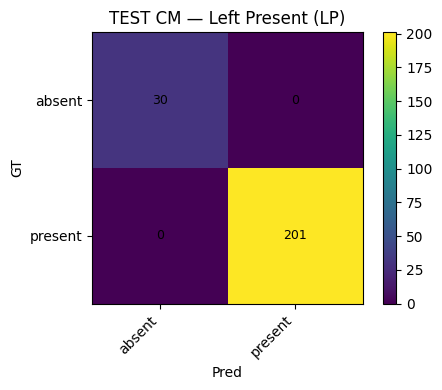

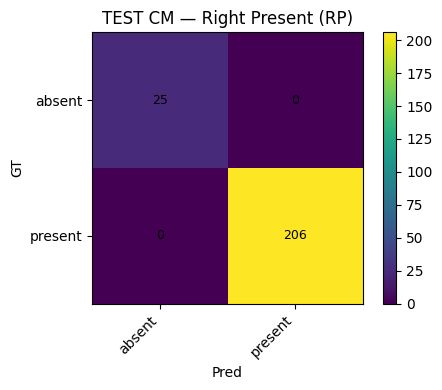

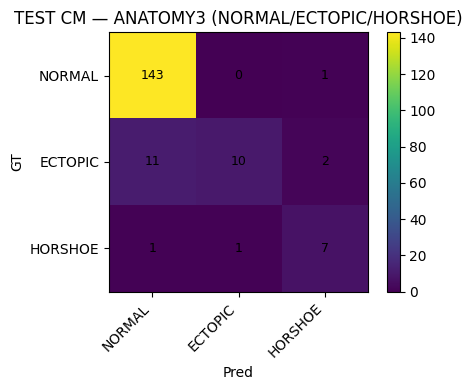

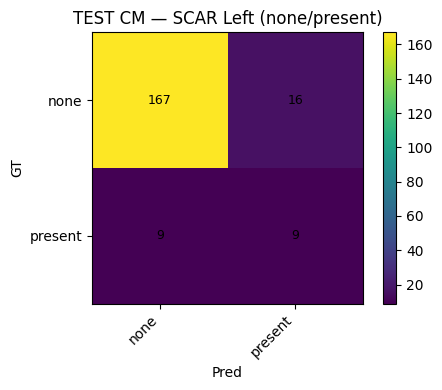

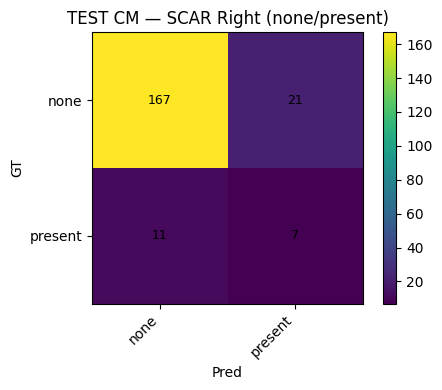

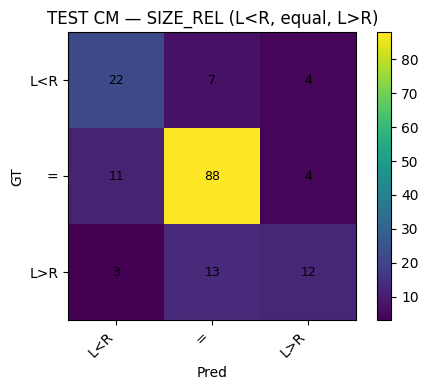

Counts (valid samples):
  ANAT3 valid: 176
  SCARL valid: 201 | SCARR valid: 206
  SIZE_REL valid: 164


In [42]:
# CELL 41 — Confusion matrices on TEST (LP, RP, Anatomy3 reconstructed, ScarL/ScarR, Size_rel)
# All ignore invalid (-1). Shows plots + prints counts.

def confusion_matrix_int(gt, pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=np.int64)
    for g, p in zip(gt, pred):
        if 0 <= g < n_classes and 0 <= p < n_classes:
            cm[g, p] += 1
    return cm

def plot_cm(cm, title, class_names):
    plt.figure(figsize=(5,4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)
    plt.xlabel("Pred")
    plt.ylabel("GT")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

@torch.no_grad()
def collect_test_preds(model, loader):
    model.eval()
    out_store = {k: [] for k in ["lp","rp","anat_abn","anat_sub","scarL","scarR","size_rel"]}
    gt_store  = {k: [] for k in ["LP","RP","ANAT_ABN","ANAT_SUB","SCARL_BIN","SCARR_BIN","SIZE_REL"]}
    extra_gt  = {"ANAT3": []}  # from df via idx

    pbar = tqdm(loader, desc="collect_test_preds", leave=False)
    for (I_ctx, I_L, I_R, t) in pbar:
        I_ctx = I_ctx.to(DEVICE, non_blocking=True)
        I_L   = I_L.to(DEVICE, non_blocking=True)
        I_R   = I_R.to(DEVICE, non_blocking=True)

        out = model(I_ctx, I_L, I_R)

        for k in out_store.keys():
            out_store[k].append(out[k].detach().cpu())

        # gts
        for k in gt_store.keys():
            gt_store[k].append(to_targets(t, k).detach().cpu())

        # anatomy3 ground truth from df using idx
        idxs = t["idx"] if isinstance(t["idx"], list) else t["idx"].tolist()
        anat3 = df.loc[idxs, "__ANAT3__"].values.astype(int)
        extra_gt["ANAT3"].append(torch.tensor(anat3))

    # concat
    for k in out_store:
        out_store[k] = torch.cat(out_store[k], dim=0).numpy()
    for k in gt_store:
        gt_store[k] = torch.cat(gt_store[k], dim=0).numpy().astype(int)
    extra_gt["ANAT3"] = torch.cat(extra_gt["ANAT3"], dim=0).numpy().astype(int)

    return out_store, gt_store, extra_gt

pred_logits, gt, extra_gt = collect_test_preds(model, test_loader)

# --- LP / RP ---
lp_pred = pred_logits["lp"].argmax(axis=1)
rp_pred = pred_logits["rp"].argmax(axis=1)
cm_lp = confusion_matrix_int(gt["LP"], lp_pred, 2)
cm_rp = confusion_matrix_int(gt["RP"], rp_pred, 2)
plot_cm(cm_lp, "TEST CM — Left Present (LP)", ["absent","present"])
plot_cm(cm_rp, "TEST CM — Right Present (RP)", ["absent","present"])

# --- Anatomy 3-class reconstructed: if abn==0 => NORMAL else use sub (0=ECTOPIC,1=HORSHOE) ---
anat3_gt = extra_gt["ANAT3"]
anat3_pred = np.full_like(anat3_gt, fill_value=-1)

abn_pred = pred_logits["anat_abn"].argmax(axis=1)
sub_pred = pred_logits["anat_sub"].argmax(axis=1)

valid_anat3 = (anat3_gt >= 0)
anat3_pred[valid_anat3] = 0
anat3_pred[(valid_anat3) & (abn_pred == 1) & (sub_pred == 0)] = 1
anat3_pred[(valid_anat3) & (abn_pred == 1) & (sub_pred == 1)] = 2

cm_anat3 = confusion_matrix_int(anat3_gt[valid_anat3], anat3_pred[valid_anat3], 3)
plot_cm(cm_anat3, "TEST CM — ANATOMY3 (NORMAL/ECTOPIC/HORSHOE)", ["NORMAL","ECTOPIC","HORSHOE"])

# --- Scar L/R (binary) ---
valid_sL = (gt["SCARL_BIN"] >= 0)
valid_sR = (gt["SCARR_BIN"] >= 0)
sL_pred = pred_logits["scarL"].argmax(axis=1)
sR_pred = pred_logits["scarR"].argmax(axis=1)

cm_sL = confusion_matrix_int(gt["SCARL_BIN"][valid_sL], sL_pred[valid_sL], 2)
cm_sR = confusion_matrix_int(gt["SCARR_BIN"][valid_sR], sR_pred[valid_sR], 2)
plot_cm(cm_sL, "TEST CM — SCAR Left (none/present)", ["none","present"])
plot_cm(cm_sR, "TEST CM — SCAR Right (none/present)", ["none","present"])

# --- Size relation (3-class) ---
valid_rel = (gt["SIZE_REL"] >= 0)
rel_pred = pred_logits["size_rel"].argmax(axis=1)
cm_rel = confusion_matrix_int(gt["SIZE_REL"][valid_rel], rel_pred[valid_rel], 3)
plot_cm(cm_rel, "TEST CM — SIZE_REL (L<R, equal, L>R)", ["L<R","=","L>R"])

print("Counts (valid samples):")
print("  ANAT3 valid:", int(valid_anat3.sum()))
print("  SCARL valid:", int(valid_sL.sum()), "| SCARR valid:", int(valid_sR.sum()))
print("  SIZE_REL valid:", int(valid_rel.sum()))


In [43]:
# CELL 42 — Patient-level TEST evaluation (multi-view aggregation by __PATIENT_BASE__)
# For each patient: average logits across all their views, then compute metrics.
# This matches your real-world “patient has 3 views” logic.

@torch.no_grad()
def patient_level_eval(model, split_name="test"):
    model.eval()

    split_id = SPLIT_TEST if split_name.lower() == "test" else SPLIT_VAL if split_name.lower() == "val" else SPLIT_TRAIN
    sub = df[df["__SPLIT__"] == split_id].copy()

    # group by patient
    pats = sorted(sub["__PATIENT_BASE__"].astype(str).unique().tolist())
    print(f"Patients in {split_name}:", len(pats))

    # store
    gt_pat = []
    pr_pat = []

    # We’ll evaluate KidneyCount (from LP/RP), ANAT3, SCAR any-present (either side), SIZE_REL where valid
    # (You can expand later; this keeps it clean and aligned with current heads.)
    y_count_gt, y_count_pr = [], []
    y_anat3_gt, y_anat3_pr = [], []
    y_scar_any_gt, y_scar_any_pr = [], []
    y_rel_gt, y_rel_pr = [], []

    pbar = tqdm(pats, desc=f"patient_eval_{split_name}", leave=False)

    for pid in pbar:
        rows = sub[sub["__PATIENT_BASE__"].astype(str) == pid]
        idxs = rows.index.values.tolist()

        # aggregate logits sums
        sum_logits = {k: None for k in ["lp","rp","anat_abn","anat_sub","scarL","scarR","size_rel"]}
        n = 0

        for i in idxs:
            pack = preprocess_row(i, p_lo=P_LO, p_hi=P_HI, do_clahe=True)
            I_ctx = torch.from_numpy(pack["I_clahe"][None, None, :, :].astype(np.float32)).to(DEVICE)
            ML = pack["ML"].astype(np.float32)
            MR = pack["MR"].astype(np.float32)

            I_L = torch.from_numpy(np.stack([pack["I_L"].astype(np.float32), ML], axis=0)[None, :, :, :]).to(DEVICE)
            I_R = torch.from_numpy(np.stack([pack["I_R"].astype(np.float32), MR], axis=0)[None, :, :, :]).to(DEVICE)

            out = model(I_ctx, I_L, I_R)

            for k in sum_logits.keys():
                v = out[k].detach().cpu().numpy()[0]
                sum_logits[k] = v if sum_logits[k] is None else (sum_logits[k] + v)

            n += 1

        # avg logits
        avg = {k: (sum_logits[k] / max(n, 1)) for k in sum_logits.keys()}

        # ---- GT (patient-level): use first row (same patient labels across views in your dataset) ----
        r0 = rows.iloc[0]
        lp_gt = int(r0["__LP_GT__"])
        rp_gt = int(r0["__RP_GT__"])
        count_gt = lp_gt + rp_gt

        # predictions
        lp_pr = int(np.argmax(avg["lp"]))
        rp_pr = int(np.argmax(avg["rp"]))
        count_pr = lp_pr + rp_pr

        y_count_gt.append(count_gt)
        y_count_pr.append(count_pr)

        # ANAT3 valid only if both present and label valid
        anat3_gt = int(r0["__ANAT3__"])
        if anat3_gt >= 0:
            abn_pr = int(np.argmax(avg["anat_abn"]))
            sub_pr = int(np.argmax(avg["anat_sub"]))
            if abn_pr == 0:
                anat3_pr = 0
            else:
                anat3_pr = 1 if sub_pr == 0 else 2
            y_anat3_gt.append(anat3_gt)
            y_anat3_pr.append(anat3_pr)

        # Scar any-present (patient-level): if either side present&scar==1 in GT
        # GT: use per-side bin if valid, then OR
        sL = int(r0["__SCARL_BIN__"])
        sR = int(r0["__SCARR_BIN__"])
        scar_gt_valid = (sL >= 0) or (sR >= 0)
        if scar_gt_valid:
            scar_any_gt = int((sL == 1) or (sR == 1))
            # Pred: OR of per-side predictions
            scar_any_pr = int((int(np.argmax(avg["scarL"])) == 1) or (int(np.argmax(avg["scarR"])) == 1))
            y_scar_any_gt.append(scar_any_gt)
            y_scar_any_pr.append(scar_any_pr)

        # Size relation valid
        rel_gt = int(r0["__SIZE_REL__"])
        if rel_gt >= 0:
            rel_pr = int(np.argmax(avg["size_rel"]))
            y_rel_gt.append(rel_gt)
            y_rel_pr.append(rel_pr)

    # metrics
    res = {}
    res["count_acc"] = float((np.array(y_count_gt) == np.array(y_count_pr)).mean()) if y_count_gt else None
    res["count_f1m"] = f1_macro_ignore(np.array(y_count_pr), np.array(y_count_gt), 3, ignore=-999) if y_count_gt else None

    if y_anat3_gt:
        res["anat3_acc"] = float((np.array(y_anat3_gt) == np.array(y_anat3_pr)).mean())
        res["anat3_f1m"] = f1_macro_ignore(np.array(y_anat3_pr), np.array(y_anat3_gt), 3, ignore=-999)
    else:
        res["anat3_acc"] = None
        res["anat3_f1m"] = None

    if y_scar_any_gt:
        res["scar_any_acc"] = float((np.array(y_scar_any_gt) == np.array(y_scar_any_pr)).mean())
        res["scar_any_f1m"] = f1_macro_ignore(np.array(y_scar_any_pr), np.array(y_scar_any_gt), 2, ignore=-999)
    else:
        res["scar_any_acc"] = None
        res["scar_any_f1m"] = None

    if y_rel_gt:
        res["size_rel_acc"] = float((np.array(y_rel_gt) == np.array(y_rel_pr)).mean())
        res["size_rel_f1m"] = f1_macro_ignore(np.array(y_rel_pr), np.array(y_rel_gt), 3, ignore=-999)
    else:
        res["size_rel_acc"] = None
        res["size_rel_f1m"] = None

    return res

pat_test = patient_level_eval(model, split_name="test")
print("Patient-level TEST metrics (avg logits over views):")
print({k: (None if v is None else round(v, 4)) for k, v in pat_test.items()})


Patients in test: 76


patient_eval_test:   0%|          | 0/76 [00:00<?, ?it/s]

Patient-level TEST metrics (avg logits over views):
{'count_acc': 1.0, 'count_f1m': 0.6667, 'anat3_acc': 0.931, 'anat3_f1m': 0.8089, 'scar_any_acc': 0.8947, 'scar_any_f1m': 0.7479, 'size_rel_acc': 0.7593, 'size_rel_f1m': 0.6778}


In [44]:
# CELL 43 — Save model checkpoint (final) into D:\base\checkpoints
# Safe: does not assume BASE_DIR exists; sets it if missing.

from pathlib import Path
import torch

if "BASE_DIR" not in globals():
    BASE_DIR = Path(r"D:\base")

CKPT_DIR = BASE_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

ckpt_path = CKPT_DIR / f"model_final_{BACKBONE_NAME}.pt"

save_obj = {
    "backbone": BACKBONE_NAME,
    "pretrained": PRETRAINED,
    "model_state": model.state_dict(),
    "config": {
        "LR": LR, "WEIGHT_DECAY": WEIGHT_DECAY, "EPOCHS": EPOCHS,
        "P_LO": P_LO, "P_HI": P_HI,
        "W_BASE": W_BASE, "W_HORSHOE": W_HORSHOE, "W_SCAR_PRESENT": W_SCAR_PRESENT, "W_CAP": W_CAP,
    },
    "history": hist_df.to_dict(orient="list") if "hist_df" in globals() else None,
}

torch.save(save_obj, ckpt_path)
print("✅ Saved checkpoint:", ckpt_path)


✅ Saved checkpoint: D:\base\checkpoints\model_final_inception_v3.pt


In [45]:
# CELL 44 — One-shot Findings Report (prints + saves to D:\base\results\run_report.txt)
# Copy/paste the printed block to me, and also you’ll find the same text saved on disk.

from pathlib import Path
import datetime
import json
import numpy as np
import pandas as pd

# --- paths ---
if "BASE_DIR" not in globals():
    BASE_DIR = Path(r"D:\base")

OUT_DIR = BASE_DIR / "results"
OUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_PATH = OUT_DIR / "run_report.txt"

# --- helpers ---
def r4(x):
    if x is None:
        return None
    try:
        return round(float(x), 4)
    except Exception:
        return x

def safe_get(name, default=None):
    return globals().get(name, default)

# --- gather core info ---
now = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")

cfg = {
    "BACKBONE_NAME": safe_get("BACKBONE_NAME"),
    "PRETRAINED": safe_get("PRETRAINED"),
    "EPOCHS": safe_get("EPOCHS"),
    "LR": safe_get("LR"),
    "WEIGHT_DECAY": safe_get("WEIGHT_DECAY"),
    "USE_AMP": safe_get("USE_AMP"),
    "GRAD_CLIP_NORM": safe_get("GRAD_CLIP_NORM"),
    "P_LO": safe_get("P_LO"),
    "P_HI": safe_get("P_HI"),
    "W_BASE": safe_get("W_BASE"),
    "W_HORSHOE": safe_get("W_HORSHOE"),
    "W_SCAR_PRESENT": safe_get("W_SCAR_PRESENT"),
    "W_CAP": safe_get("W_CAP"),
    "BATCH_SIZE": safe_get("BATCH_SIZE"),
    "DEVICE": str(safe_get("DEVICE")),
}

df_ = safe_get("df")
split_counts = None
if isinstance(df_, pd.DataFrame) and "__SPLIT_NAME__" in df_.columns:
    split_counts = df_["__SPLIT_NAME__"].value_counts().to_dict()

hist_df_ = safe_get("hist_df")
best_epoch_info = None
last_epoch_info = None
if isinstance(hist_df_, pd.DataFrame) and len(hist_df_) > 0:
    tmp = hist_df_.copy()
    if "SCAR_mean_f1m" not in tmp.columns and {"SCARL_f1m","SCARR_f1m"}.issubset(tmp.columns):
        tmp["SCAR_mean_f1m"] = tmp[["SCARL_f1m","SCARR_f1m"]].mean(axis=1)
    if "SCAR_mean_acc" not in tmp.columns and {"SCARL_acc","SCARR_acc"}.issubset(tmp.columns):
        tmp["SCAR_mean_acc"] = tmp[["SCARL_acc","SCARR_acc"]].mean(axis=1)
    best_row = tmp.sort_values(["SCAR_mean_f1m","SCAR_mean_acc"], ascending=False).iloc[0].to_dict()
    last_row = tmp.iloc[-1].to_dict()

    # round
    best_epoch_info = {k: r4(v) for k, v in best_row.items()}
    last_epoch_info = {k: r4(v) for k, v in last_row.items()}

test_metrics_ = safe_get("test_metrics")
if isinstance(test_metrics_, dict):
    test_metrics_ = {k: r4(v) for k, v in test_metrics_.items()}

count_res_ = safe_get("count_res")
count_summary = None
if isinstance(count_res_, dict):
    count_summary = {k: (None if k in ["pred","gt"] else r4(v)) for k, v in count_res_.items()}
    # Add class distribution if pred/gt exist
    try:
        gt = count_res_.get("gt", None)
        pr = count_res_.get("pred", None)
        if gt is not None and pr is not None and len(gt) == len(pr):
            gt = np.asarray(gt).astype(int)
            pr = np.asarray(pr).astype(int)
            count_summary["count_gt_dist"] = {int(k): int(v) for k, v in zip(*np.unique(gt, return_counts=True))}
            count_summary["count_pr_dist"] = {int(k): int(v) for k, v in zip(*np.unique(pr, return_counts=True))}
    except Exception:
        pass

pat_test_ = safe_get("pat_test")
if isinstance(pat_test_, dict):
    pat_test_ = {k: r4(v) for k, v in pat_test_.items()}

# --- build report text ---
lines = []
lines.append("===== DMSA RUN REPORT =====")
lines.append(f"Generated: {now}")
lines.append(f"Base dir: {BASE_DIR}")
lines.append("")

lines.append("== CONFIG ==")
lines.append(json.dumps(cfg, indent=2))
lines.append("")

if split_counts is not None:
    lines.append("== SPLIT ROW COUNTS ==")
    lines.append(json.dumps(split_counts, indent=2))
    lines.append("")

if best_epoch_info is not None:
    lines.append("== BEST EPOCH (by SCAR mean F1 on VAL) ==")
    lines.append(json.dumps(best_epoch_info, indent=2))
    lines.append("")

if last_epoch_info is not None:
    lines.append("== LAST EPOCH ==")
    lines.append(json.dumps(last_epoch_info, indent=2))
    lines.append("")

if test_metrics_ is not None:
    lines.append("== TEST METRICS (row-level, per-head) ==")
    lines.append(json.dumps(test_metrics_, indent=2))
    lines.append("")

if count_summary is not None:
    lines.append("== TEST KIDNEY COUNT (derived from LP+RP) ==")
    lines.append(json.dumps(count_summary, indent=2))
    lines.append("")

if pat_test_ is not None:
    lines.append("== PATIENT-LEVEL TEST (avg logits across views) ==")
    lines.append(json.dumps(pat_test_, indent=2))
    lines.append("")

lines.append("===== END REPORT =====")

report_text = "\n".join(lines)

# --- save + print ---
REPORT_PATH.write_text(report_text, encoding="utf-8")

print(report_text)
print("\n✅ Saved report to:", REPORT_PATH)


===== DMSA RUN REPORT =====
Generated: 2026-01-24 11:05:26
Base dir: D:\base

== CONFIG ==
{
  "BACKBONE_NAME": "inception_v3",
  "PRETRAINED": true,
  "EPOCHS": 10,
  "LR": 0.0001,
  "WEIGHT_DECAY": 0.0001,
  "USE_AMP": false,
  "GRAD_CLIP_NORM": 1.0,
  "P_LO": 1.0,
  "P_HI": 99.0,
  "W_BASE": 1.0,
  "W_HORSHOE": 4.0,
  "W_SCAR_PRESENT": 3.0,
  "W_CAP": 10.0,
  "BATCH_SIZE": 16,
  "DEVICE": "cuda"
}

== SPLIT ROW COUNTS ==
{
  "train": 1834,
  "test": 231,
  "val": 229
}

== BEST EPOCH (by SCAR mean F1 on VAL) ==
{
  "epoch": 7.0,
  "train_loss": 0.5151,
  "LP_acc": 1.0,
  "RP_acc": 1.0,
  "ANAT_ABN_acc": 0.9816,
  "ANAT_ABN_f1m": 0.9465,
  "ANAT_SUB_acc": 1.0,
  "ANAT_SUB_f1m": 1.0,
  "SCARL_acc": 0.9158,
  "SCARL_f1m": 0.6842,
  "SCARR_acc": 0.9263,
  "SCARR_f1m": 0.5433,
  "SIZE_REL_acc": 0.775,
  "SIZE_REL_f1m": 0.7436,
  "SCAR_mean_f1m": 0.6137,
  "SCAR_mean_acc": 0.9211
}

== LAST EPOCH ==
{
  "epoch": 10.0,
  "train_loss": 0.351,
  "LP_acc": 1.0,
  "RP_acc": 1.0,
  "ANAT_ABN_ac

In [ ]:
# CELL 45 — Collect SCAR logits on VAL/TEST (row-level) and aggregate to PATIENT-level (avg logits across views)

import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import torch
import torch.nn.functional as F

# --- paths ---
if "BASE_DIR" not in globals():
    BASE_DIR = Path(r"D:\base")
OUT_DIR = BASE_DIR / "results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def _to_numpy_idxs(x):
    # t["idx"] might be list or tensor
    if isinstance(x, list):
        return np.array(x, dtype=int)
    if torch.is_tensor(x):
        return x.detach().cpu().numpy().astype(int)
    return np.array(x, dtype=int)

@torch.no_grad()
def collect_scar_logits_df(model, loader, split_name: str):
    """
    Returns a dataframe with one row per *view* (row-level), containing:
      idx, patient_base, scarL_logits(2), scarR_logits(2), scarL_gt, scarR_gt
    """
    model.eval()
    rows = []
    pbar = tqdm(loader, desc=f"collect_scar_logits_{split_name}", leave=False)

    for (I_ctx, I_L, I_R, t) in pbar:
        I_ctx = I_ctx.to(DEVICE, non_blocking=True)
        I_L   = I_L.to(DEVICE, non_blocking=True)
        I_R   = I_R.to(DEVICE, non_blocking=True)

        out = model(I_ctx, I_L, I_R)

        # logits [B,2]
        sL = out["scarL"].detach().cpu().numpy()
        sR = out["scarR"].detach().cpu().numpy()

        # GT [-1/0/1]
        gtL = to_targets(t, "SCARL_BIN").detach().cpu().numpy().astype(int)
        gtR = to_targets(t, "SCARR_BIN").detach().cpu().numpy().astype(int)

        idxs = _to_numpy_idxs(t["idx"])
        pids = df.loc[idxs, "__PATIENT_BASE__"].astype(str).values

        for i in range(len(idxs)):
            rows.append({
                "split": split_name,
                "idx": int(idxs[i]),
                "patient_base": pids[i],
                "scarL_logit0": float(sL[i, 0]),
                "scarL_logit1": float(sL[i, 1]),
                "scarR_logit0": float(sR[i, 0]),
                "scarR_logit1": float(sR[i, 1]),
                "scarL_gt": int(gtL[i]),
                "scarR_gt": int(gtR[i]),
            })

    return pd.DataFrame(rows)

def aggregate_patient_level_scar(df_row: pd.DataFrame):
    """
    For each patient_base, average logits across views -> prob.
    GT: take the first non -1 for each side (should be consistent across views).
    """
    out_rows = []
    gb = df_row.groupby("patient_base", sort=False)

    for pid, g in gb:
        # avg logits across views
        sL0 = g["scarL_logit0"].mean()
        sL1 = g["scarL_logit1"].mean()
        sR0 = g["scarR_logit0"].mean()
        sR1 = g["scarR_logit1"].mean()

        # prob from avg logits
        pL = float(F.softmax(torch.tensor([sL0, sL1]), dim=0)[1].item())
        pR = float(F.softmax(torch.tensor([sR0, sR1]), dim=0)[1].item())

        # GT per side: first valid label (not -1). If none valid -> -1
        gtL_vals = g["scarL_gt"].values.astype(int)
        gtR_vals = g["scarR_gt"].values.astype(int)

        gtL = int(gtL_vals[gtL_vals >= 0][0]) if np.any(gtL_vals >= 0) else -1
        gtR = int(gtR_vals[gtR_vals >= 0][0]) if np.any(gtR_vals >= 0) else -1

        out_rows.append({
            "patient_base": pid,
            "scarL_prob": pL,
            "scarR_prob": pR,
            "scarL_gt": gtL,
            "scarR_gt": gtR,
            "n_views": int(len(g)),
        })

    return pd.DataFrame(out_rows)

# ---- run collection ----
val_row_df  = collect_scar_logits_df(model, val_loader,  "val")
test_row_df = collect_scar_logits_df(model, test_loader, "test")

val_pat_df  = aggregate_patient_level_scar(val_row_df)
test_pat_df = aggregate_patient_level_scar(test_row_df)

print("Row-level collected:", {"val": len(val_row_df), "test": len(test_row_df)})
print("Patient-level aggregated:", {"val": len(val_pat_df), "test": len(test_pat_df)})

# Save intermediate files (optional but useful)
val_row_df.to_csv(OUT_DIR / "scar_val_row_logits.csv", index=False)
test_row_df.to_csv(OUT_DIR / "scar_test_row_logits.csv", index=False)
val_pat_df.to_csv(OUT_DIR / "scar_val_patient_probs.csv", index=False)
test_pat_df.to_csv(OUT_DIR / "scar_test_patient_probs.csv", index=False)

print("✅ Saved scar logits/probs CSVs to:", OUT_DIR)


Row-level collected: {'val': 229, 'test': 231}
Patient-level aggregated: {'val': 76, 'test': 76}
✅ Saved scar logits/probs CSVs to: D:\base\results


In [ ]:
# CELL 46 — Threshold sweep on VAL (patient-level) to maximize F1
# Chooses a SINGLE shared threshold for both sides (more stable)

def f1_binary(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
    return f1, prec, rec, tp, fp, fn

def eval_scar_at_threshold(pat_df: pd.DataFrame, thr: float):
    # Per-side (ignore invalid -1)
    validL = pat_df["scarL_gt"].values >= 0
    validR = pat_df["scarR_gt"].values >= 0

    yL = pat_df.loc[validL, "scarL_gt"].values.astype(int)
    pL = pat_df.loc[validL, "scarL_prob"].values.astype(float)
    yLhat = (pL >= thr).astype(int)

    yR = pat_df.loc[validR, "scarR_gt"].values.astype(int)
    pR = pat_df.loc[validR, "scarR_prob"].values.astype(float)
    yRhat = (pR >= thr).astype(int)

    f1L, pLpr, rL, tpL, fpL, fnL = f1_binary(yL, yLhat) if len(yL) else (None, None, None, 0, 0, 0)
    f1R, pRpr, rR, tpR, fpR, fnR = f1_binary(yR, yRhat) if len(yR) else (None, None, None, 0, 0, 0)

    # Patient-level ANY scar (use only valid sides; if both invalid -> skip)
    any_gt = []
    any_pr = []
    for _, row in pat_df.iterrows():
        gtL = int(row["scarL_gt"]); gtR = int(row["scarR_gt"])
        vL = (gtL >= 0); vR = (gtR >= 0)
        if not (vL or vR):
            continue
        gt_any = int((gtL == 1) if vL else 0) or int((gtR == 1) if vR else 0)
        pr_any = int((row["scarL_prob"] >= thr) if vL else 0) or int((row["scarR_prob"] >= thr) if vR else 0)
        any_gt.append(int(gt_any))
        any_pr.append(int(pr_any))

    f1A, pApr, rA, tpA, fpA, fnA = f1_binary(any_gt, any_pr) if len(any_gt) else (None, None, None, 0, 0, 0)

    # Mean side F1 (ignoring None)
    side_f1s = [x for x in [f1L, f1R] if x is not None]
    f1_mean = float(np.mean(side_f1s)) if len(side_f1s) else None

    return {
        "thr": float(thr),
        "F1_any": None if f1A is None else float(f1A),
        "P_any": None if pApr is None else float(pApr),
        "R_any": None if rA is None else float(rA),
        "F1_L": None if f1L is None else float(f1L),
        "P_L": None if pLpr is None else float(pLpr),
        "R_L": None if rL is None else float(rL),
        "F1_R": None if f1R is None else float(f1R),
        "P_R": None if pRpr is None else float(pRpr),
        "R_R": None if rR is None else float(rR),
        "F1_mean_LR": f1_mean,
        "n_pat_any": int(len(any_gt)),
        "n_side_L": int((val_pat_df["scarL_gt"].values >= 0).sum()),
        "n_side_R": int((val_pat_df["scarR_gt"].values >= 0).sum()),
    }

# sweep thresholds
ths = np.linspace(0.05, 0.95, 91)
rows = []
for thr in tqdm(ths, desc="val_thr_sweep", leave=False):
    rows.append(eval_scar_at_threshold(val_pat_df, float(thr)))

thr_df = pd.DataFrame(rows)

# pick best by F1_any first, then mean side F1
thr_df_sorted = thr_df.sort_values(["F1_any", "F1_mean_LR"], ascending=False).reset_index(drop=True)
best = thr_df_sorted.iloc[0].to_dict()

display(thr_df_sorted.head(15))

print("\n✅ Best threshold on VAL (patient-level):")
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in best.items()})

# Save sweep table
thr_df_sorted.to_csv(OUT_DIR / "scar_val_threshold_sweep.csv", index=False)
print("✅ Saved threshold sweep CSV:", OUT_DIR / "scar_val_threshold_sweep.csv")


,thr,F1_any,P_any,R_any,F1_L,P_L,R_L,F1_R,P_R,R_R,F1_mean_LR,n_pat_any,n_side_L,n_side_R
0,0.55,0.428571,0.375000,0.500000,0.500000,0.428571,0.6,0.250000,0.250000,0.25,0.375000,76,67,63
1,0.56,0.428571,0.375000,0.500000,0.500000,0.428571,0.6,0.250000,0.250000,0.25,0.375000,76,67,63
2,0.57,0.428571,0.375000,0.500000,0.500000,0.428571,0.6,0.250000,0.250000,0.25,0.375000,76,67,63
3,0.58,0.428571,0.375000,0.500000,0.500000,0.428571,0.6,0.250000,0.250000,0.25,0.375000,76,67,63
4,0.54,0.400000,0.333333,0.500000,0.500000,0.428571,0.6,0.222222,0.200000,0.25,0.361111,76,67,63
5,0.51,0.375000,0.300000,0.500000,0.500000,0.428571,0.6,0.200000,0.166667,0.25,0.350000,76,67,63
6,0.52,0.375000,0.300000,0.500000,0.500000,0.428571,0.6,0.200000,0.166667,0.25,0.350000,76,67,63
7,0.53,0.375000,0.300000,0.500000,0.500000,0.428571,0.6,0.200000,0.166667,0.25,0.350000,76,67,63
8,0.27,0.363636,0.250000,0.666667,0.400000,0.300000,0.6,0.235294,0.153846,0.50,0.317647,76,67,63
9,0.28,0.363636,0.250000,0.666667,0.400000,0.300000,0.6,0.235294,0.153846,0.50,0.317647,76,67,63



✅ Best threshold on VAL (patient-level):
{'thr': 0.55, 'F1_any': 0.4286, 'P_any': 0.375, 'R_any': 0.5, 'F1_L': 0.5, 'P_L': 0.4286, 'R_L': 0.6, 'F1_R': 0.25, 'P_R': 0.25, 'R_R': 0.25, 'F1_mean_LR': 0.375, 'n_pat_any': 76.0, 'n_side_L': 67.0, 'n_side_R': 63.0}
✅ Saved threshold sweep CSV: D:\base\results\scar_val_threshold_sweep.csv


In [ ]:
# CELL 47 — Apply chosen VAL threshold on TEST (patient-level) + save a short report

best_thr = float(best["thr"])
print("Using threshold:", best_thr)

test_eval = eval_scar_at_threshold(test_pat_df, best_thr)
print("\nTEST @ chosen threshold:")
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in test_eval.items()})

# Build confusion matrices for SCAR ANY and per side (patient-level)
def cm2(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    cm = np.zeros((2,2), dtype=int)
    for g,p in zip(y_true, y_pred):
        cm[g,p] += 1
    return cm

def get_patient_any_arrays(pat_df, thr):
    y_true, y_pred = [], []
    for _, row in pat_df.iterrows():
        gtL = int(row["scarL_gt"]); gtR = int(row["scarR_gt"])
        vL = (gtL >= 0); vR = (gtR >= 0)
        if not (vL or vR):
            continue
        gt_any = int((gtL == 1) if vL else 0) or int((gtR == 1) if vR else 0)
        pr_any = int((row["scarL_prob"] >= thr) if vL else 0) or int((row["scarR_prob"] >= thr) if vR else 0)
        y_true.append(int(gt_any))
        y_pred.append(int(pr_any))
    return np.array(y_true), np.array(y_pred)

# ANY
yA, pA = get_patient_any_arrays(test_pat_df, best_thr)
cm_any = cm2(yA, pA)

# Left
validL = test_pat_df["scarL_gt"].values >= 0
yL = test_pat_df.loc[validL, "scarL_gt"].values.astype(int)
pL = (test_pat_df.loc[validL, "scarL_prob"].values >= best_thr).astype(int)
cm_L = cm2(yL, pL)

# Right
validR = test_pat_df["scarR_gt"].values >= 0
yR = test_pat_df.loc[validR, "scarR_gt"].values.astype(int)
pR = (test_pat_df.loc[validR, "scarR_prob"].values >= best_thr).astype(int)
cm_R = cm2(yR, pR)

print("\nConfusion Matrices (rows=GT, cols=Pred):")
print("SCAR_ANY:\n", cm_any)
print("SCAR_L:\n", cm_L)
print("SCAR_R:\n", cm_R)

# Save a short report
report_path = OUT_DIR / "scar_threshold_report.txt"
lines = []
lines.append("===== SCAR THRESHOLD REPORT =====")
lines.append(f"Chosen threshold (from VAL): {best_thr:.4f}")
lines.append("")
lines.append("VAL (best row):")
for k,v in best.items():
    lines.append(f"  {k}: {v}")
lines.append("")
lines.append("TEST @ chosen threshold:")
for k,v in test_eval.items():
    lines.append(f"  {k}: {v}")
lines.append("")
lines.append("CM (GT rows x Pred cols):")
lines.append(f"SCAR_ANY:\n{cm_any}")
lines.append(f"SCAR_L:\n{cm_L}")
lines.append(f"SCAR_R:\n{cm_R}")
lines.append("===== END =====")

report_path.write_text("\n".join(lines), encoding="utf-8")
print("\n✅ Saved:", report_path)


Using threshold: 0.5499999999999999

TEST @ chosen threshold:
{'thr': 0.55, 'F1_any': 0.4706, 'P_any': 0.4444, 'R_any': 0.5, 'F1_L': 0.6667, 'P_L': 0.6667, 'R_L': 0.6667, 'F1_R': 0.3077, 'P_R': 0.2857, 'R_R': 0.3333, 'F1_mean_LR': 0.4872, 'n_pat_any': 76, 'n_side_L': 67, 'n_side_R': 63}

Confusion Matrices (rows=GT, cols=Pred):
SCAR_ANY:
 [[63  5]
 [ 4  4]]
SCAR_L:
 [[58  2]
 [ 2  4]]
SCAR_R:
 [[57  5]
 [ 4  2]]

✅ Saved: D:\base\results\scar_threshold_report.txt


In [ ]:
# CELL 48 — Separate thresholds for SCAR_L and SCAR_R (VAL-max-F1), then apply to TEST (patient-level)
# Uses: val_pat_df, test_pat_df already created in previous cells.

import numpy as np
import pandas as pd

def f1_binary(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
    return f1, prec, rec, tp, fp, fn

def best_threshold_for_side(p, y, ths):
    best = None
    for thr in ths:
        yhat = (p >= thr).astype(int)
        f1, pr, rc, tp, fp, fn = f1_binary(y, yhat)
        row = {"thr": float(thr), "F1": float(f1), "P": float(pr), "R": float(rc), "TP": tp, "FP": fp, "FN": fn, "N": int(len(y))}
        if (best is None) or (row["F1"] > best["F1"]) or (row["F1"] == best["F1"] and row["P"] > best["P"]):
            best = row
    return best

def cm2(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    cm = np.zeros((2,2), dtype=int)
    for g,p in zip(y_true, y_pred):
        cm[g,p] += 1
    return cm

# --- threshold grid ---
ths = np.linspace(0.05, 0.95, 91)

# --- VAL: find best thrL and thrR independently ---
validL_val = val_pat_df["scarL_gt"].values >= 0
validR_val = val_pat_df["scarR_gt"].values >= 0

yL_val = val_pat_df.loc[validL_val, "scarL_gt"].values.astype(int)
pL_val = val_pat_df.loc[validL_val, "scarL_prob"].values.astype(float)

yR_val = val_pat_df.loc[validR_val, "scarR_gt"].values.astype(int)
pR_val = val_pat_df.loc[validR_val, "scarR_prob"].values.astype(float)

bestL = best_threshold_for_side(pL_val, yL_val, ths)
bestR = best_threshold_for_side(pR_val, yR_val, ths)

thrL = bestL["thr"]
thrR = bestR["thr"]

print("✅ Best VAL threshold — LEFT (maximize F1_L):", {k: (round(v,4) if isinstance(v,float) else v) for k,v in bestL.items()})
print("✅ Best VAL threshold — RIGHT (maximize F1_R):", {k: (round(v,4) if isinstance(v,float) else v) for k,v in bestR.items()})
print("\nUsing separate thresholds:", {"thrL": thrL, "thrR": thrR})

# --- TEST evaluation with separate thresholds ---
validL_test = test_pat_df["scarL_gt"].values >= 0
validR_test = test_pat_df["scarR_gt"].values >= 0

yL_test = test_pat_df.loc[validL_test, "scarL_gt"].values.astype(int)
pL_test = test_pat_df.loc[validL_test, "scarL_prob"].values.astype(float)
yL_hat  = (pL_test >= thrL).astype(int)
f1L, pLpr, rL, tpL, fpL, fnL = f1_binary(yL_test, yL_hat) if len(yL_test) else (None, None, None, 0, 0, 0)

yR_test = test_pat_df.loc[validR_test, "scarR_gt"].values.astype(int)
pR_test = test_pat_df.loc[validR_test, "scarR_prob"].values.astype(float)
yR_hat  = (pR_test >= thrR).astype(int)
f1R, pRpr, rR, tpR, fpR, fnR = f1_binary(yR_test, yR_hat) if len(yR_test) else (None, None, None, 0, 0, 0)

# ANY (patient-level) using OR with separate thresholds
any_gt, any_pr = [], []
for _, row in test_pat_df.iterrows():
    gtL = int(row["scarL_gt"]); gtR = int(row["scarR_gt"])
    vL = (gtL >= 0); vR = (gtR >= 0)
    if not (vL or vR):
        continue
    gt_any = int((gtL == 1) if vL else 0) or int((gtR == 1) if vR else 0)
    pr_any = int((row["scarL_prob"] >= thrL) if vL else 0) or int((row["scarR_prob"] >= thrR) if vR else 0)
    any_gt.append(int(gt_any))
    any_pr.append(int(pr_any))

f1A, pApr, rA, tpA, fpA, fnA = f1_binary(any_gt, any_pr) if len(any_gt) else (None, None, None, 0, 0, 0)

# Confusion matrices
cm_any = cm2(any_gt, any_pr) if len(any_gt) else None
cm_L   = cm2(yL_test, yL_hat) if len(yL_test) else None
cm_R   = cm2(yR_test, yR_hat) if len(yR_test) else None

print("\nTEST (patient-level) with separate thresholds:")
print({
    "thrL": round(thrL,4), "thrR": round(thrR,4),
    "F1_any": None if f1A is None else round(float(f1A),4),
    "P_any":  None if pApr is None else round(float(pApr),4),
    "R_any":  None if rA is None else round(float(rA),4),
    "F1_L":   None if f1L is None else round(float(f1L),4),
    "P_L":    None if pLpr is None else round(float(pLpr),4),
    "R_L":    None if rL is None else round(float(rL),4),
    "F1_R":   None if f1R is None else round(float(f1R),4),
    "P_R":    None if pRpr is None else round(float(pRpr),4),
    "R_R":    None if rR is None else round(float(rR),4),
    "n_pat_any": int(len(any_gt)),
    "n_side_L": int(validL_test.sum()),
    "n_side_R": int(validR_test.sum()),
})

print("\nConfusion Matrices (rows=GT, cols=Pred):")
print("SCAR_ANY:\n", cm_any)
print("SCAR_L:\n", cm_L)
print("SCAR_R:\n", cm_R)


✅ Best VAL threshold — LEFT (maximize F1_L): {'thr': 0.51, 'F1': 0.5, 'P': 0.4286, 'R': 0.6, 'TP': 3, 'FP': 4, 'FN': 2, 'N': 67}
✅ Best VAL threshold — RIGHT (maximize F1_R): {'thr': 0.87, 'F1': 0.3333, 'P': 0.5, 'R': 0.25, 'TP': 1, 'FP': 1, 'FN': 3, 'N': 63}

Using separate thresholds: {'thrL': 0.5099999999999999, 'thrR': 0.8699999999999999}

TEST (patient-level) with separate thresholds:
{'thrL': 0.51, 'thrR': 0.87, 'F1_any': 0.6667, 'P_any': 0.7143, 'R_any': 0.625, 'F1_L': 0.6154, 'P_L': 0.5714, 'R_L': 0.6667, 'F1_R': 0.4444, 'P_R': 0.6667, 'R_R': 0.3333, 'n_pat_any': 76, 'n_side_L': 66, 'n_side_R': 68}

Confusion Matrices (rows=GT, cols=Pred):
SCAR_ANY:
 [[66  2]
 [ 3  5]]
SCAR_L:
 [[57  3]
 [ 2  4]]
SCAR_R:
 [[61  1]
 [ 4  2]]


✅ Saved: D:\base\results\cm_scar_any_patient.png


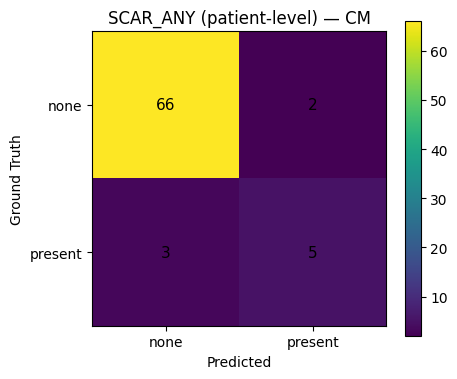

✅ Saved: D:\base\results\cm_scar_left_patient.png


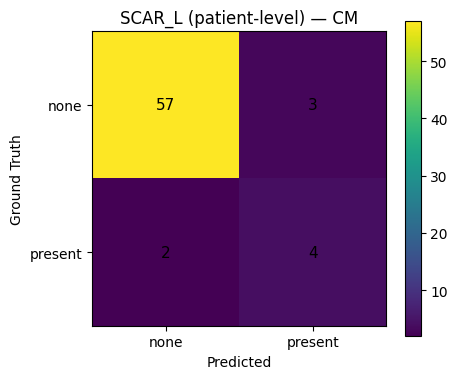

✅ Saved: D:\base\results\cm_scar_right_patient.png


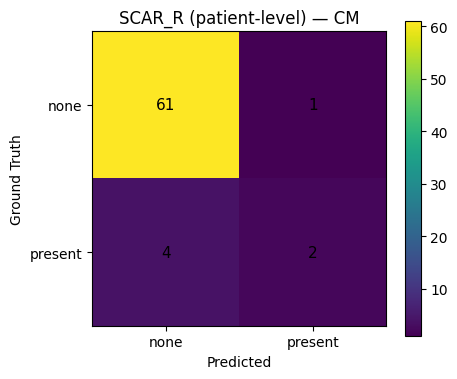

In [ ]:
# CELL 49 — Visualize SCAR confusion matrices (ANY / Left / Right) + save PNGs to D:\base\results

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

if "BASE_DIR" not in globals():
    BASE_DIR = Path(r"D:\base")
OUT_DIR = BASE_DIR / "results"
OUT_DIR.mkdir(parents=True, exist_ok=True)

def plot_cm(cm, title, class_names=("none", "present"), save_path=None):
    if cm is None:
        print(f"⚠️ {title}: cm is None (nothing to plot).")
        return

    cm = np.asarray(cm, dtype=int)

    plt.figure(figsize=(4.8, 4.0))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names)
    plt.yticks(ticks, class_names)

    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")

    # annotate counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=11)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print("✅ Saved:", save_path)

    plt.show()

# Expect these from CELL 42:
# cm_any, cm_L, cm_R
plot_cm(cm_any, "SCAR_ANY (patient-level) — CM", class_names=("none", "present"),
        save_path=OUT_DIR / "cm_scar_any_patient.png")
plot_cm(cm_L,   "SCAR_L (patient-level) — CM", class_names=("none", "present"),
        save_path=OUT_DIR / "cm_scar_left_patient.png")
plot_cm(cm_R,   "SCAR_R (patient-level) — CM", class_names=("none", "present"),
        save_path=OUT_DIR / "cm_scar_right_patient.png")


In [ ]:
# CELL 50 — Sweep thrR (RIGHT) while keeping thrL fixed, optimize VAL F1_any, then evaluate on TEST
# Uses: val_pat_df, test_pat_df already created
# Assumes you want to keep LEFT threshold fixed at 0.51 (from best-left F1)

import numpy as np

thrL_fixed = 0.51
thrR_grid = np.linspace(0.30, 0.95, 66)  # step ~0.01

def f1_binary(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
    return f1, prec, rec, tp, fp, fn

def eval_any(pat_df, thrL, thrR):
    any_gt, any_pr = [], []
    for _, row in pat_df.iterrows():
        gtL = int(row["scarL_gt"]); gtR = int(row["scarR_gt"])
        vL = (gtL >= 0); vR = (gtR >= 0)
        if not (vL or vR):
            continue

        gt_any = int((gtL == 1) if vL else 0) or int((gtR == 1) if vR else 0)
        pr_any = int((row["scarL_prob"] >= thrL) if vL else 0) or int((row["scarR_prob"] >= thrR) if vR else 0)

        any_gt.append(int(gt_any))
        any_pr.append(int(pr_any))

    f1, pr, rc, tp, fp, fn = f1_binary(any_gt, any_pr)
    return {
        "F1_any": float(f1), "P_any": float(pr), "R_any": float(rc),
        "TP": tp, "FP": fp, "FN": fn, "TN": int(len(any_gt) - tp - fp - fn),
        "n": int(len(any_gt))
    }

def cm2_from_counts(TN, FP, FN, TP):
    return np.array([[TN, FP],[FN, TP]], dtype=int)

# --- sweep on VAL ---
best = None
for thrR in thrR_grid:
    res = eval_any(val_pat_df, thrL_fixed, float(thrR))
    row = {"thrL": thrL_fixed, "thrR": float(thrR), **res}
    # maximize F1, tie-breaker: higher precision
    if (best is None) or (row["F1_any"] > best["F1_any"]) or (row["F1_any"] == best["F1_any"] and row["P_any"] > best["P_any"]):
        best = row

print("✅ Best on VAL (thrL fixed):")
print({k: (round(v,4) if isinstance(v,float) else v) for k,v in best.items()})
print("VAL CM_ANY:\n", cm2_from_counts(best["TN"], best["FP"], best["FN"], best["TP"]))

# --- apply on TEST ---
test_res = eval_any(test_pat_df, best["thrL"], best["thrR"])
print("\nTEST @ chosen thresholds:")
print({k: (round(v,4) if isinstance(v,float) else v) for k,v in {"thrL": best["thrL"], "thrR": best["thrR"], **test_res}.items()})
print("TEST CM_ANY:\n", cm2_from_counts(test_res["TN"], test_res["FP"], test_res["FN"], test_res["TP"]))


✅ Best on VAL (thrL fixed):
{'thrL': 0.51, 'thrR': 0.75, 'F1_any': 0.4615, 'P_any': 0.4286, 'R_any': 0.5, 'TP': 3, 'FP': 4, 'FN': 3, 'TN': 66, 'n': 76}
VAL CM_ANY:
 [[66  4]
 [ 3  3]]

TEST @ chosen thresholds:
{'thrL': 0.51, 'thrR': 0.75, 'F1_any': 0.625, 'P_any': 0.625, 'R_any': 0.625, 'TP': 5, 'FP': 3, 'FN': 3, 'TN': 65, 'n': 76}
TEST CM_ANY:
 [[65  3]
 [ 3  5]]
